<a href="https://colab.research.google.com/github/Dill77/Perchv2_Retraining_Modular_Machine_Learning_Pipeline/blob/main/Massive_Perchv2_Scops_Owl_ML_Trained_and_Detector!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run the cell below, then after it is completed, restart the session
#This will update the system and install the necessary Python dependencies

In [ ]:
# Install audio system libraries.
!apt-get -qq update
!apt-get -qq install -y ffmpeg libsndfile1

# Install the current Perch-Hoplite source and the TensorFlow version
# used by Google's current Perch v2 notebook.
!pip install -q --upgrade \
    "tensorflow[and-cuda]~=2.20" \
    "perch-hoplite @ git+https://github.com/google-research/perch-hoplite.git" \
    librosa soundfile pandas scikit-learn matplotlib tqdm requests

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 29.1 MB/s eta 0:00

In [ ]:
#Verify the runtime with block below

In [ ]:
import sys
import platform
import tensorflow as tf

print("Python:", sys.version)
print("Platform:", platform.platform())
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

if not tf.config.list_physical_devices("GPU"):
    print(
        "\nWARNING: No GPU was detected. "
        "Open Runtime > Change runtime type and select a GPU."
    )

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
TensorFlow: 2.21.0
GPU devices: []



In [ ]:
#Mount Google Drive and Create the Project

In [ ]:
from google.colab import drive

# Ensure the mount point is completely empty before attempting to mount
!rm -rf /content/drive/*

drive.mount("/content/drive", force_remount=True)

from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/perch_african_scops_owl"
)

DIRECTORIES = {
    "xc_raw": PROJECT_ROOT / "data/raw/xeno_canto",
    "own_positive": PROJECT_ROOT / "data/raw/own/positive",
    "own_negative": PROJECT_ROOT / "data/raw/own/negative",
    "unlabelled": PROJECT_ROOT / "data/raw/unlabelled",
    "clips_positive": PROJECT_ROOT / "data/clips/positive",
    "clips_negative": PROJECT_ROOT / "data/clips/negative",
    "clips_uncertain": PROJECT_ROOT / "data/clips/uncertain",
    "metadata": PROJECT_ROOT / "metadata",
    "embeddings": PROJECT_ROOT / "embeddings",
    "models": PROJECT_ROOT / "models",
    "reports": PROJECT_ROOT / "reports",
    "inference": PROJECT_ROOT / "inference",
}

for path in DIRECTORIES.values():
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("\nCreated directories:")
for name, path in DIRECTORIES.items():
    print(f"{name:16s} -> {path}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/perch_african_scops_owl

Created directories:
xc_raw           -> /content/drive/MyDrive/perch_african_scops_owl/data/raw/xeno_canto
own_positive     -> /content/drive/MyDrive/perch_african_scops_owl/data/raw/own/positive
own_negative     -> /content/drive/MyDrive/perch_african_scops_owl/data/raw/own/negative
unlabelled       -> /content/drive/MyDrive/perch_african_scops_owl/data/raw/unlabelled
clips_positive   -> /content/drive/MyDrive/perch_african_scops_owl/data/clips/positive
clips_negative   -> /content/drive/MyDrive/perch_african_scops_owl/data/clips/negative
clips_uncertain  -> /content/drive/MyDrive/perch_african_scops_owl/data/clips/uncertain
metadata         -> /content/drive/MyDrive/perch_african_scops_owl/metadata
embeddings       -> /content/drive/MyDrive/perch_african_scops_owl/embeddings
models           -> /content/drive/MyDrive/perch_african_scops_owl/models
reports          -> /content/drive/MyDrive/perch_

In [ ]:
#Now onto actually loading Perchv2!

In [ ]:
import numpy as np
from perch_hoplite.zoo import model_configs

print("Loading Perch v2. The first run may download the model...")

perch_model = model_configs.load_model_by_name("perch_v2")

print("Model type:", type(perch_model).__name__)
print("Sample rate:", perch_model.sample_rate)
print("Window size:", perch_model.window_size_s)

Loading Perch v2. The first run may download the model...



100%|██████████| 176/176 [00:00<00:00, 350kB/s]



100%|██████████| 9.02k/9.02k [00:00<00:00, 11.5MB/s]



  0%|          | 0.00/176 [00:00<?, ?B/s]

100%|██████████| 176/176 [00:00<00:00, 124kB/s]


...



100%|██████████| 276/276 [00:00<00:00, 736kB/s]



100%|██████████| 176/176 [00:00<00:00, 6.06kB/s]


100%|██████████| 176/176 [00:00<00:00, 333kB/s]



100%|██████████| 176/176 [00:00<00:00, 494kB/s]




100%|██████████| 97.0/97.0 [00:00<00:00, 271kB/s]

  7%|▋         | 29.0M/388M [00:01<00:09, 41.1MB/s]



  0%|          | 0.00/2.58M [00:00<?, ?B/s]
 11%|█         | 43.0M/388M [00:01<00:05, 70.6MB/s]

100%|██████████| 2.58M/2.58M [00:00<00:00, 11.3MB/s]

 13%|█▎        | 51.0M/388M [00:01<00:06, 55.2MB/s]
 17%|█▋        | 65.0M/388M [00:01<00:04, 76.0MB/s]
 20%|█▉        | 76.0M/388M [00:01<00:03, 84.9MB/s]
 22%|██▏       | 86.0M/388M [00:01<00:03, 89.4MB/s]
 25%|██▍       | 96.0M/388M [00:01<00:03, 89.9MB/s]
 27%|██▋       | 106M/388M [00:02<00:03, 92.4MB/s] 
 30%|███       | 117M/388M [00:02<00:02, 96.8MB/s]
 33%|███▎      | 128M/388M [00:02<00:02, 99.8MB/s]
 36%|███▌      | 139M/388M [00:02<00:02, 102MB/s] 
 39%|███▊      | 150M/388M [00:02<00:02, 104MB/s]
 41%|████▏     | 161M/388M [00:02<00:02, 105MB/s]
 44%|████▍     | 172M/388M [00:02<00:02, 105MB/s]
 47%|████▋     | 183M/388M [00:02<00:02, 98.5MB/s]
 50%|████▉     | 193M/388M [00:02<00:02, 99.1MB/s]
 52%|█████▏    | 203M/388M [00:02<00:01, 100MB/s] 
 55%|█████▍    | 213M/388M [00:03<00:01, 101MB/s]
 58%|█████▊    | 224M/388M [0

Model type: TaxonomyModelTF
Sample rate: 32000
Window size: 5.0


In [ ]:
#Quick "smoke-test" of the model below
#To prove that all above steps have worked!

In [ ]:
sample_rate = int(perch_model.sample_rate)
window_seconds = float(perch_model.window_size_s)

test_audio = np.zeros(
    int(sample_rate * window_seconds),
    dtype=np.float32,
)

outputs = perch_model.embed(test_audio)

if outputs.embeddings is None:
    raise RuntimeError("Perch did not return embeddings.")

print("Embedding output shape:", outputs.embeddings.shape)
print("Expected final embedding dimension: 1536")

assert outputs.embeddings.shape[-1] == 1536
print("Perch v2 smoke test passed.")

Embedding output shape: (1, 1, 1536)
Expected final embedding dimension: 1536
Perch v2 smoke test passed.


In [ ]:
#PAUSE HERE - MANUAL WORK NEEDED! The above code has just made a set of positive and negative files for the Perch training
#In my case, this is the access to the Scops-Owl recordings, but could be replaced with anything you wanted so long as you have
#enough clips of the species of interest as well as negatives from the same set of audio equiptment (this increases the accuracy!)
#The next bit of code will create Negative subcategories in the Google Drive folders generated

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/perch_african_scops_owl"
)

OWN_POSITIVE_DIR = PROJECT_ROOT / "data/raw/own/positive"
OWN_NEGATIVE_DIR = PROJECT_ROOT / "data/raw/own/negative"

NEGATIVE_DIRS = {
    "other_bird": OWN_NEGATIVE_DIR / "other_bird",
    "background": OWN_NEGATIVE_DIR / "background",
    "hard_negative": OWN_NEGATIVE_DIR / "hard_negative",
}

OWN_POSITIVE_DIR.mkdir(parents=True, exist_ok=True)

for directory in NEGATIVE_DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

print("Positive clips:")
print(OWN_POSITIVE_DIR)

print("\nNegative clip folders:")
for name, directory in NEGATIVE_DIRS.items():
    print(f"{name:15s} -> {directory}")

Positive clips:
/content/drive/MyDrive/perch_african_scops_owl/data/raw/own/positive

Negative clip folders:
other_bird      -> /content/drive/MyDrive/perch_african_scops_owl/data/raw/own/negative/other_bird
background      -> /content/drive/MyDrive/perch_african_scops_owl/data/raw/own/negative/background
hard_negative   -> /content/drive/MyDrive/perch_african_scops_owl/data/raw/own/negative/hard_negative


In [ ]:
#PAUSE AGAIN FOR MANUAL STEP for SET-UP!
#Now need to classify the audio clips provided in the folders from just "negative" into:
#"Other_bird" = Other bird in the recording
#"Background" = Just background audio clips from the files (insects, wind, denoised wind, or just nice silence in the case of Lara's MP4)
#"Hard_negative" = This can remain empty for now - but will get updated later
#Next code bit below will look for and scan each of the audio files!

In [ ]:
import json
import subprocess
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm

SUPPORTED_AUDIO_EXTENSIONS = {
    ".wav", ".wave", ".flac", ".mp3",
    ".m4a", ".aac", ".ogg", ".opus", ".wma"
}


def inspect_audio_file(filepath):
    """
    Return basic technical information about one audio file.

    ffprobe is used because it supports more file formats than
    many Python-only audio libraries.
    """
    command = [
        "ffprobe",
        "-v", "error",
        "-select_streams", "a:0",
        "-show_entries",
        "stream=sample_rate,channels,codec_name:format=duration",
        "-of", "json",
        str(filepath),
    ]

    try:
        result = subprocess.run(
            command,
            capture_output=True,
            text=True,
            check=True,
        )

        information = json.loads(result.stdout)
        streams = information.get("streams", [])
        audio_stream = streams[0] if streams else {}
        format_information = information.get("format", {})

        return {
            "duration_seconds": float(
                format_information.get("duration", 0)
            ),
            "sample_rate": int(
                audio_stream.get("sample_rate", 0)
            ),
            "channels": int(
                audio_stream.get("channels", 0)
            ),
            "codec": audio_stream.get("codec_name", ""),
            "inspection_error": "",
        }

    except Exception as error:
        return {
            "duration_seconds": None,
            "sample_rate": None,
            "channels": None,
            "codec": "",
            "inspection_error": str(error),
        }


def find_audio_files(directory):
    """Recursively find supported audio files."""
    return sorted(
        filepath
        for filepath in Path(directory).rglob("*")
        if (
            filepath.is_file()
            and filepath.suffix.lower()
            in SUPPORTED_AUDIO_EXTENSIONS
        )
    )


records = []

# Positive files
for filepath in find_audio_files(OWN_POSITIVE_DIR):
    records.append({
        "filepath": str(filepath),
        "filename": filepath.name,
        "label": 1,
        "class_name": "african_scops_owl",
        "negative_type": "",
        **inspect_audio_file(filepath),
    })

# Negative files
for negative_type, directory in NEGATIVE_DIRS.items():
    for filepath in find_audio_files(directory):
        records.append({
            "filepath": str(filepath),
            "filename": filepath.name,
            "label": 0,
            "class_name": "not_african_scops_owl",
            "negative_type": negative_type,
            **inspect_audio_file(filepath),
        })

inventory = pd.DataFrame(records)

INVENTORY_PATH = (
    PROJECT_ROOT / "metadata/own_audio_inventory.csv"
)
inventory.to_csv(INVENTORY_PATH, index=False)

print(f"Found {len(inventory)} audio files.")
print(f"Saved inventory to:\n{INVENTORY_PATH}")

inventory.head()

Found 145 audio files.
Saved inventory to:
/content/drive/MyDrive/perch_african_scops_owl/metadata/own_audio_inventory.csv


,filepath,filename,label,class_name,negative_type,duration_seconds,sample_rate,channels,codec,inspection_error
0,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_021_00-14-47_to_00-14-51 = African Sc...,1,african_scops_owl,,4.0,48000,2,pcm_s16le,
1,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_022_00-14-53_to_00-15-03 = African Sc...,1,african_scops_owl,,10.0,48000,2,pcm_s16le,
2,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_023_00-15-11_to_00-15-15 = African Sc...,1,african_scops_owl,,4.0,48000,2,pcm_s16le,
3,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_024_00-15-17_to_00-15-21 = African Sc...,1,african_scops_owl,,4.0,48000,2,pcm_s16le,
4,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_025_00-15-23_to_00-15-30 = African Sc...,1,african_scops_owl,,7.0,48000,2,pcm_s16le,


In [ ]:
#Dataset summary below

In [ ]:
if inventory.empty:
    raise RuntimeError(
        "No audio files were found. "
        "Add files to the folders printed by Cell 6."
    )

print("FILES BY CLASS")
display(
    inventory.groupby(
        ["class_name", "negative_type"],
        dropna=False,
    ).size().rename("number_of_files").reset_index()
)

print("\nDURATION BY CLASS")
duration_summary = (
    inventory.groupby("class_name")
    .agg(
        files=("filepath", "count"),
        total_seconds=("duration_seconds", "sum"),
        mean_seconds=("duration_seconds", "mean"),
        minimum_seconds=("duration_seconds", "min"),
        maximum_seconds=("duration_seconds", "max"),
    )
    .reset_index()
)

display(duration_summary.round(2))

print("\nSAMPLE RATES")
display(
    inventory.groupby(
        ["class_name", "sample_rate"],
        dropna=False,
    ).size().rename("number_of_files").reset_index()
)

print("\nCHANNEL COUNTS")
display(
    inventory.groupby(
        ["class_name", "channels"],
        dropna=False,
    ).size().rename("number_of_files").reset_index()
)

failed_files = inventory[
    inventory["inspection_error"].fillna("") != ""
]

print(f"\nFiles that could not be inspected: {len(failed_files)}")
if not failed_files.empty:
    display(
        failed_files[
            ["filepath", "inspection_error"]
        ]
    )

FILES BY CLASS


,class_name,negative_type,number_of_files
0,african_scops_owl,,35
1,not_african_scops_owl,background,8
2,not_african_scops_owl,other_bird,102



DURATION BY CLASS


,class_name,files,total_seconds,mean_seconds,minimum_seconds,maximum_seconds
0,african_scops_owl,35,155.0,4.43,4.0,10.0
1,not_african_scops_owl,110,767.0,6.97,4.0,34.0



SAMPLE RATES


,class_name,sample_rate,number_of_files
0,african_scops_owl,48000,35
1,not_african_scops_owl,16000,32
2,not_african_scops_owl,48000,78



CHANNEL COUNTS


,class_name,channels,number_of_files
0,african_scops_owl,2,35
1,not_african_scops_owl,2,110



Files that could not be inspected: 0


In [ ]:
#Making the editable metadata manifest next - to identify the source group type

In [ ]:
import re
import uuid


def make_clip_id(row_number):
    return f"own_{row_number:05d}"


manifest = inventory.copy().reset_index(drop=True)

manifest.insert(
    0,
    "clip_id",
    [make_clip_id(i) for i in range(len(manifest))]
)

# Defaults that you should review manually.
manifest["include"] = True
manifest["source_group"] = manifest["clip_id"]
manifest["detector_id"] = ""
manifest["site_id"] = ""
manifest["recording_date"] = ""

manifest["verification"] = manifest["label"].map({
    1: "expert_and_model_assisted",
    0: "expert_negative",
})

manifest["owl_call_present"] = manifest["label"].map({
    1: "yes",
    0: "no",
})

manifest["notes"] = ""

column_order = [
    "clip_id",
    "filepath",
    "filename",
    "label",
    "class_name",
    "negative_type",
    "include",
    "source_group",
    "detector_id",
    "site_id",
    "recording_date",
    "verification",
    "owl_call_present",
    "duration_seconds",
    "sample_rate",
    "channels",
    "codec",
    "notes",
    "inspection_error",
]

manifest = manifest[column_order]

OWN_MANIFEST_PATH = (
    PROJECT_ROOT / "metadata/own_audio_manifest.csv"
)

manifest.to_csv(OWN_MANIFEST_PATH, index=False)

print("Manifest created:")
print(OWN_MANIFEST_PATH)
print()
print(
    "Open this CSV in Google Sheets and edit source_group, "
    "detector_id, site_id and recording_date where known."
)

display(manifest.head(10))

Manifest created:
/content/drive/MyDrive/perch_african_scops_owl/metadata/own_audio_manifest.csv

Open this CSV in Google Sheets and edit source_group, detector_id, site_id and recording_date where known.


,clip_id,filepath,filename,label,class_name,negative_type,include,source_group,detector_id,site_id,recording_date,verification,owl_call_present,duration_seconds,sample_rate,channels,codec,notes,inspection_error
0,own_00000,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_021_00-14-47_to_00-14-51 = African Sc...,1,african_scops_owl,,True,own_00000,,,,expert_and_model_assisted,yes,4.0,48000,2,pcm_s16le,,
1,own_00001,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_022_00-14-53_to_00-15-03 = African Sc...,1,african_scops_owl,,True,own_00001,,,,expert_and_model_assisted,yes,10.0,48000,2,pcm_s16le,,
2,own_00002,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_023_00-15-11_to_00-15-15 = African Sc...,1,african_scops_owl,,True,own_00002,,,,expert_and_model_assisted,yes,4.0,48000,2,pcm_s16le,,
3,own_00003,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_024_00-15-17_to_00-15-21 = African Sc...,1,african_scops_owl,,True,own_00003,,,,expert_and_model_assisted,yes,4.0,48000,2,pcm_s16le,,
4,own_00004,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_025_00-15-23_to_00-15-30 = African Sc...,1,african_scops_owl,,True,own_00004,,,,expert_and_model_assisted,yes,7.0,48000,2,pcm_s16le,,
5,own_00005,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_026_00-15-32_to_00-15-36 = African Sc...,1,african_scops_owl,,True,own_00005,,,,expert_and_model_assisted,yes,4.0,48000,2,pcm_s16le,,
6,own_00006,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_027_00-15-44_to_00-15-48 = African Sc...,1,african_scops_owl,,True,own_00006,,,,expert_and_model_assisted,yes,4.0,48000,2,pcm_s16le,,
7,own_00007,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_028_00-15-50_to_00-15-54 = African Sc...,1,african_scops_owl,,True,own_00007,,,,expert_and_model_assisted,yes,4.0,48000,2,pcm_s16le,,
8,own_00008,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_029_00-15-56_to_00-16-00 = African Sc...,1,african_scops_owl,,True,own_00008,,,,expert_and_model_assisted,yes,4.0,48000,2,pcm_s16le,,
9,own_00009,/content/drive/MyDrive/perch_african_scops_owl...,birdcall_030_00-16-02_to_00-16-06 = African Sc...,1,african_scops_owl,,True,own_00009,,,,expert_and_model_assisted,yes,4.0,48000,2,pcm_s16le,,


In [ ]:
#Now pause here, and look at the created .csv file - you may need to manually update tags again
#Required tags are the caracal source, the hour (if multiple clips are made from the same hour and caracal)
#Note: Please DO NOT USE the words "African Scops-Owl" in any of the file names for only one
#dataset partition while negatives use a different naming convention - classifier obviously cannot read file names!
#Also, consistent data management will help to reduce any accidental biases
#Below, you can change the "row_number" section to inspect any row from the manifest!

Clip ID: own_00000
Filename: birdcall_021_00-14-47_to_00-14-51 = African Scops-Owl.wav
Class: african_scops_owl
Negative type: 
Duration: 4.0 seconds
Original sample rate: 48000


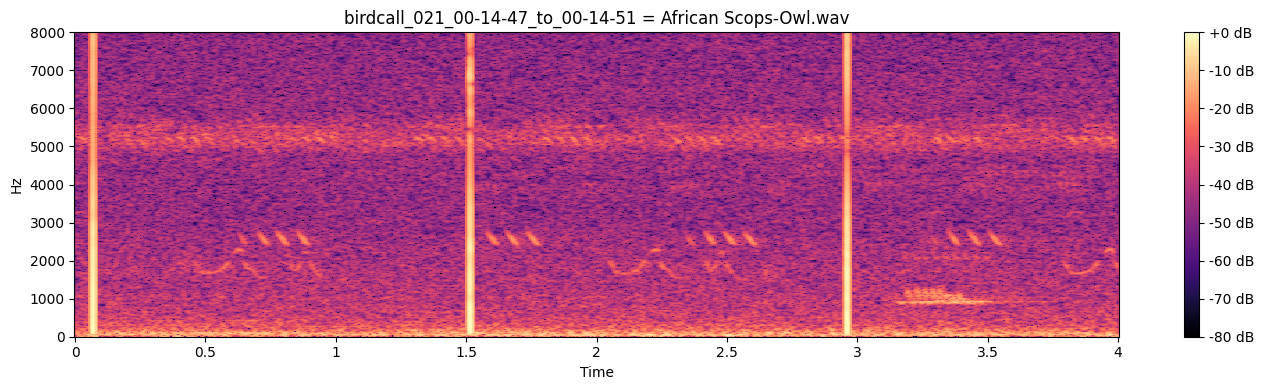

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import Audio, display


ROW_NUMBER = 0

if ROW_NUMBER < 0 or ROW_NUMBER >= len(manifest):
    raise IndexError(
        f"ROW_NUMBER must be between 0 and {len(manifest) - 1}."
    )

selected_row = manifest.iloc[ROW_NUMBER]
selected_path = Path(selected_row["filepath"])

audio, original_sample_rate = librosa.load(
    selected_path,
    sr=None,
    mono=True,
)

duration = len(audio) / original_sample_rate

print("Clip ID:", selected_row["clip_id"])
print("Filename:", selected_row["filename"])
print("Class:", selected_row["class_name"])
print("Negative type:", selected_row["negative_type"])
print("Duration:", round(duration, 2), "seconds")
print("Original sample rate:", original_sample_rate)

display(
    Audio(
        audio,
        rate=original_sample_rate,
        normalize=False,
    )
)

plt.figure(figsize=(14, 4))

librosa.display.specshow(
    librosa.amplitude_to_db(
        np.abs(
            librosa.stft(
                audio,
                n_fft=2048,
                hop_length=256,
            )
        ),
        ref=np.max,
    ),
    sr=original_sample_rate,
    hop_length=256,
    x_axis="time",
    y_axis="hz",
)

plt.ylim(0, min(8000, original_sample_rate / 2))
plt.colorbar(format="%+2.0f dB")
plt.title(selected_row["filename"])
plt.tight_layout()
plt.show()

In [ ]:
#Before the next step, make sure that you have a XenoCanto account, and cna access your personal API key
#Below will allow the secure addition of the API key

In [ ]:
from getpass import getpass
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/perch_african_scops_owl"
)

XC_AUDIO_DIR = (
    PROJECT_ROOT / "data/raw/xeno_canto/african_scops_owl"
)
XC_METADATA_DIR = PROJECT_ROOT / "metadata"

XC_AUDIO_DIR.mkdir(parents=True, exist_ok=True)
XC_METADATA_DIR.mkdir(parents=True, exist_ok=True)

# getpass hides the key while you type or paste it.
# The value exists only in this Colab session and is not written to Drive.
XC_API_KEY = getpass("Paste your Xeno-Canto API key: ").strip()

if len(XC_API_KEY) < 5:
    raise ValueError(
        "The API key appears to be empty or unusually short."
    )

XC_API_BASE = "https://xeno-canto.org/api/3/recordings"

# API v3 uses the full scientific name in the sp field.
XC_QUERY = 'sp:"Otus senegalensis" grp:birds'

print("API key received.")
print("Query:", XC_QUERY)
print("Download directory:", XC_AUDIO_DIR)

Paste your Xeno-Canto API key: ··········
API key received.
Query: sp:"Otus senegalensis" grp:birds
Download directory: /content/drive/MyDrive/perch_african_scops_owl/data/raw/xeno_canto/african_scops_owl


In [ ]:
#Now to retrieve any metadata - not the downloads just yet! (that is next up)

In [ ]:
import json
import time

import requests
from tqdm.auto import tqdm


session = requests.Session()

# A descriptive user agent is preferable to pretending to be a browser.
session.headers.update({
    "User-Agent": (
        "AfricanScopsOwl-ConservationResearch-Colab/1.0"
    ),
    "Accept": "application/json",
})


def fetch_xc_page(page_number, maximum_attempts=6):
    """
    Retrieve one Xeno-Canto API page with retries.

    Temporary 429 and server errors are retried using progressively
    longer waiting periods.
    """
    parameters = {
        "query": XC_QUERY,
        "key": XC_API_KEY,
        "page": page_number,
        "per_page": 100,
    }

    retriable_statuses = {429, 500, 502, 503, 504}

    for attempt in range(1, maximum_attempts + 1):
        try:
            response = session.get(
                XC_API_BASE,
                params=parameters,
                timeout=90,
            )

            if response.status_code in retriable_statuses:
                wait_seconds = min(60, 3 * attempt)
                print(
                    f"Page {page_number}: HTTP "
                    f"{response.status_code}; waiting "
                    f"{wait_seconds} seconds."
                )
                time.sleep(wait_seconds)
                continue

            if response.status_code in {401, 403}:
                raise RuntimeError(
                    "Xeno-Canto rejected the API request. "
                    "Check that your account is verified and that "
                    "the API key was copied correctly."
                )

            response.raise_for_status()

            try:
                data = response.json()
            except ValueError as error:
                preview = response.text[:300]
                raise RuntimeError(
                    "The API returned a non-JSON response.\n"
                    f"Response beginning:\n{preview}"
                ) from error

            if data.get("error"):
                raise RuntimeError(
                    "Xeno-Canto API error: "
                    f"{data.get('error')} — "
                    f"{data.get('message', '')}"
                )

            if "recordings" not in data:
                raise RuntimeError(
                    "The response did not contain a recordings field."
                )

            return data

        except requests.RequestException as error:
            if attempt == maximum_attempts:
                raise

            wait_seconds = min(60, 3 * attempt)
            print(
                f"Page {page_number}: {error}; "
                f"waiting {wait_seconds} seconds."
            )
            time.sleep(wait_seconds)

    raise RuntimeError(
        f"Could not retrieve page {page_number}."
    )


print("Retrieving first metadata page...")
first_page = fetch_xc_page(1)

number_of_pages = int(first_page.get("numPages", 1))
reported_recordings = int(
    first_page.get(
        "numRecordings",
        len(first_page["recordings"]),
    )
)

all_recordings = list(first_page["recordings"])

print("Reported recordings:", reported_recordings)
print("Number of pages:", number_of_pages)

for page_number in tqdm(
    range(2, number_of_pages + 1),
    desc="Retrieving metadata pages",
):
    # Deliberately avoid rapid parallel requests.
    time.sleep(2)

    page_data = fetch_xc_page(page_number)
    all_recordings.extend(page_data["recordings"])

print("Metadata records retrieved:", len(all_recordings))

XC_RAW_JSON_PATH = (
    XC_METADATA_DIR /
    "xc_african_scops_owl_api_metadata.json"
)

# The API key is not included in this saved object.
saved_payload = {
    "query": XC_QUERY,
    "reported_num_recordings": reported_recordings,
    "reported_num_pages": number_of_pages,
    "recordings": all_recordings,
}

with open(XC_RAW_JSON_PATH, "w", encoding="utf-8") as file:
    json.dump(
        saved_payload,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Raw metadata saved to:")
print(XC_RAW_JSON_PATH)

Retrieving first metadata page...
Reported recordings: 132
Number of pages: 2


Retrieving metadata pages:   0%|          | 0/1 [00:00<?, ?it/s]

Metadata records retrieved: 132
Raw metadata saved to:
/content/drive/MyDrive/perch_african_scops_owl/metadata/xc_african_scops_owl_api_metadata.json


In [ ]:
#Now onto the building of the reference-recording manifest

In [ ]:
import re
from urllib.parse import urlparse

import pandas as pd


def first_value(record, *possible_keys, default=""):
    """Return the first present, non-None key value."""
    for key in possible_keys:
        if key in record and record[key] is not None:
            return record[key]
    return default


def normalize_xc_url(value):
    """Convert relative or protocol-relative XC URLs to HTTPS."""
    value = str(value or "").strip()

    if value.startswith("//"):
        return "https:" + value

    if value.startswith("/"):
        return "https://xeno-canto.org" + value

    return value


def make_xc_id(value):
    value = str(value).strip()
    return value if value.upper().startswith("XC") else f"XC{value}"


def parse_xc_length(value):
    """
    Convert strings such as 0:35 or 1:02:15 to seconds.
    """
    text = str(value or "").strip()

    if not text:
        return None

    try:
        parts = [float(part) for part in text.split(":")]

        if len(parts) == 1:
            return parts[0]

        if len(parts) == 2:
            minutes, seconds = parts
            return minutes * 60 + seconds

        if len(parts) == 3:
            hours, minutes, seconds = parts
            return hours * 3600 + minutes * 60 + seconds

    except ValueError:
        return None

    return None


def format_background_species(value):
    if isinstance(value, list):
        return "; ".join(
            str(item).strip()
            for item in value
            if str(item).strip()
        )

    return str(value or "").strip()


rows = []

for recording in all_recordings:
    recording_id = first_value(recording, "id")

    genus = str(
        first_value(recording, "gen")
    ).strip()

    species = str(
        first_value(recording, "sp")
    ).strip()

    remarks = str(
        first_value(recording, "rmk", "remarks")
    ).strip()

    common_name = str(
        first_value(recording, "en")
    ).strip()

    combined_review_text = (
        common_name + " " + remarks
    ).lower()

    # This flag is deliberately cautious. It does not automatically
    # reject a file; it only highlights it for manual attention.
    possible_id_issue = bool(
        re.search(
            r"\bid under discussion\b|"
            r"\bmystery recording\b|"
            r"\bidentity unknown\b|"
            r"\bid is not sure\b|"
            r"\bidentification uncertain\b|"
            r"\buncertain identification\b",
            combined_review_text,
        )
    )

    row = {
        "xc_id": make_xc_id(recording_id),
        "catalogue_number": str(recording_id),
        "genus": genus,
        "species": species,
        "subspecies": str(
            first_value(recording, "ssp")
        ).strip(),
        "scientific_name": f"{genus} {species}".strip(),
        "common_name": common_name,
        "recordist": str(
            first_value(recording, "rec")
        ).strip(),
        "country": str(
            first_value(recording, "cnt")
        ).strip(),
        "location": str(
            first_value(recording, "loc")
        ).strip(),
        "latitude": first_value(recording, "lat"),
        "longitude": first_value(recording, "lon"),
        "recording_date": str(
            first_value(recording, "date")
        ).strip(),
        "recording_time": str(
            first_value(recording, "time")
        ).strip(),
        "sound_type": str(
            first_value(recording, "type")
        ).strip(),
        "quality": str(
            first_value(recording, "q")
        ).strip().upper(),
        "length_original": str(
            first_value(recording, "length")
        ).strip(),
        "length_seconds": parse_xc_length(
            first_value(recording, "length")
        ),
        "license_url": normalize_xc_url(
            first_value(recording, "lic")
        ),
        "page_url": normalize_xc_url(
            first_value(recording, "url")
        ),
        "file_url": normalize_xc_url(
            first_value(recording, "file")
        ),
        "original_file_name": str(
            first_value(
                recording,
                "file-name",
                "fileName",
            )
        ).strip(),
        "background_species": format_background_species(
            first_value(recording, "also", default=[])
        ),
        "animal_seen": str(
            first_value(
                recording,
                "animal-seen",
                "animalSeen",
                "bird-seen",
                "birdSeen",
            )
        ).strip(),
        "playback_used": str(
            first_value(
                recording,
                "playback-used",
                "playbackUsed",
            )
        ).strip(),
        "sample_rate_reported": first_value(
            recording,
            "smp",
        ),
        "device_reported": str(
            first_value(recording, "dvc")
        ).strip(),
        "microphone_reported": str(
            first_value(recording, "mic")
        ).strip(),
        "remarks": remarks,
        "possible_id_issue": possible_id_issue,
    }

    rows.append(row)


xc_metadata = pd.DataFrame(rows)

xc_metadata["exact_target_species"] = (
    xc_metadata["genus"].str.casefold().eq("otus")
    & xc_metadata["species"].str.casefold().eq(
        "senegalensis"
    )
)

xc_metadata["quality_candidate"] = (
    xc_metadata["quality"].isin(["A", "B", "C"])
)

XC_ALL_METADATA_PATH = (
    XC_METADATA_DIR /
    "xc_african_scops_owl_all_metadata.csv"
)

xc_metadata.to_csv(
    XC_ALL_METADATA_PATH,
    index=False,
)


xc_candidates = xc_metadata[
    xc_metadata["exact_target_species"]
    & xc_metadata["quality_candidate"]
].copy()

# Each complete XC recording is one independent source group.
xc_candidates["source_group"] = xc_candidates["xc_id"]

# These are editable workflow fields.
xc_candidates["download"] = True
xc_candidates["metadata_review_status"] = "unreviewed"
xc_candidates["keep_for_audio_review"] = True
xc_candidates["manual_notes"] = ""

quality_order = {"A": 0, "B": 1, "C": 2}

xc_candidates["_quality_order"] = (
    xc_candidates["quality"]
    .map(quality_order)
    .fillna(99)
)

xc_candidates = (
    xc_candidates
    .sort_values(
        [
            "_quality_order",
            "country",
            "xc_id",
        ]
    )
    .drop(columns="_quality_order")
    .reset_index(drop=True)
)

XC_CANDIDATE_PATH = (
    XC_METADATA_DIR /
    "xc_african_scops_owl_download_candidates.csv"
)

xc_candidates.to_csv(
    XC_CANDIDATE_PATH,
    index=False,
)

print("All metadata:")
print(XC_ALL_METADATA_PATH)

print("\nA–C candidate manifest:")
print(XC_CANDIDATE_PATH)

display(xc_candidates.head(10))

All metadata:
/content/drive/MyDrive/perch_african_scops_owl/metadata/xc_african_scops_owl_all_metadata.csv

A–C candidate manifest:
/content/drive/MyDrive/perch_african_scops_owl/metadata/xc_african_scops_owl_download_candidates.csv


,xc_id,catalogue_number,genus,species,subspecies,scientific_name,common_name,recordist,country,location,...,microphone_reported,remarks,possible_id_issue,exact_target_species,quality_candidate,source_group,download,metadata_review_status,keep_for_audio_review,manual_notes
0,XC567888,567888,Otus,senegalensis,,Otus senegalensis,African Scops Owl,Arnon Dattner,Angola,Kinjila,...,,For more information about Angola birds please...,False,True,True,XC567888,True,unreviewed,True,
1,XC1004828,1004828,Otus,senegalensis,,Otus senegalensis,African Scops Owl,Marc Anderson,Botswana,Limpopo River,...,,,False,True,True,XC1004828,True,unreviewed,True,
2,XC834122,834122,Otus,senegalensis,,Otus senegalensis,African Scops Owl,Marc Anderson,Botswana,Northern Tuli Game Reserve,...,,,False,True,True,XC834122,True,unreviewed,True,
3,XC834206,834206,Otus,senegalensis,,Otus senegalensis,African Scops Owl,Marc Anderson,Botswana,Limpopo River,...,,,False,True,True,XC834206,True,unreviewed,True,
4,XC878246,878246,Otus,senegalensis,,Otus senegalensis,African Scops Owl,Marc Anderson,Botswana,Northern Tuli Game Reserve,...,,,False,True,True,XC878246,True,unreviewed,True,
5,XC1082355,1082355,Otus,senegalensis,senegalensis,Otus senegalensis,African Scops Owl,Marc Languy,Burkina Faso,"Waléme, Nahouri, Centre-Sud",...,,,False,True,True,XC1082355,True,unreviewed,True,
6,XC425571,425571,Otus,senegalensis,,Otus senegalensis,African Scops Owl,Peter Boesman,Gambia,"Janjanbureh, Janjanbureh, Central River",...,,,False,True,True,XC425571,True,unreviewed,True,
7,XC425572,425572,Otus,senegalensis,,Otus senegalensis,African Scops Owl,Peter Boesman,Gambia,"Janjanbureh, Janjanbureh, Central River",...,,Several birds.,False,True,True,XC425572,True,unreviewed,True,
8,XC562103,562103,Otus,senegalensis,,Otus senegalensis,African Scops Owl,Joost van Bruggen,Gambia,"Abca's Creek Lodge, Bintang",...,,,False,True,True,XC562103,True,unreviewed,True,
9,XC702993,702993,Otus,senegalensis,,Otus senegalensis,African Scops Owl,Joost van Bruggen,Gambia,"Abca's Creek Lodge, Bintang",...,Sennheiser MKH416,,False,True,True,XC702993,True,unreviewed,True,


In [ ]:
#Reviewer of the metadata - below code should give a summary!
#Will give a list of flagged results for review - these don't need deleting necessarily (can do if you want to speed up the process of course, and have enough other data)
# The flag is only a keyword check - so worth looking over flagged results if needed

In [ ]:
print("RETRIEVAL SUMMARY")
print("-----------------")
print("API records:", len(xc_metadata))
print(
    "Exact Otus senegalensis records:",
    int(xc_metadata["exact_target_species"].sum()),
)
print(
    "Quality A–C candidates:",
    len(xc_candidates),
)

print("\nQUALITY GRADES")
display(
    xc_metadata.groupby(
        ["exact_target_species", "quality"],
        dropna=False,
    )
    .size()
    .rename("recordings")
    .reset_index()
)

print("\nCANDIDATES BY COUNTRY")
display(
    xc_candidates.groupby(
        "country",
        dropna=False,
    )
    .agg(
        recordings=("xc_id", "count"),
        total_minutes=("length_seconds", lambda x: x.sum() / 60),
    )
    .reset_index()
    .sort_values(
        "recordings",
        ascending=False,
    )
    .round(2)
)

print("\nCANDIDATES BY RECORDING TYPE")
display(
    xc_candidates.groupby(
        "sound_type",
        dropna=False,
    )
    .size()
    .rename("recordings")
    .reset_index()
    .sort_values(
        "recordings",
        ascending=False,
    )
)

print("\nLICENCES")
display(
    xc_candidates.groupby(
        "license_url",
        dropna=False,
    )
    .size()
    .rename("recordings")
    .reset_index()
)

possible_issues = xc_candidates[
    xc_candidates["possible_id_issue"]
]

print(
    "\nCandidates flagged for possible "
    f"identification review: {len(possible_issues)}"
)

if not possible_issues.empty:
    display(
        possible_issues[
            [
                "xc_id",
                "quality",
                "country",
                "sound_type",
                "recordist",
                "remarks",
                "page_url",
            ]
        ]
    )

RETRIEVAL SUMMARY
-----------------
API records: 132
Exact Otus senegalensis records: 132
Quality A–C candidates: 128

QUALITY GRADES


,exact_target_species,quality,recordings
0,True,A,63
1,True,B,44
2,True,C,21
3,True,D,4



CANDIDATES BY COUNTRY


,country,recordings,total_minutes
13,South Africa,28,29.02
7,Ghana,23,16.10
16,Zambia,13,11.78
6,Gambia,12,23.15
11,Namibia,11,8.08
12,Senegal,8,5.45
14,Tanzania,7,7.10
10,Kenya,7,4.57
1,Botswana,4,12.52
17,Zimbabwe,3,1.80



CANDIDATES BY RECORDING TYPE


,sound_type,recordings
4,song,78
1,call,46
0,,1
2,"call, duet",1
3,"duet, song",1
5,uncertain,1



LICENCES


,license_url,recordings
0,https://creativecommons.org/licenses/by-nc-nd/...,9
1,https://creativecommons.org/licenses/by-nc-nd/...,3
2,https://creativecommons.org/licenses/by-nc-nd/...,43
3,https://creativecommons.org/licenses/by-nc-sa/...,4
4,https://creativecommons.org/licenses/by-nc-sa/...,69



Candidates flagged for possible identification review: 0


In [ ]:
#Downloads all candidate recordings of quality A-C from XenoCanto of the previously defined species (in my case it is the African Scops-Owl)

In [ ]:
import os
import time
from pathlib import Path

import pandas as pd
import requests
from tqdm.auto import tqdm


# Reload from Drive so that any edits made in Google Sheets
# are respected.
download_candidates = pd.read_csv(XC_CANDIDATE_PATH)


def value_is_true(value):
    return str(value).strip().casefold() in {
        "true", "1", "yes", "y"
    }


download_candidates = download_candidates[
    download_candidates["download"].apply(value_is_true)
].copy()

print(
    "Recordings selected for download:",
    len(download_candidates),
)


def safe_audio_suffix(original_name, file_url):
    """
    Select a sensible file extension without trusting arbitrary text.
    """
    supported = {
        ".mp3", ".wav", ".wave", ".flac",
        ".ogg", ".m4a", ".aac", ".opus",
    }

    original_suffix = Path(
        str(original_name or "")
    ).suffix.lower()

    if original_suffix in supported:
        return original_suffix

    url_suffix = Path(
        urlparse(str(file_url)).path
    ).suffix.lower()

    if url_suffix in supported:
        return url_suffix

    # XC commonly serves MP3 when no usable extension is reported.
    return ".mp3"


def download_xc_audio(row, maximum_attempts=5):
    xc_id = str(row["xc_id"])
    file_url = str(row["file_url"]).strip()

    if not file_url:
        return {
            "xc_id": xc_id,
            "download_status": "failed",
            "local_filepath": "",
            "download_error": "Missing file URL",
            "file_size_bytes": None,
        }

    suffix = safe_audio_suffix(
        row.get("original_file_name", ""),
        file_url,
    )

    destination = XC_AUDIO_DIR / f"{xc_id}{suffix}"
    temporary_destination = Path(str(destination) + ".part")

    if destination.exists() and destination.stat().st_size > 0:
        return {
            "xc_id": xc_id,
            "download_status": "already_present",
            "local_filepath": str(destination),
            "download_error": "",
            "file_size_bytes": destination.stat().st_size,
        }

    for attempt in range(1, maximum_attempts + 1):
        try:
            response = session.get(
                file_url,
                stream=True,
                timeout=180,
            )

            # Some configurations may require the key on the
            # audio request as well as the metadata request.
            if response.status_code in {401, 403}:
                response.close()

                response = session.get(
                    file_url,
                    params={"key": XC_API_KEY},
                    stream=True,
                    timeout=180,
                )

            if response.status_code in {
                429, 500, 502, 503, 504
            }:
                wait_seconds = min(60, 4 * attempt)
                response.close()
                time.sleep(wait_seconds)
                continue

            response.raise_for_status()

            content_type = response.headers.get(
                "Content-Type",
                "",
            ).lower()

            if (
                "text/html" in content_type
                or "application/json" in content_type
            ):
                preview = response.raw.read(300)
                response.close()

                raise RuntimeError(
                    "Expected audio but received "
                    f"{content_type}: {preview!r}"
                )

            with open(temporary_destination, "wb") as file:
                for chunk in response.iter_content(
                    chunk_size=1024 * 1024
                ):
                    if chunk:
                        file.write(chunk)

            response.close()

            if (
                not temporary_destination.exists()
                or temporary_destination.stat().st_size == 0
            ):
                raise RuntimeError(
                    "Downloaded file was empty."
                )

            temporary_destination.replace(destination)

            return {
                "xc_id": xc_id,
                "download_status": "downloaded",
                "local_filepath": str(destination),
                "download_error": "",
                "file_size_bytes": destination.stat().st_size,
            }

        except Exception as error:
            if temporary_destination.exists():
                temporary_destination.unlink()

            if attempt == maximum_attempts:
                return {
                    "xc_id": xc_id,
                    "download_status": "failed",
                    "local_filepath": "",
                    "download_error": str(error),
                    "file_size_bytes": None,
                }

            wait_seconds = min(60, 4 * attempt)
            time.sleep(wait_seconds)

    return {
        "xc_id": xc_id,
        "download_status": "failed",
        "local_filepath": "",
        "download_error": "Unknown download failure",
        "file_size_bytes": None,
    }


download_results = []

for _, row in tqdm(
    download_candidates.iterrows(),
    total=len(download_candidates),
    desc="Downloading Xeno-Canto audio",
):
    result = download_xc_audio(row)
    download_results.append(result)

    # Be deliberately gentle with the service.
    time.sleep(2)


download_report = pd.DataFrame(download_results)

XC_DOWNLOAD_REPORT_PATH = (
    XC_METADATA_DIR /
    "xc_african_scops_owl_download_report.csv"
)

download_report.to_csv(
    XC_DOWNLOAD_REPORT_PATH,
    index=False,
)

xc_download_manifest = download_candidates.merge(
    download_report,
    on="xc_id",
    how="left",
)

XC_DOWNLOADED_MANIFEST_PATH = (
    XC_METADATA_DIR /
    "xc_african_scops_owl_downloaded_manifest.csv"
)

xc_download_manifest.to_csv(
    XC_DOWNLOADED_MANIFEST_PATH,
    index=False,
)

print("Download report:")
display(
    download_report.groupby(
        "download_status",
        dropna=False,
    )
    .size()
    .rename("recordings")
    .reset_index()
)

failed_downloads = download_report[
    download_report["download_status"] == "failed"
]

if not failed_downloads.empty:
    print("\nFAILED DOWNLOADS")
    display(failed_downloads)

print("\nDownloaded manifest saved to:")
print(XC_DOWNLOADED_MANIFEST_PATH)

Recordings selected for download: 128


Download report:


,download_status,recordings
0,already_present,128



Downloaded manifest saved to:
/content/drive/MyDrive/perch_african_scops_owl/metadata/xc_african_scops_owl_downloaded_manifest.csv


In [ ]:
successful_statuses = {
    "downloaded",
    "already_present",
}

successful_xc = xc_download_manifest[
    xc_download_manifest["download_status"].isin(
        successful_statuses
    )
].copy()

successful_xc["processing_applied"] = (
    "Original downloaded file retained unchanged. "
    "Future derived windows will be resampled to "
    "32000 Hz mono for Perch v2."
)

successful_xc["suggested_attribution"] = (
    successful_xc["recordist"].fillna("")
    + ", "
    + successful_xc["xc_id"].fillna("")
    + ", Xeno-Canto, "
    + successful_xc["page_url"].fillna("")
    + ", licence: "
    + successful_xc["license_url"].fillna("")
)

XC_ATTRIBUTION_PATH = (
    XC_METADATA_DIR /
    "xc_african_scops_owl_attribution_register.csv"
)

successful_xc[
    [
        "xc_id",
        "recordist",
        "scientific_name",
        "country",
        "location",
        "recording_date",
        "sound_type",
        "quality",
        "page_url",
        "license_url",
        "local_filepath",
        "processing_applied",
        "suggested_attribution",
    ]
].to_csv(
    XC_ATTRIBUTION_PATH,
    index=False,
)

print("Successfully available XC recordings:", len(successful_xc))
print("Attribution register:")
print(XC_ATTRIBUTION_PATH)

display(
    successful_xc[
        [
            "xc_id",
            "quality",
            "country",
            "sound_type",
            "length_seconds",
            "download_status",
        ]
    ].head(20)
)

Successfully available XC recordings: 128
Attribution register:
/content/drive/MyDrive/perch_african_scops_owl/metadata/xc_african_scops_owl_attribution_register.csv


,xc_id,quality,country,sound_type,length_seconds,download_status
0,XC567888,A,Angola,song,43.0,already_present
1,XC1004828,A,Botswana,call,125.0,already_present
2,XC834122,A,Botswana,song,416.0,already_present
3,XC834206,A,Botswana,call,70.0,already_present
4,XC878246,A,Botswana,song,140.0,already_present
5,XC1082355,A,Burkina Faso,song,56.0,already_present
6,XC425571,A,Gambia,song,85.0,already_present
7,XC425572,A,Gambia,song,44.0,already_present
8,XC562103,A,Gambia,song,138.0,already_present
9,XC702993,A,Gambia,song,268.0,already_present


In [ ]:
#Next is to parse the files with the positive tags: extracts the clip number; the start and end timestamps; expected durations; any call counts (in my case these are tagged as "x2")
# If there is any disagreement between the filename duration and the actual audio duration will also be checked

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/perch_african_scops_owl"
)

OWN_MANIFEST_PATH = (
    PROJECT_ROOT / "metadata/own_audio_manifest.csv"
)

own_manifest = pd.read_csv(OWN_MANIFEST_PATH)


FILENAME_PATTERN = re.compile(
    r"""
    ^birdcall_
    (?P<clip_number>\d+)
    _
    (?P<start_time>\d{2}-\d{2}-\d{2})
    _to_
    (?P<end_time>\d{2}-\d{2}-\d{2})
    \s*=\s*
    (?P<label_text>.+)
    $
    """,
    flags=re.IGNORECASE | re.VERBOSE,
)


def timestamp_text_to_seconds(timestamp_text):
    """Convert HH-MM-SS into seconds from the start of the hour/file."""
    hours, minutes, seconds = [
        int(value)
        for value in timestamp_text.split("-")
    ]

    return (
        hours * 3600
        + minutes * 60
        + seconds
    )


def parse_positive_filename(filename):
    """
    Parse a filename such as:

    birdcall_036_00-16-44_to_00-16-51
        = African Scops-Owl x2.wav
    """
    stem = Path(filename).stem
    match = FILENAME_PATTERN.match(stem)

    if match is None:
        return {
            "filename_parse_ok": False,
            "parsed_clip_number": np.nan,
            "clip_start_seconds": np.nan,
            "clip_end_seconds": np.nan,
            "filename_duration_seconds": np.nan,
            "call_count_from_filename": np.nan,
            "filename_label_text": "",
        }

    values = match.groupdict()

    start_seconds = timestamp_text_to_seconds(
        values["start_time"]
    )

    end_seconds = timestamp_text_to_seconds(
        values["end_time"]
    )

    label_text = values["label_text"].strip()

    call_count_match = re.search(
        r"\bx\s*(\d+)\b",
        label_text,
        flags=re.IGNORECASE,
    )

    call_count = (
        int(call_count_match.group(1))
        if call_count_match
        else 1
    )

    return {
        "filename_parse_ok": True,
        "parsed_clip_number": int(
            values["clip_number"]
        ),
        "clip_start_seconds": start_seconds,
        "clip_end_seconds": end_seconds,
        "filename_duration_seconds": (
            end_seconds - start_seconds
        ),
        "call_count_from_filename": call_count,
        "filename_label_text": label_text,
    }


parsed_rows = (
    own_manifest["filename"]
    .apply(parse_positive_filename)
    .apply(pd.Series)
)

for column in parsed_rows.columns:
    own_manifest[column] = parsed_rows[column]


own_manifest["duration_difference_seconds"] = (
    own_manifest["duration_seconds"]
    - own_manifest["filename_duration_seconds"]
)

own_manifest.to_csv(
    OWN_MANIFEST_PATH,
    index=False,
)


positive_rows = own_manifest[
    own_manifest["label"] == 1
].copy()

print("Positive files:", len(positive_rows))
print(
    "Successfully parsed:",
    int(positive_rows["filename_parse_ok"].sum()),
)

parse_failures = positive_rows[
    ~positive_rows["filename_parse_ok"]
]

if not parse_failures.empty:
    print("\nFILENAMES THAT DID NOT PARSE")
    display(
        parse_failures[
            ["clip_id", "filename"]
        ]
    )

duration_disagreements = positive_rows[
    positive_rows[
        "duration_difference_seconds"
    ].abs() > 0.25
]

print(
    "\nFiles with duration disagreements "
    f"greater than 0.25 seconds: "
    f"{len(duration_disagreements)}"
)

if not duration_disagreements.empty:
    display(
        duration_disagreements[
            [
                "filename",
                "duration_seconds",
                "filename_duration_seconds",
                "duration_difference_seconds",
            ]
        ]
    )

display(
    positive_rows[
        [
            "clip_id",
            "filename",
            "clip_start_seconds",
            "clip_end_seconds",
            "filename_duration_seconds",
            "call_count_from_filename",
        ]
    ].head(10)
)

Positive files: 35
Successfully parsed: 34

FILENAMES THAT DID NOT PARSE


,clip_id,filename
34,own_00034,denoised_birdcall_023_00-15-11_to_00-15-15 = A...



Files with duration disagreements greater than 0.25 seconds: 0


,clip_id,filename,clip_start_seconds,clip_end_seconds,filename_duration_seconds,call_count_from_filename
0,own_00000,birdcall_021_00-14-47_to_00-14-51 = African Sc...,887.0,891.0,4.0,1.0
1,own_00001,birdcall_022_00-14-53_to_00-15-03 = African Sc...,893.0,903.0,10.0,1.0
2,own_00002,birdcall_023_00-15-11_to_00-15-15 = African Sc...,911.0,915.0,4.0,1.0
3,own_00003,birdcall_024_00-15-17_to_00-15-21 = African Sc...,917.0,921.0,4.0,1.0
4,own_00004,birdcall_025_00-15-23_to_00-15-30 = African Sc...,923.0,930.0,7.0,1.0
5,own_00005,birdcall_026_00-15-32_to_00-15-36 = African Sc...,932.0,936.0,4.0,1.0
6,own_00006,birdcall_027_00-15-44_to_00-15-48 = African Sc...,944.0,948.0,4.0,1.0
7,own_00007,birdcall_028_00-15-50_to_00-15-54 = African Sc...,950.0,954.0,4.0,1.0
8,own_00008,birdcall_029_00-15-56_to_00-16-00 = African Sc...,956.0,960.0,4.0,1.0
9,own_00009,birdcall_030_00-16-02_to_00-16-06 = African Sc...,962.0,966.0,4.0,1.0


In [ ]:
import librosa
import numpy as np

from tqdm.auto import tqdm


TARGET_SAMPLE_RATE = int(perch_model.sample_rate)
WINDOW_SECONDS = float(perch_model.window_size_s)

WINDOW_SAMPLES = int(
    round(TARGET_SAMPLE_RATE * WINDOW_SECONDS)
)

EMBEDDING_DIMENSION = 1536


def value_is_true(value):
    return str(value).strip().casefold() in {
        "true",
        "1",
        "yes",
        "y",
    }


def load_audio_for_perch(filepath):
    """
    Load audio as mono, resampled to Perch's required sample rate.

    The original file on Drive is not changed.
    """
    audio, _ = librosa.load(
        filepath,
        sr=TARGET_SAMPLE_RATE,
        mono=True,
    )

    audio = np.asarray(audio, dtype=np.float32)

    # Replace any invalid sample values defensively.
    audio = np.nan_to_num(
        audio,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    return audio


def split_into_fixed_windows(audio):
    """
    Split audio into non-overlapping five-second windows.

    The final short window is padded with silence.
    """
    if len(audio) == 0:
        raise ValueError("The audio file contains no samples.")

    number_of_windows = max(
        1,
        int(np.ceil(len(audio) / WINDOW_SAMPLES)),
    )

    required_samples = (
        number_of_windows * WINDOW_SAMPLES
    )

    padding_samples = required_samples - len(audio)

    if padding_samples > 0:
        padded_audio = np.pad(
            audio,
            (0, padding_samples),
            mode="constant",
        )
    else:
        padded_audio = audio

    windows = padded_audio.reshape(
        number_of_windows,
        WINDOW_SAMPLES,
    )

    start_seconds = (
        np.arange(number_of_windows)
        * WINDOW_SECONDS
    )

    actual_duration_seconds = (
        len(audio) / TARGET_SAMPLE_RATE
    )

    actual_end_seconds = np.minimum(
        start_seconds + WINDOW_SECONDS,
        actual_duration_seconds,
    )

    return (
        windows.astype(np.float32),
        start_seconds.astype(float),
        actual_end_seconds.astype(float),
    )


def extract_embedding_array(model_output):
    """Convert Perch output to a two-dimensional NumPy array."""
    if model_output.embeddings is None:
        raise RuntimeError(
            "Perch returned no embeddings."
        )

    embeddings = np.asarray(
        model_output.embeddings,
        dtype=np.float32,
    )

    embeddings = embeddings.reshape(
        -1,
        embeddings.shape[-1],
    )

    if embeddings.shape[1] != EMBEDDING_DIMENSION:
        raise RuntimeError(
            "Unexpected embedding dimension: "
            f"{embeddings.shape}"
        )

    return embeddings


def embed_windows(windows, chunk_size=16):
    """
    Embed fixed five-second windows.

    Several adjacent windows are passed to Perch together for speed.
    A one-window fallback is used if a model version handles the
    concatenated input differently.
    """
    all_embeddings = []

    for first_index in range(
        0,
        len(windows),
        chunk_size,
    ):
        chunk = windows[
            first_index:first_index + chunk_size
        ]

        concatenated_audio = chunk.reshape(-1)

        output = perch_model.embed(
            concatenated_audio
        )

        chunk_embeddings = extract_embedding_array(
            output
        )

        if len(chunk_embeddings) != len(chunk):
            # Defensive fallback.
            fallback_embeddings = []

            for window in chunk:
                single_output = perch_model.embed(
                    window
                )

                single_embedding = (
                    extract_embedding_array(
                        single_output
                    )[0]
                )

                fallback_embeddings.append(
                    single_embedding
                )

            chunk_embeddings = np.vstack(
                fallback_embeddings
            )

        all_embeddings.append(chunk_embeddings)

    return np.vstack(all_embeddings)


def normalize_embedding_rows(embeddings):
    """L2-normalize each embedding for cosine similarity."""
    norms = np.linalg.norm(
        embeddings,
        axis=1,
        keepdims=True,
    )

    norms = np.maximum(norms, 1e-12)

    return embeddings / norms


print("Target sample rate:", TARGET_SAMPLE_RATE)
print("Window length:", WINDOW_SECONDS)
print("Samples per window:", WINDOW_SAMPLES)

Target sample rate: 32000
Window length: 5.0
Samples per window: 160000


In [ ]:
OWN_QUERY_EMBEDDINGS_PATH = (
    PROJECT_ROOT /
    "embeddings/own_positive_query_embeddings.npz"
)

OWN_QUERY_MANIFEST_PATH = (
    PROJECT_ROOT /
    "metadata/own_positive_query_windows.csv"
)


own_manifest = pd.read_csv(OWN_MANIFEST_PATH)

positive_manifest = own_manifest[
    (own_manifest["label"] == 1)
    & own_manifest["include"].apply(value_is_true)
].copy()

if positive_manifest.empty:
    raise RuntimeError(
        "No included positive clips were found."
    )


query_embedding_blocks = []
query_metadata_rows = []

for _, row in tqdm(
    positive_manifest.iterrows(),
    total=len(positive_manifest),
    desc="Embedding Kenyan positive clips",
):
    audio = load_audio_for_perch(
        row["filepath"]
    )

    (
        windows,
        starts,
        actual_ends,
    ) = split_into_fixed_windows(audio)

    embeddings = embed_windows(windows)

    query_embedding_blocks.append(embeddings)

    for window_index in range(len(windows)):
        query_metadata_rows.append({
            "query_window_id": (
                f"{row['clip_id']}_"
                f"{window_index:02d}"
            ),
            "clip_id": row["clip_id"],
            "filename": row["filename"],
            "filepath": row["filepath"],
            "window_index": window_index,
            "window_start_seconds": (
                float(starts[window_index])
            ),
            "window_end_seconds": (
                float(
                    starts[window_index]
                    + WINDOW_SECONDS
                )
            ),
            "actual_audio_end_seconds": (
                float(actual_ends[window_index])
            ),
            "padded_seconds": float(
                max(
                    0.0,
                    starts[window_index]
                    + WINDOW_SECONDS
                    - actual_ends[window_index],
                )
            ),
        })


query_embeddings = np.vstack(
    query_embedding_blocks
)

query_unit_embeddings = (
    normalize_embedding_rows(query_embeddings)
)

query_centroid = query_unit_embeddings.mean(
    axis=0
)

query_centroid = (
    query_centroid
    / max(
        np.linalg.norm(query_centroid),
        1e-12,
    )
)

query_similarities = (
    query_unit_embeddings @ query_centroid
)

query_window_manifest = pd.DataFrame(
    query_metadata_rows
)

query_window_manifest[
    "similarity_to_positive_centroid"
] = query_similarities

query_window_manifest[
    "embedding_row"
] = np.arange(len(query_window_manifest))

query_window_manifest.to_csv(
    OWN_QUERY_MANIFEST_PATH,
    index=False,
)

np.savez_compressed(
    OWN_QUERY_EMBEDDINGS_PATH,
    embeddings=query_embeddings,
    centroid=query_centroid,
    target_sample_rate=np.array(
        [TARGET_SAMPLE_RATE]
    ),
    window_seconds=np.array(
        [WINDOW_SECONDS]
    ),
)

print(
    "Positive source clips:",
    len(positive_manifest),
)
print(
    "Positive five-second windows:",
    len(query_embeddings),
)
print(
    "Embedding shape:",
    query_embeddings.shape,
)
print("\nSaved:")
print(OWN_QUERY_MANIFEST_PATH)
print(OWN_QUERY_EMBEDDINGS_PATH)

print(
    "\nLowest-similarity positive windows "
    "to inspect first:"
)

display(
    query_window_manifest.sort_values(
        "similarity_to_positive_centroid"
    )[
        [
            "query_window_id",
            "filename",
            "window_start_seconds",
            "padded_seconds",
            "similarity_to_positive_centroid",
        ]
    ].head(10)
)

Embedding Kenyan positive clips:   0%|          | 0/35 [00:00<?, ?it/s]

Positive source clips: 35
Positive five-second windows: 39
Embedding shape: (39, 1536)

Saved:
/content/drive/MyDrive/perch_african_scops_owl/metadata/own_positive_query_windows.csv
/content/drive/MyDrive/perch_african_scops_owl/embeddings/own_positive_query_embeddings.npz

Lowest-similarity positive windows to inspect first:


,query_window_id,filename,window_start_seconds,padded_seconds,similarity_to_positive_centroid
25,own_00022_00,birdcall_045_00-18-05_to_00-18-09 = African Sc...,0.0,1.0,0.618848
24,own_00021_00,birdcall_044_00-17-41_to_00-17-45 = African Sc...,0.0,1.0,0.695471
20,own_00017_00,birdcall_040_00-17-11_to_00-17-15 = African Sc...,0.0,1.0,0.725621
21,own_00018_00,birdcall_041_00-17-17_to_00-17-21 = African Sc...,0.0,1.0,0.726241
23,own_00020_00,birdcall_043_00-17-35_to_00-17-39 = African Sc...,0.0,1.0,0.732065
36,own_00032_00,birdcall_061_00-21-05_to_00-21-09 = African Sc...,0.0,1.0,0.747507
26,own_00023_00,birdcall_046_00-18-11_to_00-18-15 = African Sc...,0.0,1.0,0.762341
22,own_00019_00,birdcall_042_00-17-23_to_00-17-27 = African Sc...,0.0,1.0,0.765939
0,own_00000_00,birdcall_021_00-14-47_to_00-14-51 = African Sc...,0.0,1.0,0.766742
19,own_00016_00,birdcall_039_00-17-05_to_00-17-09 = African Sc...,0.0,1.0,0.773242


In [ ]:
#Embed and rank the XenoCanto windows time - this bit will take 20+ minutes - it should save so even if the clock gets interrupted
#it should remember how far through it has gotten, but best to not let it get interrupted and just run to the end if you have the patience!
#Could do with a faster section here but I do not know how to increase the speed besides this approach

In [ ]:
XC_DOWNLOADED_MANIFEST_PATH = (
    PROJECT_ROOT /
    "metadata/"
    "xc_african_scops_owl_downloaded_manifest.csv"
)

XC_WINDOW_MANIFEST_PATH = (
    PROJECT_ROOT /
    "metadata/xc_window_embedding_manifest.csv"
)

XC_WINDOW_REVIEW_PATH = (
    PROJECT_ROOT /
    "metadata/xc_window_manual_review.csv"
)

XC_WINDOW_EMBEDDINGS_PATH = (
    PROJECT_ROOT /
    "embeddings/xc_window_embeddings.npz"
)

XC_CACHE_DIR = (
    PROJECT_ROOT /
    "embeddings/xc_per_recording_cache"
)

XC_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


xc_download_manifest = pd.read_csv(
    XC_DOWNLOADED_MANIFEST_PATH
)

successful_statuses = {
    "downloaded",
    "already_present",
}

xc_available = xc_download_manifest[
    xc_download_manifest[
        "download_status"
    ].isin(successful_statuses)
].copy()

missing_files = xc_available[
    ~xc_available["local_filepath"].apply(
        lambda value: Path(str(value)).exists()
    )
]

if not missing_files.empty:
    display(
        missing_files[
            ["xc_id", "local_filepath"]
        ]
    )

    raise FileNotFoundError(
        "Some XC audio files could not be found."
    )


all_xc_embedding_blocks = []
all_xc_metadata_rows = []

for _, row in tqdm(
    xc_available.iterrows(),
    total=len(xc_available),
    desc="Embedding Xeno-Canto recordings",
):
    xc_id = str(row["xc_id"])
    filepath = str(row["local_filepath"])

    safe_xc_id = re.sub(
        r"[^A-Za-z0-9_-]",
        "_",
        xc_id,
    )

    cache_path = (
        XC_CACHE_DIR /
        f"{safe_xc_id}.npz"
    )

    cache_loaded = False

    if cache_path.exists():
        try:
            cached = np.load(cache_path)

            embeddings = cached["embeddings"]
            starts = cached["starts"]
            actual_ends = cached["actual_ends"]
            actual_duration = float(
                cached["actual_duration"][0]
            )

            if (
                embeddings.shape[1]
                != EMBEDDING_DIMENSION
            ):
                raise ValueError(
                    "Cached embedding dimension mismatch."
                )

            cache_loaded = True

        except Exception as error:
            print(
                f"\nIgnoring invalid cache for "
                f"{xc_id}: {error}"
            )
            cache_path.unlink(
                missing_ok=True
            )

    if not cache_loaded:
        audio = load_audio_for_perch(
            filepath
        )

        actual_duration = (
            len(audio) / TARGET_SAMPLE_RATE
        )

        (
            windows,
            starts,
            actual_ends,
        ) = split_into_fixed_windows(audio)

        embeddings = embed_windows(windows)

        np.savez_compressed(
            cache_path,
            embeddings=embeddings,
            starts=starts,
            actual_ends=actual_ends,
            actual_duration=np.array(
                [actual_duration]
            ),
        )

    first_embedding_row = sum(
        len(block)
        for block in all_xc_embedding_blocks
    )

    all_xc_embedding_blocks.append(
        embeddings
    )

    unit_embeddings = normalize_embedding_rows(
        embeddings
    )

    similarities = (
        unit_embeddings @ query_centroid
    )

    for window_index in range(len(embeddings)):
        start_seconds = float(
            starts[window_index]
        )

        actual_end_seconds = float(
            actual_ends[window_index]
        )

        all_xc_metadata_rows.append({
            "window_id": (
                f"{xc_id}_"
                f"{window_index:04d}"
            ),
            "xc_id": xc_id,
            "source_group": xc_id,
            "filepath": filepath,
            "page_url": row.get(
                "page_url",
                "",
            ),
            "recordist": row.get(
                "recordist",
                "",
            ),
            "country": row.get(
                "country",
                "",
            ),
            "location": row.get(
                "location",
                "",
            ),
            "quality": row.get(
                "quality",
                "",
            ),
            "sound_type": row.get(
                "sound_type",
                "",
            ),
            "license_url": row.get(
                "license_url",
                "",
            ),
            "window_index": window_index,
            "window_start_seconds": (
                start_seconds
            ),
            "window_end_seconds": (
                start_seconds + WINDOW_SECONDS
            ),
            "actual_audio_end_seconds": (
                actual_end_seconds
            ),
            "padded_seconds": float(
                max(
                    0.0,
                    start_seconds
                    + WINDOW_SECONDS
                    - actual_end_seconds,
                )
            ),
            "query_similarity": float(
                similarities[window_index]
            ),
            "embedding_row": (
                first_embedding_row
                + window_index
            ),
        })


xc_embeddings = np.vstack(
    all_xc_embedding_blocks
)

xc_window_manifest = pd.DataFrame(
    all_xc_metadata_rows
)

xc_window_manifest.to_csv(
    XC_WINDOW_MANIFEST_PATH,
    index=False,
)

np.savez_compressed(
    XC_WINDOW_EMBEDDINGS_PATH,
    embeddings=xc_embeddings,
    target_sample_rate=np.array(
        [TARGET_SAMPLE_RATE]
    ),
    window_seconds=np.array(
        [WINDOW_SECONDS]
    ),
)


# Rank windows within each independent XC recording.
xc_window_manifest[
    "rank_within_source"
] = (
    xc_window_manifest
    .groupby("xc_id")[
        "query_similarity"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)

east_african_countries = {
    "Kenya",
    "Tanzania",
    "Uganda",
    "Ethiopia",
}

xc_window_manifest[
    "east_africa_priority"
] = (
    xc_window_manifest["country"]
    .isin(east_african_countries)
)

quality_order = {
    "A": 0,
    "B": 1,
    "C": 2,
}

xc_window_manifest[
    "_quality_order"
] = (
    xc_window_manifest["quality"]
    .map(quality_order)
    .fillna(99)
)


review_table = (
    xc_window_manifest
    .sort_values(
        [
            "rank_within_source",
            "east_africa_priority",
            "_quality_order",
            "query_similarity",
        ],
        ascending=[
            True,
            False,
            True,
            False,
        ],
    )
    .drop(columns="_quality_order")
    .reset_index(drop=True)
)

review_table["review_order"] = np.arange(
    len(review_table)
)


# Preserve labels if this cell is rerun.
if XC_WINDOW_REVIEW_PATH.exists():
    previous_review = pd.read_csv(
        XC_WINDOW_REVIEW_PATH
    )

    previous_review = (
        previous_review
        .drop_duplicates(
            subset="window_id",
            keep="last",
        )
        .set_index("window_id")
    )

    preserved_columns = {
        "review_label": "unreviewed",
        "target_audibility": "",
        "call_completeness": "",
        "review_notes": "",
    }

    for column, default_value in (
        preserved_columns.items()
    ):
        if column in previous_review.columns:
            review_table[column] = (
                review_table["window_id"]
                .map(previous_review[column])
                .fillna(default_value)
            )
        else:
            review_table[column] = default_value

else:
    review_table["review_label"] = (
        "unreviewed"
    )
    review_table["target_audibility"] = ""
    review_table["call_completeness"] = ""
    review_table["review_notes"] = ""


review_table.to_csv(
    XC_WINDOW_REVIEW_PATH,
    index=False,
)


print("XC source recordings:", len(xc_available))
print("XC five-second windows:", len(review_table))
print("Embedding matrix:", xc_embeddings.shape)
print("\nSaved:")
print(XC_WINDOW_MANIFEST_PATH)
print(XC_WINDOW_EMBEDDINGS_PATH)
print(XC_WINDOW_REVIEW_PATH)

Embedding Xeno-Canto recordings:   0%|          | 0/128 [00:00<?, ?it/s]

XC source recordings: 128
XC five-second windows: 1644
Embedding matrix: (1644, 1536)

Saved:
/content/drive/MyDrive/perch_african_scops_owl/metadata/xc_window_embedding_manifest.csv
/content/drive/MyDrive/perch_african_scops_owl/embeddings/xc_window_embeddings.npz
/content/drive/MyDrive/perch_african_scops_owl/metadata/xc_window_manual_review.csv


In [ ]:
#Inspector of the ranking summary

In [ ]:
review_table = pd.read_csv(
    XC_WINDOW_REVIEW_PATH
)

print("WINDOWS BY QUALITY")
display(
    review_table.groupby(
        "quality",
        dropna=False,
    )
    .size()
    .rename("windows")
    .reset_index()
)

print("\nWINDOWS BY COUNTRY")
display(
    review_table.groupby(
        "country",
        dropna=False,
    )
    .agg(
        windows=("window_id", "count"),
        source_recordings=(
            "xc_id",
            "nunique",
        ),
    )
    .reset_index()
    .sort_values(
        "source_recordings",
        ascending=False,
    )
)

print("\nSIMILARITY DISTRIBUTION")
display(
    review_table[
        "query_similarity"
    ].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    ).to_frame()
)

print(
    "\nHighest-ranked window from each "
    "XC recording:"
)

display(
    review_table[
        review_table[
            "rank_within_source"
        ] == 1
    ][
        [
            "window_id",
            "xc_id",
            "country",
            "quality",
            "sound_type",
            "window_start_seconds",
            "query_similarity",
        ]
    ].head(25)
)

WINDOWS BY QUALITY


,quality,windows
0,A,919
1,B,537
2,C,188



WINDOWS BY COUNTRY


,country,windows,source_recordings
13,South Africa,363,28
7,Ghana,206,23
16,Zambia,146,13
6,Gambia,285,12
11,Namibia,104,11
12,Senegal,69,8
14,Tanzania,90,7
10,Kenya,58,7
1,Botswana,154,4
17,Zimbabwe,23,3



SIMILARITY DISTRIBUTION


,query_similarity
count,1644.000000
mean,0.411523
std,0.152048
min,-0.035994
10%,0.167759
25%,0.308895
50%,0.441419
75%,0.532692
90%,0.586519
95%,0.614703



Highest-ranked window from each XC recording:


,window_id,xc_id,country,quality,sound_type,window_start_seconds,query_similarity
0,XC599204_0003,XC599204,Tanzania,A,song,15.0,0.662337
1,XC775002_0004,XC775002,Kenya,A,call,20.0,0.661826
2,XC201242_0006,XC201242,Tanzania,A,call,30.0,0.600146
3,XC773553_0001,XC773553,Kenya,A,call,5.0,0.564275
4,XC201243_0004,XC201243,Tanzania,A,call,20.0,0.530599
5,XC44210_0000,XC44210,Uganda,A,call,0.0,0.518897
6,XC775000_0004,XC775000,Kenya,B,call,20.0,0.661826
7,XC613623_0012,XC613623,Tanzania,B,call,60.0,0.640083
8,XC424656_0011,XC424656,Tanzania,B,song,55.0,0.617195
9,XC444582_0002,XC444582,Kenya,B,call,10.0,0.617130


In [ ]:
#Launcher of the manual review interface is below - you may need to restart the session runtime for it to work!
#Session website lauches for reviewing process to be easier!
#Use the tags as follows:
#"Positive": Scops-Owl is audible
#"Negative": Confident that the target is absent
#"Uncertain": Possible target identified, but not confident
#"Exclude": File is corrupted, unusable, or just not suitable
#The page should give you a generated username and password to manually log results
#Testing as shown that if I were to try and run this in Colab itself the code would just get longer and longer per run, so this is my workaround to save this
#To stop testing for now, just interrupt the Colab cell!

In [ ]:
!pip install -q --upgrade "gradio>=5,<7"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.1 MB/s eta 0:00:00


In [ ]:
import io
import secrets
import threading
from pathlib import Path

import gradio as gr
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image


# ------------------------------------------------------------
# Check that the earlier Perch/review cells are still available
# ------------------------------------------------------------

required_names = [
    "XC_WINDOW_REVIEW_PATH",
    "PROJECT_ROOT",
    "TARGET_SAMPLE_RATE",
    "WINDOW_SAMPLES",
    "load_audio_for_perch",
]

missing_names = [
    name for name in required_names
    if name not in globals()
]

if missing_names:
    raise RuntimeError(
        "The following objects are missing: "
        + ", ".join(missing_names)
        + ". Rerun From XenoCanto API cell first."
    )


REVIEW_PATH = Path(XC_WINDOW_REVIEW_PATH)

if not REVIEW_PATH.exists():
    raise FileNotFoundError(
        f"Review CSV not found:\n{REVIEW_PATH}"
    )


# ------------------------------------------------------------
# Load the existing review table
# ------------------------------------------------------------

review_df = pd.read_csv(REVIEW_PATH)

if review_df.empty:
    raise RuntimeError("The review table is empty.")

review_df = (
    review_df
    .sort_values("review_order")
    .reset_index(drop=True)
)

review_defaults = {
    "review_label": "unreviewed",
    "target_audibility": "",
    "call_completeness": "",
    "review_notes": "",
}

for column, default_value in review_defaults.items():
    if column not in review_df.columns:
        review_df[column] = default_value

    review_df[column] = (
        review_df[column]
        .fillna(default_value)
        .astype(str)
    )


# Prevent two rapid button clicks from saving simultaneously.
review_lock = threading.Lock()


# Cache one complete XC recording at a time.
audio_cache = {
    "filepath": None,
    "audio": None,
}


# ------------------------------------------------------------
# Audio and display helpers
# ------------------------------------------------------------

def get_review_segment(row):
    """
    Return the five-second audio segment for one review row.
    """
    filepath = str(row["filepath"])

    if not Path(filepath).exists():
        raise FileNotFoundError(
            f"Audio file not found:\n{filepath}"
        )

    if audio_cache["filepath"] != filepath:
        audio_cache["audio"] = load_audio_for_perch(
            filepath
        )
        audio_cache["filepath"] = filepath

    full_audio = audio_cache["audio"]

    start_sample = int(
        round(
            float(row["window_start_seconds"])
            * TARGET_SAMPLE_RATE
        )
    )

    end_sample = start_sample + WINDOW_SAMPLES

    segment = full_audio[start_sample:end_sample]

    if len(segment) < WINDOW_SAMPLES:
        segment = np.pad(
            segment,
            (0, WINDOW_SAMPLES - len(segment)),
            mode="constant",
        )

    return np.asarray(segment, dtype=np.float32)


def make_spectrogram_image(audio):
    """
    Return a spectrogram as a PIL image for Gradio.
    """
    spectrum = np.abs(
        librosa.stft(
            audio,
            n_fft=2048,
            hop_length=256,
        )
    )

    reference_amplitude = max(
        float(np.max(spectrum)),
        1e-12,
    )

    spectrum_db = librosa.amplitude_to_db(
        spectrum,
        ref=reference_amplitude,
    )

    figure, axis = plt.subplots(
        figsize=(12, 4)
    )

    spectrogram_plot = librosa.display.specshow(
        spectrum_db,
        sr=TARGET_SAMPLE_RATE,
        hop_length=256,
        x_axis="time",
        y_axis="hz",
        ax=axis,
    )

    axis.set_ylim(
        0,
        min(8000, TARGET_SAMPLE_RATE / 2),
    )

    axis.set_title(
        "Five-second review window"
    )

    figure.colorbar(
        spectrogram_plot,
        ax=axis,
        format="%+2.0f dB",
    )

    figure.tight_layout()

    image_buffer = io.BytesIO()

    figure.savefig(
        image_buffer,
        format="png",
        dpi=120,
        bbox_inches="tight",
    )

    plt.close(figure)

    image_buffer.seek(0)

    image = (
        Image.open(image_buffer)
        .convert("RGB")
        .copy()
    )

    image_buffer.close()

    return image


def save_review_table():
    """
    Save atomically so an interrupted write does not damage the CSV.
    """
    temporary_path = Path(
        str(REVIEW_PATH) + ".temporary"
    )

    review_df.to_csv(
        temporary_path,
        index=False,
    )

    temporary_path.replace(REVIEW_PATH)


# ------------------------------------------------------------
# Navigation and display helpers
# ------------------------------------------------------------

def first_unreviewed_position():
    positions = np.flatnonzero(
        review_df["review_label"].eq(
            "unreviewed"
        )
    )

    if len(positions):
        return int(positions[0])

    return 0


def next_unreviewed_position(current_position):
    """
    Find the next unreviewed row, wrapping to the beginning.
    """
    number_of_rows = len(review_df)

    search_order = list(
        range(current_position + 1, number_of_rows)
    ) + list(
        range(0, current_position + 1)
    )

    for position in search_order:
        if (
            review_df.at[position, "review_label"]
            == "unreviewed"
        ):
            return position, False

    return current_position, True


def progress_markdown():
    counts = (
        review_df["review_label"]
        .value_counts()
        .to_dict()
    )

    return (
        "### Review progress\n\n"
        f"**Positive:** {counts.get('positive', 0):,}  |  "
        f"**Negative:** {counts.get('negative', 0):,}  |  "
        f"**Uncertain:** {counts.get('uncertain', 0):,}  |  "
        f"**Excluded:** {counts.get('exclude', 0):,}  |  "
        f"**Unreviewed:** {counts.get('unreviewed', 0):,}"
    )


def display_values(position, status_message="Ready for review."):
    """
    Produce all values displayed by the review app.
    """
    position = int(position)
    position = max(
        0,
        min(position, len(review_df) - 1),
    )

    row = review_df.iloc[position]
    segment = get_review_segment(row)

    page_url = str(row.get("page_url", "")).strip()

    source_link = (
        f"[Open original Xeno-Canto page]({page_url})"
        if page_url
        else "No source-page URL recorded"
    )

    information = (
        f"## {row['window_id']}\n\n"
        f"**Position:** {position + 1:,} of "
        f"{len(review_df):,}  \n"
        f"**Current label:** {row['review_label']}  \n"
        f"**XC source:** {row['xc_id']}  \n"
        f"**Country:** {row.get('country', '')}  \n"
        f"**Quality:** {row.get('quality', '')}  \n"
        f"**Recording type:** "
        f"{row.get('sound_type', '')}  \n"
        f"**Window:** "
        f"{float(row['window_start_seconds']):.1f}–"
        f"{float(row['window_end_seconds']):.1f} seconds  \n"
        f"**Similarity to Kenya positives:** "
        f"{float(row['query_similarity']):.4f}  \n"
        f"**Rank within this XC recording:** "
        f"{int(row['rank_within_source'])}  \n\n"
        f"{source_link}"
    )

    saved_audibility = str(
        row.get("target_audibility", "")
    )

    if saved_audibility not in {
        "clear",
        "moderate",
        "weak",
        "uncertain",
    }:
        saved_audibility = "clear"

    saved_completeness = str(
        row.get("call_completeness", "")
    )

    if saved_completeness not in {
        "complete",
        "truncated",
        "sequence",
        "unclear",
    }:
        saved_completeness = "complete"

    saved_notes = str(
        row.get("review_notes", "")
    )

    if saved_notes.casefold() == "nan":
        saved_notes = ""

    return (
        progress_markdown(),
        information,
        (TARGET_SAMPLE_RATE, segment),
        make_spectrogram_image(segment),
        saved_audibility,
        saved_completeness,
        saved_notes,
        position,
        status_message,
    )


# ------------------------------------------------------------
# Button callbacks
# ------------------------------------------------------------

def save_and_advance(
    label,
    position,
    audibility,
    completeness,
    notes,
):
    position = int(position)

    with review_lock:
        review_df.at[
            position,
            "review_label",
        ] = label

        review_df.at[
            position,
            "review_notes",
        ] = str(notes or "").strip()

        if label in {"positive", "uncertain"}:
            review_df.at[
                position,
                "target_audibility",
            ] = audibility

            review_df.at[
                position,
                "call_completeness",
            ] = completeness

        else:
            review_df.at[
                position,
                "target_audibility",
            ] = ""

            review_df.at[
                position,
                "call_completeness",
            ] = ""

        save_review_table()

        next_position, all_finished = (
            next_unreviewed_position(position)
        )

    if all_finished:
        message = (
            f"Saved **{label}**. "
            "All windows have now been reviewed."
        )
    else:
        message = (
            f"Saved **{label}**. "
            "Moved to the next unreviewed window."
        )

    return display_values(
        next_position,
        message,
    )


def save_positive(
    position,
    audibility,
    completeness,
    notes,
):
    return save_and_advance(
        "positive",
        position,
        audibility,
        completeness,
        notes,
    )


def save_negative(
    position,
    audibility,
    completeness,
    notes,
):
    return save_and_advance(
        "negative",
        position,
        audibility,
        completeness,
        notes,
    )


def save_uncertain(
    position,
    audibility,
    completeness,
    notes,
):
    return save_and_advance(
        "uncertain",
        position,
        audibility,
        completeness,
        notes,
    )


def save_excluded(
    position,
    audibility,
    completeness,
    notes,
):
    return save_and_advance(
        "exclude",
        position,
        audibility,
        completeness,
        notes,
    )


def skip_window(position):
    position = int(position)

    next_position = (
        position + 1
    ) % len(review_df)

    return display_values(
        next_position,
        "Window skipped without changing its label.",
    )


def previous_window(position):
    position = int(position)

    previous_position = max(
        0,
        position - 1,
    )

    return display_values(
        previous_position,
        "Moved to the previous window.",
    )


def next_unreviewed_window(position):
    position = int(position)

    next_position, all_finished = (
        next_unreviewed_position(position)
    )

    message = (
        "No unreviewed windows remain."
        if all_finished
        else "Moved to the next unreviewed window."
    )

    return display_values(
        next_position,
        message,
    )


# ------------------------------------------------------------
# Initial display values
# ------------------------------------------------------------

starting_position = first_unreviewed_position()

(
    initial_progress,
    initial_information,
    initial_audio,
    initial_spectrogram,
    initial_audibility,
    initial_completeness,
    initial_notes,
    initial_position,
    initial_status,
) = display_values(starting_position)


# ------------------------------------------------------------
# Build the browser app
# ------------------------------------------------------------

gr.close_all()

with gr.Blocks(
    title="African Scops-Owl XC Review",
    analytics_enabled=False,
) as review_app:

    gr.Markdown(
        "# African Scops-Owl Xeno-Canto Review"
    )

    gr.Markdown(
        "Listen to the five-second window, inspect the "
        "spectrogram, then assign one label. Every label "
        "is saved immediately to Google Drive."
    )

    position_state = gr.State(
        value=initial_position
    )

    progress_display = gr.Markdown(
        value=initial_progress
    )

    information_display = gr.Markdown(
        value=initial_information
    )

    audio_display = gr.Audio(
        value=initial_audio,
        label="Review audio",
        interactive=False,
    )

    spectrogram_display = gr.Image(
        value=initial_spectrogram,
        label="Spectrogram",
        interactive=False,
    )

    with gr.Row():
        audibility_input = gr.Dropdown(
            choices=[
                "clear",
                "moderate",
                "weak",
                "uncertain",
            ],
            value=initial_audibility,
            label="Target audibility",
        )

        completeness_input = gr.Dropdown(
            choices=[
                "complete",
                "truncated",
                "sequence",
                "unclear",
            ],
            value=initial_completeness,
            label="Call completeness",
        )

    notes_input = gr.Textbox(
        value=initial_notes,
        label="Optional notes",
        lines=3,
        placeholder=(
            "Background species, masking noise, "
            "possible confuser, unusual call..."
        ),
    )

    with gr.Row():
        positive_button = gr.Button(
            "Positive",
            variant="primary",
        )

        negative_button = gr.Button(
            "Negative",
            variant="stop",
        )

        uncertain_button = gr.Button(
            "Uncertain",
        )

        exclude_button = gr.Button(
            "Exclude",
        )

    with gr.Row():
        previous_button = gr.Button(
            "Previous"
        )

        skip_button = gr.Button(
            "Skip"
        )

        next_unreviewed_button = gr.Button(
            "Next unreviewed"
        )

    status_display = gr.Markdown(
        value=initial_status
    )

    callback_inputs = [
        position_state,
        audibility_input,
        completeness_input,
        notes_input,
    ]

    callback_outputs = [
        progress_display,
        information_display,
        audio_display,
        spectrogram_display,
        audibility_input,
        completeness_input,
        notes_input,
        position_state,
        status_display,
    ]

    positive_button.click(
        fn=save_positive,
        inputs=callback_inputs,
        outputs=callback_outputs,
    )

    negative_button.click(
        fn=save_negative,
        inputs=callback_inputs,
        outputs=callback_outputs,
    )

    uncertain_button.click(
        fn=save_uncertain,
        inputs=callback_inputs,
        outputs=callback_outputs,
    )

    exclude_button.click(
        fn=save_excluded,
        inputs=callback_inputs,
        outputs=callback_outputs,
    )

    previous_button.click(
        fn=previous_window,
        inputs=[position_state],
        outputs=callback_outputs,
    )

    skip_button.click(
        fn=skip_window,
        inputs=[position_state],
        outputs=callback_outputs,
    )

    next_unreviewed_button.click(
        fn=next_unreviewed_window,
        inputs=[position_state],
        outputs=callback_outputs,
    )


# ------------------------------------------------------------
# Create a temporary password-protected Colab link
# ------------------------------------------------------------

APP_USERNAME = "reviewer"
APP_PASSWORD = secrets.token_urlsafe(8)

print("Open the Gradio link shown below in a new browser tab.")
print()
print("Username:", APP_USERNAME)
print("Password:", APP_PASSWORD)
print()
print(
    "Keep this Colab cell running while using the review app."
)

review_app.launch(
    share=True,
    inline=False,
    auth=(APP_USERNAME, APP_PASSWORD),
    auth_message=(
        "Private African Scops-Owl review interface"
    ),
    debug=True,
    show_error=True,
    blocked_paths=[str(PROJECT_ROOT)],
    footer_links=[],
)

/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:724: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


Open the Gradio link shown below in a new browser tab.

Username: reviewer
Password: 80lJUxq9yXM

Keep this Colab cell running while using the review app.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ca2be4ff7a3966572c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ca2be4ff7a3966572c.gradio.live


In [ ]:
#Run the block below whenever you stop manual reviewing and want to check on progress

In [ ]:
review_progress = pd.read_csv(
    XC_WINDOW_REVIEW_PATH
)

print("LABEL COUNTS")
display(
    review_progress[
        "review_label"
    ]
    .value_counts(
        dropna=False
    )
    .rename("windows")
    .reset_index()
    .rename(
        columns={
            "index": "review_label"
        }
    )
)

confirmed_positive = review_progress[
    review_progress[
        "review_label"
    ] == "positive"
]

print(
    "\nIndependent XC sources with at "
    "least one confirmed positive:",
    confirmed_positive[
        "xc_id"
    ].nunique(),
)

print("\nCONFIRMED POSITIVES BY COUNTRY")
display(
    confirmed_positive.groupby(
        "country",
        dropna=False,
    )
    .agg(
        positive_windows=(
            "window_id",
            "count",
        ),
        source_recordings=(
            "xc_id",
            "nunique",
        ),
    )
    .reset_index()
    .sort_values(
        "positive_windows",
        ascending=False,
    )
)

print("\nPOSITIVE AUDIBILITY")
display(
    confirmed_positive[
        "target_audibility"
    ]
    .value_counts(
        dropna=False
    )
    .rename("windows")
    .reset_index()
)

LABEL COUNTS


,review_label,windows
0,unreviewed,1260
1,positive,350
2,negative,20
3,uncertain,11
4,exclude,3



Independent XC sources with at least one confirmed positive: 123

CONFIRMED POSITIVES BY COUNTRY


,country,positive_windows,source_recordings
13,South Africa,73,25
7,Ghana,62,23
16,Zambia,35,13
6,Gambia,33,12
11,Namibia,31,11
10,Kenya,25,7
12,Senegal,20,7
14,Tanzania,19,6
17,Zimbabwe,9,3
1,Botswana,9,4



POSITIVE AUDIBILITY


,target_audibility,windows
0,clear,180
1,moderate,121
2,weak,49


In [ ]:
#Now onto loading my created background and negative calls from the dataset

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

OWN_MANIFEST_PATH = (
    PROJECT_ROOT /
    "metadata/own_audio_manifest.csv"
)

OWN_NEGATIVE_WINDOW_MANIFEST_PATH = (
    PROJECT_ROOT /
    "metadata/own_negative_window_manifest.csv"
)

OWN_NEGATIVE_EMBEDDINGS_PATH = (
    PROJECT_ROOT /
    "embeddings/own_negative_embeddings.npz"
)

OWN_NEGATIVE_CACHE_DIR = (
    PROJECT_ROOT /
    "embeddings/own_negative_per_clip_cache"
)

OWN_NEGATIVE_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

required_names = [
    "PROJECT_ROOT",
    "TARGET_SAMPLE_RATE",
    "WINDOW_SECONDS",
    "WINDOW_SAMPLES",
    "EMBEDDING_DIMENSION",
    "load_audio_for_perch",
    "split_into_fixed_windows",
    "embed_windows",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:
    raise RuntimeError(
        "Required objects are missing: "
        + ", ".join(missing_names)
        + ". Rerun Cell 18 first."
    )


def value_is_true_local(value):
    return str(value).strip().casefold() in {
        "true",
        "1",
        "yes",
        "y",
    }


def clean_source_group(value, fallback):
    """
    Use the recorded source group where available.
    Otherwise fall back to the clip ID.
    """
    text = str(value or "").strip()

    if not text or text.casefold() == "nan":
        return str(fallback)

    return text


def safe_cache_name(value):
    return re.sub(
        r"[^A-Za-z0-9_-]",
        "_",
        str(value),
    )


# ------------------------------------------------------------
# Load included negative clips
# ------------------------------------------------------------

own_manifest = pd.read_csv(
    OWN_MANIFEST_PATH
)

negative_manifest = own_manifest[
    (own_manifest["label"] == 0)
    & own_manifest["include"].apply(
        value_is_true_local
    )
].copy()

if negative_manifest.empty:
    raise RuntimeError(
        "No included Kenyan negative clips were found."
    )

missing_audio = negative_manifest[
    ~negative_manifest["filepath"].apply(
        lambda value: Path(str(value)).exists()
    )
]

if not missing_audio.empty:
    display(
        missing_audio[
            ["clip_id", "filepath"]
        ]
    )

    raise FileNotFoundError(
        "Some Kenyan negative files could not be found."
    )

print(
    "Kenyan negative source clips:",
    len(negative_manifest),
)


# ------------------------------------------------------------
# Embed each negative clip
# ------------------------------------------------------------

embedding_blocks = []
metadata_rows = []
next_embedding_row = 0

for _, row in tqdm(
    negative_manifest.iterrows(),
    total=len(negative_manifest),
    desc="Embedding Kenyan negatives",
):
    clip_id = str(row["clip_id"])
    filepath = str(row["filepath"])

    source_group = clean_source_group(
        row.get("source_group", ""),
        fallback=clip_id,
    )

    cache_path = (
        OWN_NEGATIVE_CACHE_DIR /
        f"{safe_cache_name(clip_id)}.npz"
    )

    cache_loaded = False

    if cache_path.exists():
        try:
            cached = np.load(
                cache_path,
                allow_pickle=False,
            )

            embeddings = cached["embeddings"]
            starts = cached["starts"]
            actual_ends = cached["actual_ends"]

            if (
                embeddings.ndim != 2
                or embeddings.shape[1]
                != EMBEDDING_DIMENSION
            ):
                raise ValueError(
                    "Cached embedding shape is invalid."
                )

            if not (
                len(embeddings)
                == len(starts)
                == len(actual_ends)
            ):
                raise ValueError(
                    "Cached arrays have different lengths."
                )

            cache_loaded = True

        except Exception as error:
            print(
                f"\nIgnoring invalid cache for "
                f"{clip_id}: {error}"
            )

            cache_path.unlink(
                missing_ok=True
            )

    if not cache_loaded:
        audio = load_audio_for_perch(
            filepath
        )

        (
            windows,
            starts,
            actual_ends,
        ) = split_into_fixed_windows(audio)

        embeddings = embed_windows(
            windows
        )

        np.savez_compressed(
            cache_path,
            embeddings=embeddings,
            starts=starts,
            actual_ends=actual_ends,
        )

    embedding_blocks.append(
        embeddings
    )

    for window_index in range(
        len(embeddings)
    ):
        start_seconds = float(
            starts[window_index]
        )

        actual_end_seconds = float(
            actual_ends[window_index]
        )

        metadata_rows.append({
            "window_id": (
                f"{clip_id}_neg_"
                f"{window_index:03d}"
            ),
            "clip_id": clip_id,
            "filename": row["filename"],
            "filepath": filepath,
            "source_group": source_group,
            "negative_type": row.get(
                "negative_type",
                "",
            ),
            "detector_id": row.get(
                "detector_id",
                "",
            ),
            "site_id": row.get(
                "site_id",
                "",
            ),
            "recording_date": row.get(
                "recording_date",
                "",
            ),
            "window_index": window_index,
            "window_start_seconds": (
                start_seconds
            ),
            "window_end_seconds": (
                start_seconds
                + WINDOW_SECONDS
            ),
            "actual_audio_end_seconds": (
                actual_end_seconds
            ),
            "padded_seconds": float(
                max(
                    0.0,
                    start_seconds
                    + WINDOW_SECONDS
                    - actual_end_seconds,
                )
            ),
            "embedding_row": (
                next_embedding_row
                + window_index
            ),
            "label": 0,
            "class_name": (
                "not_african_scops_owl"
            ),
            "data_origin": "kenya_own",
        })

    next_embedding_row += len(
        embeddings
    )


own_negative_embeddings = np.vstack(
    embedding_blocks
).astype(np.float32)

own_negative_window_manifest = (
    pd.DataFrame(metadata_rows)
)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

np.savez_compressed(
    OWN_NEGATIVE_EMBEDDINGS_PATH,
    embeddings=own_negative_embeddings,
    target_sample_rate=np.array(
        [TARGET_SAMPLE_RATE]
    ),
    window_seconds=np.array(
        [WINDOW_SECONDS]
    ),
)

own_negative_window_manifest.to_csv(
    OWN_NEGATIVE_WINDOW_MANIFEST_PATH,
    index=False,
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print()
print("NEGATIVE EMBEDDING SUMMARY")
print("--------------------------")
print(
    "Source clips:",
    len(negative_manifest),
)
print(
    "Five-second windows:",
    len(own_negative_window_manifest),
)
print(
    "Embedding shape:",
    own_negative_embeddings.shape,
)
print(
    "Independent source groups:",
    own_negative_window_manifest[
        "source_group"
    ].nunique(),
)

print("\nWINDOWS BY NEGATIVE TYPE")

display(
    own_negative_window_manifest.groupby(
        "negative_type",
        dropna=False,
    )
    .agg(
        source_clips=(
            "clip_id",
            "nunique",
        ),
        windows=(
            "window_id",
            "count",
        ),
        source_groups=(
            "source_group",
            "nunique",
        ),
    )
    .reset_index()
)

print("\nPADDING SUMMARY")

display(
    own_negative_window_manifest[
        "padded_seconds"
    ].describe().to_frame()
)

print("\nSaved:")
print(OWN_NEGATIVE_WINDOW_MANIFEST_PATH)
print(OWN_NEGATIVE_EMBEDDINGS_PATH)

Kenyan negative source clips: 110


Embedding Kenyan negatives:   0%|          | 0/110 [00:00<?, ?it/s]


NEGATIVE EMBEDDING SUMMARY
--------------------------
Source clips: 110
Five-second windows: 187
Embedding shape: (187, 1536)
Independent source groups: 110

WINDOWS BY NEGATIVE TYPE


,negative_type,source_clips,windows,source_groups
0,background,8,11,8
1,other_bird,102,176,102



PADDING SUMMARY


,padded_seconds
count,187.000000
mean,0.898396
std,1.128967
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,4.000000



Saved:
/content/drive/MyDrive/perch_african_scops_owl/metadata/own_negative_window_manifest.csv
/content/drive/MyDrive/perch_african_scops_owl/embeddings/own_negative_embeddings.npz


In [ ]:
#Now we should have a dataset of all of any personal positives and negatives, and a bunch of the reviewed
#positives and negatives from XenoCanto etc. This database will be the ML first seed training!
#Next blocks will assemble and split up the dataset

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

XC_REVIEW_PATH = (
    PROJECT_ROOT /
    "metadata/xc_window_manual_review.csv"
)

XC_EMBEDDINGS_PATH = (
    PROJECT_ROOT /
    "embeddings/xc_window_embeddings.npz"
)

OWN_POSITIVE_WINDOW_MANIFEST_PATH = (
    PROJECT_ROOT /
    "metadata/own_positive_query_windows.csv"
)

OWN_POSITIVE_EMBEDDINGS_PATH = (
    PROJECT_ROOT /
    "embeddings/own_positive_query_embeddings.npz"
)

OWN_NEGATIVE_WINDOW_MANIFEST_PATH = (
    PROJECT_ROOT /
    "metadata/own_negative_window_manifest.csv"
)

OWN_NEGATIVE_EMBEDDINGS_PATH = (
    PROJECT_ROOT /
    "embeddings/own_negative_embeddings.npz"
)

OWN_AUDIO_MANIFEST_PATH = (
    PROJECT_ROOT /
    "metadata/own_audio_manifest.csv"
)

COMBINED_MANIFEST_PATH = (
    PROJECT_ROOT /
    "metadata/combined_training_manifest.csv"
)

COMBINED_EMBEDDINGS_PATH = (
    PROJECT_ROOT /
    "embeddings/combined_training_embeddings.npz"
)


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

RANDOM_SEED = 20260730


def clean_text(value, fallback=""):
    text = str(value or "").strip()

    if not text or text.casefold() == "nan":
        return str(fallback)

    return text


def assign_group_splits(
    groups,
    train_fraction=0.70,
    validation_fraction=0.15,
    test_fraction=0.15,
    seed=RANDOM_SEED,
):
    """
    Randomly assign complete source groups to one split.

    This operates on groups rather than individual windows.
    """
    if not np.isclose(
        train_fraction
        + validation_fraction
        + test_fraction,
        1.0,
    ):
        raise ValueError(
            "Split fractions must total 1."
        )

    unique_groups = np.array(
        sorted(set(groups)),
        dtype=object,
    )

    if len(unique_groups) < 3:
        raise ValueError(
            "At least three source groups are required."
        )

    generator = np.random.default_rng(seed)
    generator.shuffle(unique_groups)

    number_of_groups = len(unique_groups)

    number_test = max(
        1,
        int(round(
            number_of_groups * test_fraction
        )),
    )

    number_validation = max(
        1,
        int(round(
            number_of_groups
            * validation_fraction
        )),
    )

    number_train = (
        number_of_groups
        - number_validation
        - number_test
    )

    if number_train < 1:
        raise ValueError(
            "Not enough groups for the requested split."
        )

    train_groups = unique_groups[
        :number_train
    ]

    validation_groups = unique_groups[
        number_train:
        number_train + number_validation
    ]

    test_groups = unique_groups[
        number_train + number_validation:
    ]

    assignment = {}

    for group in train_groups:
        assignment[group] = "train"

    for group in validation_groups:
        assignment[group] = "validation"

    for group in test_groups:
        assignment[group] = "test"

    return assignment


# ------------------------------------------------------------
# Load reviewed Xeno-Canto data
# ------------------------------------------------------------

xc_review = pd.read_csv(
    XC_REVIEW_PATH
)

xc_embedding_archive = np.load(
    XC_EMBEDDINGS_PATH,
    allow_pickle=False,
)

xc_all_embeddings = (
    xc_embedding_archive["embeddings"]
    .astype(np.float32)
)

xc_labelled = xc_review[
    xc_review["review_label"].isin(
        ["positive", "negative"]
    )
].copy()

xc_labelled["embedding_row"] = (
    xc_labelled["embedding_row"]
    .astype(int)
)

if (
    xc_labelled["embedding_row"].max()
    >= len(xc_all_embeddings)
):
    raise IndexError(
        "An XC embedding-row number exceeds "
        "the embedding matrix length."
    )

xc_embeddings = xc_all_embeddings[
    xc_labelled["embedding_row"].to_numpy()
]

xc_metadata = pd.DataFrame({
    "sample_id": (
        "xc::"
        + xc_labelled["window_id"].astype(str)
    ),
    "evaluation_clip_id": (
        "xc_clip::"
        + xc_labelled["window_id"].astype(str)
    ),
    "source_group": (
        "xc::"
        + xc_labelled["xc_id"].astype(str)
    ),
    "label": (
        xc_labelled["review_label"]
        .map({
            "positive": 1,
            "negative": 0,
        })
        .astype(int)
    ),
    "class_name": (
        xc_labelled["review_label"]
        .map({
            "positive": "african_scops_owl",
            "negative": "not_african_scops_owl",
        })
    ),
    "data_origin": "xeno_canto",
    "negative_type": np.where(
        xc_labelled["review_label"].eq(
            "negative"
        ),
        "xc_target_absent",
        "",
    ),
    "clip_id": (
        xc_labelled["window_id"].astype(str)
    ),
    "filename": (
        xc_labelled["xc_id"].astype(str)
        + "_window_"
        + xc_labelled[
            "window_index"
        ].astype(str)
    ),
    "filepath": (
        xc_labelled["filepath"].astype(str)
    ),
    "xc_id": (
        xc_labelled["xc_id"].astype(str)
    ),
    "country": (
        xc_labelled["country"]
        .fillna("")
        .astype(str)
    ),
    "window_start_seconds": (
        xc_labelled[
            "window_start_seconds"
        ].astype(float)
    ),
    "window_end_seconds": (
        xc_labelled[
            "window_end_seconds"
        ].astype(float)
    ),
})


# ------------------------------------------------------------
# Load Kenyan positive data
# ------------------------------------------------------------

own_positive_windows = pd.read_csv(
    OWN_POSITIVE_WINDOW_MANIFEST_PATH
)

own_positive_archive = np.load(
    OWN_POSITIVE_EMBEDDINGS_PATH,
    allow_pickle=False,
)

own_positive_all_embeddings = (
    own_positive_archive["embeddings"]
    .astype(np.float32)
)

own_positive_windows["embedding_row"] = (
    own_positive_windows["embedding_row"]
    .astype(int)
)

own_positive_embeddings = (
    own_positive_all_embeddings[
        own_positive_windows[
            "embedding_row"
        ].to_numpy()
    ]
)

own_audio_manifest = pd.read_csv(
    OWN_AUDIO_MANIFEST_PATH
)

own_source_information = (
    own_audio_manifest[
        [
            "clip_id",
            "source_group",
            "detector_id",
            "site_id",
            "recording_date",
        ]
    ]
    .drop_duplicates(
        subset="clip_id",
        keep="last",
    )
)

own_positive_windows = (
    own_positive_windows
    .merge(
        own_source_information,
        on="clip_id",
        how="left",
    )
)

own_positive_windows[
    "source_group_clean"
] = own_positive_windows.apply(
    lambda row: clean_text(
        row.get("source_group", ""),
        fallback=row["clip_id"],
    ),
    axis=1,
)

own_positive_metadata = pd.DataFrame({
    "sample_id": (
        "kenya_positive::"
        + own_positive_windows[
            "query_window_id"
        ].astype(str)
    ),
    "evaluation_clip_id": (
        "kenya_clip::"
        + own_positive_windows[
            "clip_id"
        ].astype(str)
    ),
    "source_group": (
        "kenya::"
        + own_positive_windows[
            "source_group_clean"
        ].astype(str)
    ),
    "label": 1,
    "class_name": "african_scops_owl",
    "data_origin": "kenya_own_positive",
    "negative_type": "",
    "clip_id": (
        own_positive_windows[
            "clip_id"
        ].astype(str)
    ),
    "filename": (
        own_positive_windows[
            "filename"
        ].astype(str)
    ),
    "filepath": (
        own_positive_windows[
            "filepath"
        ].astype(str)
    ),
    "xc_id": "",
    "country": "Kenya",
    "window_start_seconds": (
        own_positive_windows[
            "window_start_seconds"
        ].astype(float)
    ),
    "window_end_seconds": (
        own_positive_windows[
            "window_end_seconds"
        ].astype(float)
    ),
})


# ------------------------------------------------------------
# Load Kenyan negative data
# ------------------------------------------------------------

own_negative_windows = pd.read_csv(
    OWN_NEGATIVE_WINDOW_MANIFEST_PATH
)

own_negative_archive = np.load(
    OWN_NEGATIVE_EMBEDDINGS_PATH,
    allow_pickle=False,
)

own_negative_all_embeddings = (
    own_negative_archive["embeddings"]
    .astype(np.float32)
)

own_negative_windows["embedding_row"] = (
    own_negative_windows["embedding_row"]
    .astype(int)
)

own_negative_embeddings = (
    own_negative_all_embeddings[
        own_negative_windows[
            "embedding_row"
        ].to_numpy()
    ]
)

own_negative_windows[
    "source_group_clean"
] = own_negative_windows.apply(
    lambda row: clean_text(
        row.get("source_group", ""),
        fallback=row["clip_id"],
    ),
    axis=1,
)

own_negative_metadata = pd.DataFrame({
    "sample_id": (
        "kenya_negative::"
        + own_negative_windows[
            "window_id"
        ].astype(str)
    ),
    "evaluation_clip_id": (
        "kenya_clip::"
        + own_negative_windows[
            "clip_id"
        ].astype(str)
    ),
    "source_group": (
        "kenya::"
        + own_negative_windows[
            "source_group_clean"
        ].astype(str)
    ),
    "label": 0,
    "class_name": "not_african_scops_owl",
    "data_origin": "kenya_own_negative",
    "negative_type": (
        own_negative_windows[
            "negative_type"
        ]
        .fillna("")
        .astype(str)
    ),
    "clip_id": (
        own_negative_windows[
            "clip_id"
        ].astype(str)
    ),
    "filename": (
        own_negative_windows[
            "filename"
        ].astype(str)
    ),
    "filepath": (
        own_negative_windows[
            "filepath"
        ].astype(str)
    ),
    "xc_id": "",
    "country": "Kenya",
    "window_start_seconds": (
        own_negative_windows[
            "window_start_seconds"
        ].astype(float)
    ),
    "window_end_seconds": (
        own_negative_windows[
            "window_end_seconds"
        ].astype(float)
    ),
})


# ------------------------------------------------------------
# Combine embeddings and metadata
# ------------------------------------------------------------

combined_embeddings = np.vstack([
    xc_embeddings,
    own_positive_embeddings,
    own_negative_embeddings,
]).astype(np.float32)

combined_metadata = pd.concat(
    [
        xc_metadata,
        own_positive_metadata,
        own_negative_metadata,
    ],
    ignore_index=True,
)

if len(combined_embeddings) != len(
    combined_metadata
):
    raise RuntimeError(
        "Embedding and metadata lengths differ."
    )

if combined_embeddings.shape[1] != 1536:
    raise RuntimeError(
        "Unexpected embedding dimension: "
        f"{combined_embeddings.shape}"
    )

combined_metadata.insert(
    0,
    "dataset_row",
    np.arange(
        len(combined_metadata),
        dtype=int,
    ),
)


# ------------------------------------------------------------
# Assign complete XC sources to splits
# ------------------------------------------------------------

xc_groups = (
    combined_metadata.loc[
        combined_metadata[
            "data_origin"
        ].eq("xeno_canto"),
        "source_group",
    ]
    .drop_duplicates()
    .tolist()
)

xc_split_assignment = assign_group_splits(
    xc_groups,
    seed=RANDOM_SEED,
)

combined_metadata["split"] = ""

xc_mask = combined_metadata[
    "data_origin"
].eq("xeno_canto")

combined_metadata.loc[
    xc_mask,
    "split",
] = combined_metadata.loc[
    xc_mask,
    "source_group",
].map(xc_split_assignment)


# ------------------------------------------------------------
# Keep every current Kenyan positive in training
# ------------------------------------------------------------

kenya_positive_mask = combined_metadata[
    "data_origin"
].eq("kenya_own_positive")

combined_metadata.loc[
    kenya_positive_mask,
    "split",
] = "train"

forced_kenya_training_groups = set(
    combined_metadata.loc[
        kenya_positive_mask,
        "source_group",
    ]
)


# ------------------------------------------------------------
# Split the remaining Kenyan negative source groups
# ------------------------------------------------------------

kenya_negative_mask = combined_metadata[
    "data_origin"
].eq("kenya_own_negative")

kenya_negative_groups = set(
    combined_metadata.loc[
        kenya_negative_mask,
        "source_group",
    ]
)

kenya_negative_groups_to_split = sorted(
    kenya_negative_groups
    - forced_kenya_training_groups
)

if len(kenya_negative_groups_to_split) >= 3:
    kenya_negative_split_assignment = (
        assign_group_splits(
            kenya_negative_groups_to_split,
            seed=RANDOM_SEED + 1,
        )
    )
else:
    kenya_negative_split_assignment = {
        group: "train"
        for group
        in kenya_negative_groups_to_split
    }

for group in forced_kenya_training_groups:
    kenya_negative_split_assignment[
        group
    ] = "train"

combined_metadata.loc[
    kenya_negative_mask,
    "split",
] = combined_metadata.loc[
    kenya_negative_mask,
    "source_group",
].map(
    kenya_negative_split_assignment
)


# ------------------------------------------------------------
# Validate the split
# ------------------------------------------------------------

if combined_metadata["split"].eq("").any():
    display(
        combined_metadata[
            combined_metadata[
                "split"
            ].eq("")
        ]
    )

    raise RuntimeError(
        "Some rows were not assigned a split."
    )

group_split_counts = (
    combined_metadata.groupby(
        "source_group"
    )["split"]
    .nunique()
)

leaking_groups = group_split_counts[
    group_split_counts > 1
]

if not leaking_groups.empty:
    display(leaking_groups)

    raise RuntimeError(
        "At least one source group appears "
        "in multiple splits."
    )


# ------------------------------------------------------------
# Save combined dataset
# ------------------------------------------------------------

combined_metadata.to_csv(
    COMBINED_MANIFEST_PATH,
    index=False,
)

np.savez_compressed(
    COMBINED_EMBEDDINGS_PATH,
    embeddings=combined_embeddings,
    target_sample_rate=np.array(
        [TARGET_SAMPLE_RATE]
    ),
    window_seconds=np.array(
        [WINDOW_SECONDS]
    ),
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("COMBINED DATASET")
print("----------------")
print(
    "Embedding shape:",
    combined_embeddings.shape,
)
print(
    "Source groups:",
    combined_metadata[
        "source_group"
    ].nunique(),
)
print(
    "Evaluation clips:",
    combined_metadata[
        "evaluation_clip_id"
    ].nunique(),
)

print("\nWINDOW COUNTS")

display(
    combined_metadata.groupby(
        [
            "split",
            "data_origin",
            "class_name",
        ]
    )
    .size()
    .rename("windows")
    .reset_index()
)

print("\nEVALUATION CLIP COUNTS")

display(
    combined_metadata.groupby(
        [
            "split",
            "class_name",
        ]
    )[
        "evaluation_clip_id"
    ]
    .nunique()
    .rename("clips")
    .reset_index()
)

print("\nSOURCE-GROUP COUNTS")

display(
    combined_metadata.groupby(
        [
            "split",
            "data_origin",
        ]
    )[
        "source_group"
    ]
    .nunique()
    .rename("source_groups")
    .reset_index()
)

print("\nSaved:")
print(COMBINED_MANIFEST_PATH)
print(COMBINED_EMBEDDINGS_PATH)

COMBINED DATASET
----------------
Embedding shape: (596, 1536)
Source groups: 272
Evaluation clips: 515

WINDOW COUNTS


,split,data_origin,class_name,windows
0,test,kenya_own_negative,not_african_scops_owl,21
1,test,xeno_canto,african_scops_owl,50
2,train,kenya_own_negative,not_african_scops_owl,139
3,train,kenya_own_positive,african_scops_owl,39
4,train,xeno_canto,african_scops_owl,246
5,train,xeno_canto,not_african_scops_owl,16
6,validation,kenya_own_negative,not_african_scops_owl,27
7,validation,xeno_canto,african_scops_owl,54
8,validation,xeno_canto,not_african_scops_owl,4



EVALUATION CLIP COUNTS


,split,class_name,clips
0,test,african_scops_owl,50
1,test,not_african_scops_owl,16
2,train,african_scops_owl,281
3,train,not_african_scops_owl,94
4,validation,african_scops_owl,54
5,validation,not_african_scops_owl,20



SOURCE-GROUP COUNTS


,split,data_origin,source_groups
0,test,kenya_own_negative,16
1,test,xeno_canto,19
2,train,kenya_own_negative,78
3,train,kenya_own_positive,35
4,train,xeno_canto,89
5,validation,kenya_own_negative,16
6,validation,xeno_canto,19



Saved:
/content/drive/MyDrive/perch_african_scops_owl/metadata/combined_training_manifest.csv
/content/drive/MyDrive/perch_african_scops_owl/embeddings/combined_training_embeddings.npz


In [ ]:
#Training and tuning of the classifier at long last

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from IPython.display import display


# ------------------------------------------------------------
# Reload the combined data
# ------------------------------------------------------------

model_metadata = pd.read_csv(
    COMBINED_MANIFEST_PATH
)

combined_archive = np.load(
    COMBINED_EMBEDDINGS_PATH,
    allow_pickle=False,
)

model_embeddings = (
    combined_archive["embeddings"]
    .astype(np.float32)
)

if len(model_metadata) != len(
    model_embeddings
):
    raise RuntimeError(
        "Metadata and embedding lengths differ."
    )


# ------------------------------------------------------------
# Split arrays
# ------------------------------------------------------------

train_mask = model_metadata[
    "split"
].eq("train").to_numpy()

validation_mask = model_metadata[
    "split"
].eq("validation").to_numpy()

test_mask = model_metadata[
    "split"
].eq("test").to_numpy()


X_train = model_embeddings[
    train_mask
]

y_train = model_metadata.loc[
    train_mask,
    "label",
].to_numpy(dtype=int)

train_metadata = (
    model_metadata.loc[
        train_mask
    ]
    .reset_index(drop=True)
)


X_validation = model_embeddings[
    validation_mask
]

y_validation = model_metadata.loc[
    validation_mask,
    "label",
].to_numpy(dtype=int)

validation_metadata = (
    model_metadata.loc[
        validation_mask
    ]
    .reset_index(drop=True)
)


X_test = model_embeddings[
    test_mask
]

y_test = model_metadata.loc[
    test_mask,
    "label",
].to_numpy(dtype=int)

test_metadata = (
    model_metadata.loc[
        test_mask
    ]
    .reset_index(drop=True)
)


for split_name, labels in {
    "train": y_train,
    "validation": y_validation,
    "test": y_test,
}.items():
    unique_labels = set(labels.tolist())

    if unique_labels != {0, 1}:
        raise RuntimeError(
            f"The {split_name} split does not "
            "contain both classes. "
            f"Labels found: {unique_labels}"
        )


# ------------------------------------------------------------
# Give each source group equal total weight
# ------------------------------------------------------------

train_group_sizes = (
    train_metadata[
        "source_group"
    ]
    .value_counts()
)

train_sample_weights = (
    train_metadata[
        "source_group"
    ]
    .map(
        lambda group: (
            1.0 / train_group_sizes[group]
        )
    )
    .to_numpy(dtype=float)
)

# Rescale so the mean weight is one.
train_sample_weights = (
    train_sample_weights
    / train_sample_weights.mean()
)


# ------------------------------------------------------------
# Clip-level score aggregation
# ------------------------------------------------------------

AGGREGATION_METHOD = "maximum"


def aggregate_clip_scores(
    metadata,
    scores,
    method=AGGREGATION_METHOD,
):
    """
    Combine window probabilities into one score per trimmed clip.

    XC review windows each act as one five-second clip.
    Multi-window Kenyan clips use their maximum probability.
    """
    table = metadata.copy()
    table["probability"] = np.asarray(
        scores,
        dtype=float,
    )

    label_counts = (
        table.groupby(
            "evaluation_clip_id"
        )["label"]
        .nunique()
    )

    if label_counts.max() > 1:
        raise RuntimeError(
            "A clip contains conflicting labels."
        )

    if method == "maximum":
        score_function = "max"

    elif method == "mean":
        score_function = "mean"

    else:
        raise ValueError(
            f"Unknown aggregation method: {method}"
        )

    aggregated = (
        table.groupby(
            "evaluation_clip_id",
            as_index=False,
        )
        .agg(
            label=("label", "first"),
            probability=(
                "probability",
                score_function,
            ),
            data_origin=(
                "data_origin",
                "first",
            ),
            negative_type=(
                "negative_type",
                "first",
            ),
            source_group=(
                "source_group",
                "first",
            ),
            clip_id=(
                "clip_id",
                "first",
            ),
            filename=(
                "filename",
                "first",
            ),
            filepath=(
                "filepath",
                "first",
            ),
            xc_id=(
                "xc_id",
                "first",
            ),
            country=(
                "country",
                "first",
            ),
            number_of_windows=(
                "sample_id",
                "count",
            ),
        )
    )

    return aggregated


# ------------------------------------------------------------
# Train candidate models
# ------------------------------------------------------------

regularisation_values = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]

candidate_models = {}
tuning_rows = []

for regularisation_c in regularisation_values:

    candidate_model = Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                C=regularisation_c,
                class_weight="balanced",
                solver="liblinear",
                max_iter=5000,
                random_state=RANDOM_SEED,
            ),
        ),
    ])

    candidate_model.fit(
        X_train,
        y_train,
        classifier__sample_weight=(
            train_sample_weights
        ),
    )

    validation_window_probabilities = (
        candidate_model.predict_proba(
            X_validation
        )[:, 1]
    )

    validation_clips = aggregate_clip_scores(
        validation_metadata,
        validation_window_probabilities,
    )

    validation_clip_labels = (
        validation_clips[
            "label"
        ].to_numpy(dtype=int)
    )

    validation_clip_probabilities = (
        validation_clips[
            "probability"
        ].to_numpy(dtype=float)
    )

    average_precision = average_precision_score(
        validation_clip_labels,
        validation_clip_probabilities,
    )

    roc_auc = roc_auc_score(
        validation_clip_labels,
        validation_clip_probabilities,
    )

    predictions_at_half = (
        validation_clip_probabilities
        >= 0.5
    ).astype(int)

    tuning_rows.append({
        "C": regularisation_c,
        "validation_average_precision": (
            average_precision
        ),
        "validation_roc_auc": roc_auc,
        "precision_at_0_5": precision_score(
            validation_clip_labels,
            predictions_at_half,
            zero_division=0,
        ),
        "recall_at_0_5": recall_score(
            validation_clip_labels,
            predictions_at_half,
            zero_division=0,
        ),
        "f1_at_0_5": f1_score(
            validation_clip_labels,
            predictions_at_half,
            zero_division=0,
        ),
    })

    candidate_models[
        regularisation_c
    ] = candidate_model


tuning_results = pd.DataFrame(
    tuning_rows
).sort_values(
    [
        "validation_average_precision",
        "validation_roc_auc",
        "C",
    ],
    ascending=[
        False,
        False,
        True,
    ],
).reset_index(drop=True)


BEST_C = float(
    tuning_results.iloc[0]["C"]
)

best_model = candidate_models[
    BEST_C
]


print("REGULARISATION RESULTS")
display(
    tuning_results.round(4)
)

print(
    "\nSelected C:",
    BEST_C,
)


# ------------------------------------------------------------
# Select a validation threshold
# ------------------------------------------------------------

validation_window_probabilities = (
    best_model.predict_proba(
        X_validation
    )[:, 1]
)

validation_clip_predictions = (
    aggregate_clip_scores(
        validation_metadata,
        validation_window_probabilities,
    )
)

validation_labels = (
    validation_clip_predictions[
        "label"
    ].to_numpy(dtype=int)
)

validation_probabilities = (
    validation_clip_predictions[
        "probability"
    ].to_numpy(dtype=float)
)


TARGET_VALIDATION_RECALL = 0.90

candidate_thresholds = np.unique(
    np.concatenate([
        np.array([0.0]),
        validation_probabilities,
        np.array([1.0]),
    ])
)

threshold_rows = []

for threshold in candidate_thresholds:
    predicted_labels = (
        validation_probabilities
        >= threshold
    ).astype(int)

    threshold_rows.append({
        "threshold": float(threshold),
        "precision": precision_score(
            validation_labels,
            predicted_labels,
            zero_division=0,
        ),
        "recall": recall_score(
            validation_labels,
            predicted_labels,
            zero_division=0,
        ),
        "f1": f1_score(
            validation_labels,
            predicted_labels,
            zero_division=0,
        ),
        "predicted_positive_clips": int(
            predicted_labels.sum()
        ),
    })


threshold_results = pd.DataFrame(
    threshold_rows
)

eligible_thresholds = threshold_results[
    threshold_results["recall"]
    >= TARGET_VALIDATION_RECALL
].copy()

if eligible_thresholds.empty:
    raise RuntimeError(
        "No threshold met the recall target."
    )

selected_threshold_row = (
    eligible_thresholds
    .sort_values(
        [
            "precision",
            "f1",
            "threshold",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .iloc[0]
)

SELECTED_THRESHOLD = float(
    selected_threshold_row[
        "threshold"
    ]
)


print("\nSELECTED VALIDATION THRESHOLD")
display(
    selected_threshold_row
    .to_frame("value")
    .round(4)
)

print(
    "\nValidation clips:",
    len(validation_clip_predictions),
)
print(
    "Selected threshold:",
    round(SELECTED_THRESHOLD, 4),
)
print(
    "Aggregation:",
    AGGREGATION_METHOD,
)


# Save tuning information.
TUNING_RESULTS_PATH = (
    PROJECT_ROOT /
    "reports/logistic_regression_tuning.csv"
)

THRESHOLD_RESULTS_PATH = (
    PROJECT_ROOT /
    "reports/validation_thresholds.csv"
)

VALIDATION_PREDICTIONS_PATH = (
    PROJECT_ROOT /
    "reports/validation_clip_predictions.csv"
)

tuning_results.to_csv(
    TUNING_RESULTS_PATH,
    index=False,
)

threshold_results.to_csv(
    THRESHOLD_RESULTS_PATH,
    index=False,
)

validation_clip_predictions[
    "predicted_label"
] = (
    validation_clip_predictions[
        "probability"
    ]
    >= SELECTED_THRESHOLD
).astype(int)

validation_clip_predictions.to_csv(
    VALIDATION_PREDICTIONS_PATH,
    index=False,
)

print("\nSaved validation reports.")

REGULARISATION RESULTS


,C,validation_average_precision,validation_roc_auc,precision_at_0_5,recall_at_0_5,f1_at_0_5
0,0.001,1.0,1.0,1.0,1.0,1.0
1,0.010,1.0,1.0,1.0,1.0,1.0
2,0.100,1.0,1.0,1.0,1.0,1.0
3,1.000,1.0,1.0,1.0,1.0,1.0
4,10.000,1.0,1.0,1.0,1.0,1.0
5,100.000,1.0,1.0,1.0,1.0,1.0



Selected C: 0.001

SELECTED VALIDATION THRESHOLD


,value
threshold,0.632
precision,1.000
recall,1.000
f1,1.000
predicted_positive_clips,54.000



Validation clips: 74
Selected threshold: 0.632
Aggregation: maximum

Saved validation reports.


In [ ]:
#Evaluation on the untouched test split

INITIAL TEST RESULTS
--------------------


,metric,value
0,number_of_test_clips,66.000000
1,number_of_positive_test_clips,50.000000
2,number_of_negative_test_clips,16.000000
3,threshold,0.632026
4,precision,1.000000
5,recall_sensitivity,1.000000
6,specificity,1.000000
7,f1,1.000000
8,balanced_accuracy,1.000000
9,average_precision,1.000000


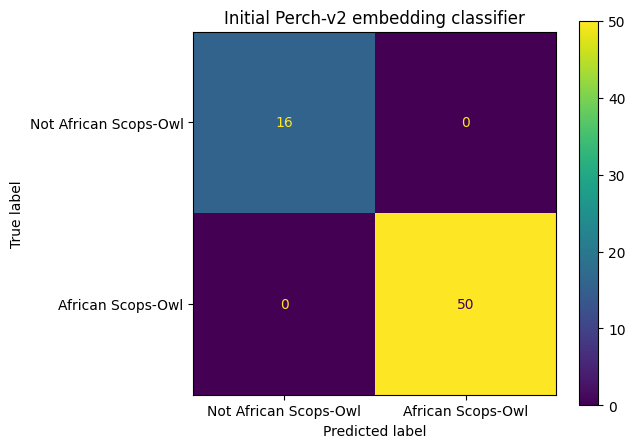

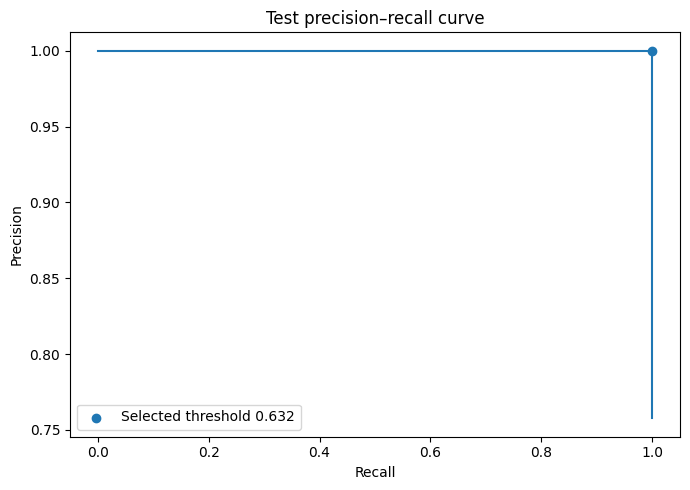


TEST CLIPS BY ORIGIN


,data_origin,label,predicted_label,clips
0,kenya_own_negative,0,0,16
1,xeno_canto,1,1,50



KENYAN NEGATIVES BY TYPE


,negative_type,predicted_label,clips,mean_probability,maximum_probability
0,background,0,2,0.0335,0.0375
1,other_bird,0,14,0.0230,0.0747



FALSE POSITIVES: 0

FALSE NEGATIVES: 0

Saved:
/content/drive/MyDrive/perch_african_scops_owl/reports/test_clip_predictions.csv
/content/drive/MyDrive/perch_african_scops_owl/reports/initial_test_metrics.json
/content/drive/MyDrive/perch_african_scops_owl/models/african_scops_owl_perch_v2_initial.joblib


In [ ]:
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)


# ------------------------------------------------------------
# Generate test predictions
# ------------------------------------------------------------

test_window_probabilities = (
    best_model.predict_proba(
        X_test
    )[:, 1]
)

test_clip_predictions = aggregate_clip_scores(
    test_metadata,
    test_window_probabilities,
)

test_clip_predictions[
    "predicted_label"
] = (
    test_clip_predictions[
        "probability"
    ]
    >= SELECTED_THRESHOLD
).astype(int)


test_labels = (
    test_clip_predictions[
        "label"
    ].to_numpy(dtype=int)
)

test_probabilities = (
    test_clip_predictions[
        "probability"
    ].to_numpy(dtype=float)
)

test_predicted_labels = (
    test_clip_predictions[
        "predicted_label"
    ].to_numpy(dtype=int)
)


# ------------------------------------------------------------
# Main metrics
# ------------------------------------------------------------

test_confusion_matrix = confusion_matrix(
    test_labels,
    test_predicted_labels,
    labels=[0, 1],
)

true_negative, false_positive, false_negative, true_positive = (
    test_confusion_matrix.ravel()
)

test_specificity = (
    true_negative
    / max(
        true_negative + false_positive,
        1,
    )
)

test_metrics = {
    "number_of_test_clips": int(
        len(test_clip_predictions)
    ),
    "number_of_positive_test_clips": int(
        test_labels.sum()
    ),
    "number_of_negative_test_clips": int(
        (test_labels == 0).sum()
    ),
    "threshold": float(
        SELECTED_THRESHOLD
    ),
    "precision": float(
        precision_score(
            test_labels,
            test_predicted_labels,
            zero_division=0,
        )
    ),
    "recall_sensitivity": float(
        recall_score(
            test_labels,
            test_predicted_labels,
            zero_division=0,
        )
    ),
    "specificity": float(
        test_specificity
    ),
    "f1": float(
        f1_score(
            test_labels,
            test_predicted_labels,
            zero_division=0,
        )
    ),
    "balanced_accuracy": float(
        balanced_accuracy_score(
            test_labels,
            test_predicted_labels,
        )
    ),
    "average_precision": float(
        average_precision_score(
            test_labels,
            test_probabilities,
        )
    ),
    "roc_auc": float(
        roc_auc_score(
            test_labels,
            test_probabilities,
        )
    ),
    "true_negative": int(
        true_negative
    ),
    "false_positive": int(
        false_positive
    ),
    "false_negative": int(
        false_negative
    ),
    "true_positive": int(
        true_positive
    ),
}


print("INITIAL TEST RESULTS")
print("--------------------")

display(
    pd.DataFrame(
        {
            "metric": list(
                test_metrics.keys()
            ),
            "value": list(
                test_metrics.values()
            ),
        }
    )
)


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=[
        "Not African Scops-Owl",
        "African Scops-Owl",
    ],
).plot()

plt.title(
    "Initial Perch-v2 embedding classifier"
)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Precision-recall curve
# ------------------------------------------------------------

curve_precision, curve_recall, curve_thresholds = (
    precision_recall_curve(
        test_labels,
        test_probabilities,
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    curve_recall,
    curve_precision,
)

plt.scatter(
    [test_metrics["recall_sensitivity"]],
    [test_metrics["precision"]],
    label=(
        f"Selected threshold "
        f"{SELECTED_THRESHOLD:.3f}"
    ),
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test precision–recall curve")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Breakdown by data source and class
# ------------------------------------------------------------

print("\nTEST CLIPS BY ORIGIN")

display(
    test_clip_predictions.groupby(
        [
            "data_origin",
            "label",
            "predicted_label",
        ],
        dropna=False,
    )
    .size()
    .rename("clips")
    .reset_index()
)


print("\nKENYAN NEGATIVES BY TYPE")

kenyan_test_negatives = (
    test_clip_predictions[
        (
            test_clip_predictions[
                "data_origin"
            ].eq("kenya_own_negative")
        )
        & (
            test_clip_predictions[
                "label"
            ].eq(0)
        )
    ]
)

display(
    kenyan_test_negatives.groupby(
        [
            "negative_type",
            "predicted_label",
        ],
        dropna=False,
    )
    .agg(
        clips=(
            "evaluation_clip_id",
            "count",
        ),
        mean_probability=(
            "probability",
            "mean",
        ),
        maximum_probability=(
            "probability",
            "max",
        ),
    )
    .reset_index()
    .round(4)
)


# ------------------------------------------------------------
# Show mistakes
# ------------------------------------------------------------

false_positives = (
    test_clip_predictions[
        (
            test_clip_predictions[
                "label"
            ] == 0
        )
        & (
            test_clip_predictions[
                "predicted_label"
            ] == 1
        )
    ]
    .sort_values(
        "probability",
        ascending=False,
    )
)

false_negatives = (
    test_clip_predictions[
        (
            test_clip_predictions[
                "label"
            ] == 1
        )
        & (
            test_clip_predictions[
                "predicted_label"
            ] == 0
        )
    ]
    .sort_values(
        "probability",
        ascending=True,
    )
)


print(
    "\nFALSE POSITIVES:",
    len(false_positives),
)

if not false_positives.empty:
    display(
        false_positives[
            [
                "probability",
                "data_origin",
                "negative_type",
                "filename",
                "xc_id",
                "filepath",
            ]
        ].head(20)
    )


print(
    "\nFALSE NEGATIVES:",
    len(false_negatives),
)

if not false_negatives.empty:
    display(
        false_negatives[
            [
                "probability",
                "data_origin",
                "country",
                "filename",
                "xc_id",
                "filepath",
            ]
        ].head(20)
    )


# ------------------------------------------------------------
# Save predictions and initial model
# ------------------------------------------------------------

TEST_PREDICTIONS_PATH = (
    PROJECT_ROOT /
    "reports/test_clip_predictions.csv"
)

TEST_METRICS_PATH = (
    PROJECT_ROOT /
    "reports/initial_test_metrics.json"
)

INITIAL_MODEL_PATH = (
    PROJECT_ROOT /
    "models/"
    "african_scops_owl_perch_v2_initial.joblib"
)

test_clip_predictions.to_csv(
    TEST_PREDICTIONS_PATH,
    index=False,
)

with open(
    TEST_METRICS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        test_metrics,
        file,
        indent=2,
    )


model_package = {
    "model_type": (
        "Perch v2 embedding logistic regression"
    ),
    "perch_model_name": "perch_v2",
    "classifier_pipeline": best_model,
    "decision_threshold": (
        SELECTED_THRESHOLD
    ),
    "clip_aggregation": (
        AGGREGATION_METHOD
    ),
    "target_sample_rate": int(
        TARGET_SAMPLE_RATE
    ),
    "window_seconds": float(
        WINDOW_SECONDS
    ),
    "embedding_dimension": int(
        model_embeddings.shape[1]
    ),
    "positive_class": (
        "african_scops_owl"
    ),
    "negative_class": (
        "not_african_scops_owl"
    ),
    "selected_C": float(
        BEST_C
    ),
    "random_seed": int(
        RANDOM_SEED
    ),
    "created_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "test_metrics": test_metrics,
}

joblib.dump(
    model_package,
    INITIAL_MODEL_PATH,
)


print("\nSaved:")
print(TEST_PREDICTIONS_PATH)
print(TEST_METRICS_PATH)
print(INITIAL_MODEL_PATH)

In [ ]:
#Above may have very very few false positives or negatives (model is over-confident)
#This will be due to not enough negatives in the XenoCanto data, and any supplied Kenya calls being assumed as negatives by the model!
#To fix, need to acquire more background calls, more other owl calls, more of the target Scops calls too, and some other unseen Kenya data for the model to be tested on
#Below will load the trained classifer

In [ ]:
import joblib
from pathlib import Path


INITIAL_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "african_scops_owl_perch_v2_initial.joblib"
)

if not INITIAL_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model not found:\n{INITIAL_MODEL_PATH}"
    )

model_package = joblib.load(
    INITIAL_MODEL_PATH
)

owl_classifier = model_package[
    "classifier_pipeline"
]

OWL_THRESHOLD = float(
    model_package["decision_threshold"]
)

OWL_AGGREGATION = model_package[
    "clip_aggregation"
]

print("Model loaded successfully.")
print("Model type:", model_package["model_type"])
print("Threshold:", round(OWL_THRESHOLD, 4))
print("Clip aggregation:", OWL_AGGREGATION)
print(
    "Embedding dimension:",
    model_package["embedding_dimension"],
)

Model loaded successfully.
Model type: Perch v2 embedding logistic regression
Threshold: 0.632
Clip aggregation: maximum
Embedding dimension: 1536


In [ ]:
#Define trimmed clip classifier

In [ ]:
import numpy as np
from pathlib import Path


INFERENCE_STRIDE_SECONDS = 2.5

INFERENCE_STRIDE_SAMPLES = int(
    round(
        INFERENCE_STRIDE_SECONDS
        * TARGET_SAMPLE_RATE
    )
)


def make_inference_windows(
    audio,
    stride_samples=INFERENCE_STRIDE_SAMPLES,
):
    """
    Create overlapping five-second windows.

    Clips shorter than five seconds are padded with silence.
    The final window is positioned to include the end of the clip.
    """
    audio = np.asarray(
        audio,
        dtype=np.float32,
    )

    if len(audio) == 0:
        raise ValueError(
            "The audio clip contains no samples."
        )

    if len(audio) <= WINDOW_SAMPLES:
        padded = np.pad(
            audio,
            (
                0,
                WINDOW_SAMPLES - len(audio),
            ),
            mode="constant",
        )

        return (
            padded.reshape(1, -1),
            np.array([0.0]),
        )

    final_start = (
        len(audio) - WINDOW_SAMPLES
    )

    start_samples = list(
        range(
            0,
            final_start + 1,
            stride_samples,
        )
    )

    if start_samples[-1] != final_start:
        start_samples.append(final_start)

    windows = np.vstack([
        audio[
            start:
            start + WINDOW_SAMPLES
        ]
        for start in start_samples
    ]).astype(np.float32)

    start_seconds = (
        np.asarray(start_samples)
        / TARGET_SAMPLE_RATE
    )

    return windows, start_seconds


def classify_trimmed_clip(filepath):
    """
    Classify one trimmed audio clip.

    Returns both the overall clip result and individual
    five-second window probabilities.
    """
    filepath = Path(filepath)

    if not filepath.exists():
        raise FileNotFoundError(
            f"Audio file not found:\n{filepath}"
        )

    audio = load_audio_for_perch(
        filepath
    )

    windows, window_starts = (
        make_inference_windows(audio)
    )

    embeddings = embed_windows(
        windows
    )

    window_probabilities = (
        owl_classifier.predict_proba(
            embeddings
        )[:, 1]
    )

    highest_index = int(
        np.argmax(window_probabilities)
    )

    clip_probability = float(
        window_probabilities[highest_index]
    )

    predicted_label = int(
        clip_probability >= OWL_THRESHOLD
    )

    window_results = [
        {
            "window_index": int(index),
            "window_start_seconds": float(
                window_starts[index]
            ),
            "window_end_seconds": float(
                window_starts[index]
                + WINDOW_SECONDS
            ),
            "probability": float(
                window_probabilities[index]
            ),
        }
        for index in range(
            len(window_probabilities)
        )
    ]

    return {
        "filepath": str(filepath),
        "filename": filepath.name,
        "duration_seconds": float(
            len(audio) / TARGET_SAMPLE_RATE
        ),
        "number_of_windows": int(
            len(window_probabilities)
        ),
        "african_scops_owl_probability": (
            clip_probability
        ),
        "threshold": OWL_THRESHOLD,
        "predicted_label": predicted_label,
        "predicted_class": (
            "african_scops_owl"
            if predicted_label == 1
            else "not_african_scops_owl"
        ),
        "highest_window_start_seconds": float(
            window_starts[highest_index]
        ),
        "window_results": window_results,
    }


print("Trimmed-clip classifier is ready.")

Trimmed-clip classifier is ready.


In [ ]:
#Test on a known clip

In [ ]:
example_filepath = own_manifest.iloc[0][
    "filepath"
]

example_result = classify_trimmed_clip(
    example_filepath
)

for key, value in example_result.items():
    if key != "window_results":
        print(f"{key}: {value}")

print("\nIndividual windows:")
display(
    pd.DataFrame(
        example_result["window_results"]
    )
)

filepath: /content/drive/MyDrive/perch_african_scops_owl/data/raw/own/positive/birdcall_021_00-14-47_to_00-14-51 = African Scops-Owl.wav
filename: birdcall_021_00-14-47_to_00-14-51 = African Scops-Owl.wav
duration_seconds: 4.0
number_of_windows: 1
african_scops_owl_probability: 0.8509445872481379
threshold: 0.6320255828538335
predicted_label: 1
predicted_class: african_scops_owl
highest_window_start_seconds: 0.0

Individual windows:


,window_index,window_start_seconds,window_end_seconds,probability
0,0,0.0,5.0,0.850945


In [ ]:
#Create challenge set folders - please be sure only to put new, previously unseen (by the model), and untouched clips into these folders!

In [ ]:
CHALLENGE_ROOT = (
    PROJECT_ROOT
    / "data"
    / "challenge_set"
)

CHALLENGE_POSITIVE_DIR = (
    CHALLENGE_ROOT / "positive"
)

CHALLENGE_NEGATIVE_OTHER_BIRD_DIR = (
    CHALLENGE_ROOT
    / "negative"
    / "other_bird"
)

CHALLENGE_NEGATIVE_BACKGROUND_DIR = (
    CHALLENGE_ROOT
    / "negative"
    / "background"
)

CHALLENGE_NEGATIVE_HARD_DIR = (
    CHALLENGE_ROOT
    / "negative"
    / "hard_negative"
)

for directory in [
    CHALLENGE_POSITIVE_DIR,
    CHALLENGE_NEGATIVE_OTHER_BIRD_DIR,
    CHALLENGE_NEGATIVE_BACKGROUND_DIR,
    CHALLENGE_NEGATIVE_HARD_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Challenge-set folders created:")
print(CHALLENGE_POSITIVE_DIR)
print(CHALLENGE_NEGATIVE_OTHER_BIRD_DIR)
print(CHALLENGE_NEGATIVE_BACKGROUND_DIR)
print(CHALLENGE_NEGATIVE_HARD_DIR)

Challenge-set folders created:
/content/drive/MyDrive/perch_african_scops_owl/data/challenge_set/positive
/content/drive/MyDrive/perch_african_scops_owl/data/challenge_set/negative/other_bird
/content/drive/MyDrive/perch_african_scops_owl/data/challenge_set/negative/background
/content/drive/MyDrive/perch_african_scops_owl/data/challenge_set/negative/hard_negative


In [ ]:
#Score an entire folder of new trimmed clips using the block below:

In [ ]:
import pandas as pd
from tqdm.auto import tqdm


SUPPORTED_AUDIO_EXTENSIONS = {
    ".wav",
    ".wave",
    ".flac",
    ".mp3",
    ".m4a",
    ".aac",
    ".ogg",
    ".opus",
}


INCOMING_CLIP_DIR = (
    PROJECT_ROOT
    / "data"
    / "incoming_trimmed_clips"
)

INCOMING_CLIP_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BATCH_PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "incoming_clip_predictions.csv"
)


audio_files = sorted([
    filepath
    for filepath in INCOMING_CLIP_DIR.rglob("*")
    if (
        filepath.is_file()
        and filepath.suffix.lower()
        in SUPPORTED_AUDIO_EXTENSIONS
    )
])

print(
    "Audio clips found:",
    len(audio_files),
)

batch_rows = []
failed_rows = []

for filepath in tqdm(
    audio_files,
    desc="Classifying trimmed clips",
):
    try:
        result = classify_trimmed_clip(
            filepath
        )

        batch_rows.append({
            key: value
            for key, value
            in result.items()
            if key != "window_results"
        })

    except Exception as error:
        failed_rows.append({
            "filepath": str(filepath),
            "error": str(error),
        })


batch_predictions = pd.DataFrame(
    batch_rows
)

if not batch_predictions.empty:
    batch_predictions = (
        batch_predictions
        .sort_values(
            "african_scops_owl_probability",
            ascending=False,
        )
        .reset_index(drop=True)
    )

batch_predictions.to_csv(
    BATCH_PREDICTIONS_PATH,
    index=False,
)


print("\nBATCH SUMMARY")
print("-------------")
print("Successfully classified:", len(batch_predictions))
print("Failed:", len(failed_rows))

if not batch_predictions.empty:
    print(
        "Predicted positive:",
        int(
            batch_predictions[
                "predicted_label"
            ].sum()
        ),
    )

    print(
        "Predicted negative:",
        int(
            (
                batch_predictions[
                    "predicted_label"
                ] == 0
            ).sum()
        ),
    )

    display(
        batch_predictions.head(30)
    )

if failed_rows:
    print("\nFAILED FILES")
    display(
        pd.DataFrame(failed_rows)
    )

print("\nSaved:")
print(BATCH_PREDICTIONS_PATH)

Audio clips found: 0


Classifying trimmed clips: 0it [00:00, ?it/s]


BATCH SUMMARY
-------------
Successfully classified: 0
Failed: 0

Saved:
/content/drive/MyDrive/perch_african_scops_owl/reports/incoming_clip_predictions.csv


In [ ]:
#PAUSE HERE - MANUAL STEP NEEDED:
#Place any already-trimmed clips you have into: MyDrive/perch_african_scops_owl/data/incoming_trimmed_clips/
#Once again - DO NOT ADD ANY FILES ALREADY SEEN BY THE MODEL INTO THESE FOLDERS
#Once new clips are loaded, you will need to re-run pre previous cell (cell 31 or something by my counts!)

In [ ]:
#Below will evaluate a labelled Kenya challenge set - only run after updating the folders with the new clips!!!

In [ ]:
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


challenge_sources = [
    (
        CHALLENGE_POSITIVE_DIR,
        1,
        "positive",
    ),
    (
        CHALLENGE_NEGATIVE_OTHER_BIRD_DIR,
        0,
        "other_bird",
    ),
    (
        CHALLENGE_NEGATIVE_BACKGROUND_DIR,
        0,
        "background",
    ),
    (
        CHALLENGE_NEGATIVE_HARD_DIR,
        0,
        "hard_negative",
    ),
]


challenge_rows = []
challenge_failures = []

for directory, true_label, category in (
    challenge_sources
):
    files = sorted([
        filepath
        for filepath in directory.rglob("*")
        if (
            filepath.is_file()
            and filepath.suffix.lower()
            in SUPPORTED_AUDIO_EXTENSIONS
        )
    ])

    for filepath in tqdm(
        files,
        desc=f"Scoring {category}",
    ):
        try:
            result = classify_trimmed_clip(
                filepath
            )

            challenge_rows.append({
                "filepath": str(filepath),
                "filename": filepath.name,
                "true_label": true_label,
                "category": category,
                "probability": result[
                    "african_scops_owl_probability"
                ],
                "predicted_label": result[
                    "predicted_label"
                ],
                "number_of_windows": result[
                    "number_of_windows"
                ],
            })

        except Exception as error:
            challenge_failures.append({
                "filepath": str(filepath),
                "error": str(error),
            })


challenge_predictions = pd.DataFrame(
    challenge_rows
)

if challenge_predictions.empty:
    raise RuntimeError(
        "No challenge-set audio files were found."
    )

challenge_labels = (
    challenge_predictions[
        "true_label"
    ].to_numpy(dtype=int)
)

challenge_predicted = (
    challenge_predictions[
        "predicted_label"
    ].to_numpy(dtype=int)
)

challenge_probabilities = (
    challenge_predictions[
        "probability"
    ].to_numpy(dtype=float)
)


matrix = confusion_matrix(
    challenge_labels,
    challenge_predicted,
    labels=[0, 1],
)

true_negative, false_positive, false_negative, true_positive = (
    matrix.ravel()
)

specificity = (
    true_negative
    / max(
        true_negative + false_positive,
        1,
    )
)


challenge_metrics = pd.DataFrame([
    {
        "clips": len(
            challenge_predictions
        ),
        "positive_clips": int(
            challenge_labels.sum()
        ),
        "negative_clips": int(
            (challenge_labels == 0).sum()
        ),
        "threshold": OWL_THRESHOLD,
        "precision": precision_score(
            challenge_labels,
            challenge_predicted,
            zero_division=0,
        ),
        "recall": recall_score(
            challenge_labels,
            challenge_predicted,
            zero_division=0,
        ),
        "specificity": specificity,
        "f1": f1_score(
            challenge_labels,
            challenge_predicted,
            zero_division=0,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                challenge_labels,
                challenge_predicted,
            )
        ),
        "average_precision": (
            average_precision_score(
                challenge_labels,
                challenge_probabilities,
            )
            if len(
                np.unique(challenge_labels)
            ) == 2
            else np.nan
        ),
        "roc_auc": (
            roc_auc_score(
                challenge_labels,
                challenge_probabilities,
            )
            if len(
                np.unique(challenge_labels)
            ) == 2
            else np.nan
        ),
        "true_negative": true_negative,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "true_positive": true_positive,
    }
])


print("KENYA CHALLENGE-SET RESULTS")
display(
    challenge_metrics.round(4)
)

print("\nRESULTS BY CATEGORY")

display(
    challenge_predictions.groupby(
        [
            "category",
            "true_label",
            "predicted_label",
        ]
    )
    .agg(
        clips=("filename", "count"),
        mean_probability=(
            "probability",
            "mean",
        ),
        maximum_probability=(
            "probability",
            "max",
        ),
    )
    .reset_index()
    .round(4)
)


print("\nHIGHEST-SCORING NEGATIVES")

display(
    challenge_predictions[
        challenge_predictions[
            "true_label"
        ] == 0
    ]
    .sort_values(
        "probability",
        ascending=False,
    )
    .head(30)
)


print("\nLOWEST-SCORING POSITIVES")

display(
    challenge_predictions[
        challenge_predictions[
            "true_label"
        ] == 1
    ]
    .sort_values(
        "probability",
        ascending=True,
    )
    .head(30)
)


ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=[
        "Not African Scops-Owl",
        "African Scops-Owl",
    ],
).plot()

plt.title(
    "Untouched Kenya challenge set"
)
plt.tight_layout()
plt.show()


CHALLENGE_PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "kenya_challenge_predictions.csv"
)

CHALLENGE_METRICS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "kenya_challenge_metrics.csv"
)

challenge_predictions.to_csv(
    CHALLENGE_PREDICTIONS_PATH,
    index=False,
)

challenge_metrics.to_csv(
    CHALLENGE_METRICS_PATH,
    index=False,
)

print("\nSaved:")
print(CHALLENGE_PREDICTIONS_PATH)
print(CHALLENGE_METRICS_PATH)

In [ ]:
# Create the production directories and configuration

In [ ]:
import json
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/perch_african_scops_owl"
)

PIPELINE_VERSION = "1.0.0"

PIPELINE_DIRS = {
    "scan_input": (
        PROJECT_ROOT / "data/hour_recordings_to_scan"
    ),
    "scan_cache": (
        PROJECT_ROOT / "embeddings/hour_scan_cache"
    ),
    "scan_results": (
        PROJECT_ROOT / "reports/hour_scan_results"
    ),
    "candidate_reviews": (
        PROJECT_ROOT / "metadata/hour_candidate_reviews"
    ),
    "mined_data": (
        PROJECT_ROOT / "embeddings/mined_reviewed_data"
    ),
    "releases": (
        PROJECT_ROOT / "releases"
    ),
    "environment": (
        PROJECT_ROOT / "environment"
    ),
}

for directory in PIPELINE_DIRS.values():
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


ACTIVE_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "african_scops_owl_perch_v2_initial.joblib"
)

PIPELINE_CONFIG_PATH = (
    PROJECT_ROOT
    / "metadata"
    / "pipeline_configuration.json"
)

configuration = {
    "pipeline_version": PIPELINE_VERSION,
    "project_name": (
        "African Scops-Owl Perch-v2 classifier"
    ),
    "target_scientific_name": (
        "Otus senegalensis"
    ),
    "target_common_name": (
        "African Scops-Owl"
    ),
    "perch_model_name": "perch_v2",
    "target_sample_rate": int(
        TARGET_SAMPLE_RATE
    ),
    "perch_window_seconds": float(
        WINDOW_SECONDS
    ),
    "inference_stride_seconds": 2.5,
    "embedding_dimension": 1536,
    "active_model_path": str(
        ACTIVE_MODEL_PATH
    ),
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
}

with open(
    PIPELINE_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        configuration,
        file,
        indent=2,
    )


# Capture the Python environment for reproducibility.
PIP_FREEZE_PATH = (
    PIPELINE_DIRS["environment"]
    / "pip_freeze.txt"
)

freeze_result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "freeze",
    ],
    capture_output=True,
    text=True,
    check=True,
)

PIP_FREEZE_PATH.write_text(
    freeze_result.stdout,
    encoding="utf-8",
)


print("Pipeline configuration:")
print(PIPELINE_CONFIG_PATH)

print("\nPython environment:")
print(PIP_FREEZE_PATH)

print("\nActive model:")
print(ACTIVE_MODEL_PATH)

print("\nHour-recording input folder:")
print(PIPELINE_DIRS["scan_input"])

In [ ]:
# Load any versioned ML model so far (with re-training or otherwise!)
#this should work with the existing model and with later, better, re-trained models

In [ ]:
import joblib
import numpy as np
from pathlib import Path


def load_owl_model_package(model_path):
    """
    Load and validate one saved African Scops-Owl model package.
    """
    model_path = Path(model_path)

    if not model_path.exists():
        raise FileNotFoundError(
            f"Model package not found:\n{model_path}"
        )

    package = joblib.load(model_path)

    required_keys = {
        "classifier_pipeline",
        "decision_threshold",
        "target_sample_rate",
        "window_seconds",
        "embedding_dimension",
    }

    missing_keys = (
        required_keys - set(package)
    )

    if missing_keys:
        raise RuntimeError(
            "Model package is missing keys: "
            + ", ".join(sorted(missing_keys))
        )

    if int(
        package["embedding_dimension"]
    ) != 1536:
        raise RuntimeError(
            "Unexpected model embedding dimension."
        )

    return package


def score_embedding_windows(
    embeddings,
    model_package,
):
    """
    Score one or more Perch embeddings.

    When a separate probability calibrator is present, it is
    applied to the classifier's raw decision values. Otherwise,
    the classifier's normal positive-class scores are returned.
    """
    embeddings = np.asarray(
        embeddings,
        dtype=np.float32,
    )

    if embeddings.ndim != 2:
        raise ValueError(
            "Embeddings must be a two-dimensional array."
        )

    classifier = model_package[
        "classifier_pipeline"
    ]

    calibrator = model_package.get(
        "probability_calibrator"
    )

    if calibrator is not None:
        raw_decisions = classifier.decision_function(
            embeddings
        )

        raw_decisions = np.asarray(
            raw_decisions,
            dtype=float,
        ).reshape(-1, 1)

        scores = calibrator.predict_proba(
            raw_decisions
        )[:, 1]

    else:
        scores = classifier.predict_proba(
            embeddings
        )[:, 1]

    return np.asarray(
        scores,
        dtype=float,
    )


active_model_package = load_owl_model_package(
    ACTIVE_MODEL_PATH
)

ACTIVE_THRESHOLD = float(
    active_model_package[
        "decision_threshold"
    ]
)

print("Model loaded.")
print(
    "Threshold:",
    round(ACTIVE_THRESHOLD, 4),
)

print(
    "Calibrated:",
    active_model_package.get(
        "probability_calibrator"
    ) is not None,
)

In [ ]:
# Stream hour-long audio recordings without cooking your RAM (highly recommened my me!)

In [ ]:
import hashlib
import re
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


SCAN_STRIDE_SECONDS = 2.5

SCAN_STRIDE_SAMPLES = int(
    round(
        SCAN_STRIDE_SECONDS
        * TARGET_SAMPLE_RATE
    )
)

SCAN_BATCH_SIZE = 16


def make_recording_id(filepath):
    """
    Create a stable identifier from filename and absolute path.
    """
    filepath = Path(filepath).resolve()

    safe_stem = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        filepath.stem,
    ).strip("_")

    path_hash = hashlib.sha1(
        str(filepath).encode("utf-8")
    ).hexdigest()[:10]

    return f"{safe_stem}_{path_hash}"


def stream_ffmpeg_windows(
    filepath,
    sample_rate=TARGET_SAMPLE_RATE,
    window_samples=WINDOW_SAMPLES,
    stride_samples=SCAN_STRIDE_SAMPLES,
    read_samples=262144,
):
    """
    Yield overlapping fixed-size float32 windows from any
    FFmpeg-readable audio file.

    The final incomplete window is padded only when audio remains
    beyond the last complete window.
    """
    filepath = Path(filepath)

    command = [
        "ffmpeg",
        "-nostdin",
        "-hide_banner",
        "-loglevel",
        "error",
        "-i",
        str(filepath),
        "-vn",
        "-ac",
        "1",
        "-ar",
        str(sample_rate),
        "-f",
        "f32le",
        "pipe:1",
    ]

    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )

    sample_buffer = np.empty(
        0,
        dtype=np.float32,
    )

    byte_remainder = b""
    total_samples_read = 0
    next_window_start = 0
    last_complete_window_end = 0

    try:
        while True:
            raw_bytes = process.stdout.read(
                read_samples * 4
            )

            if not raw_bytes:
                break

            raw_bytes = (
                byte_remainder + raw_bytes
            )

            usable_byte_count = (
                len(raw_bytes) // 4
            ) * 4

            usable_bytes = raw_bytes[
                :usable_byte_count
            ]

            byte_remainder = raw_bytes[
                usable_byte_count:
            ]

            if not usable_bytes:
                continue

            samples = np.frombuffer(
                usable_bytes,
                dtype="<f4",
            ).astype(
                np.float32,
                copy=True,
            )

            samples = np.nan_to_num(
                samples,
                nan=0.0,
                posinf=0.0,
                neginf=0.0,
            )

            total_samples_read += len(
                samples
            )

            sample_buffer = np.concatenate([
                sample_buffer,
                samples,
            ])

            while len(
                sample_buffer
            ) >= window_samples:

                window = sample_buffer[
                    :window_samples
                ].copy()

                yield (
                    window,
                    next_window_start
                    / sample_rate,
                )

                last_complete_window_end = (
                    next_window_start
                    + window_samples
                )

                sample_buffer = sample_buffer[
                    stride_samples:
                ]

                next_window_start += (
                    stride_samples
                )

        return_code = process.wait()

        error_message = (
            process.stderr.read()
            .decode(
                "utf-8",
                errors="replace",
            )
            .strip()
        )

        if return_code != 0:
            raise RuntimeError(
                "FFmpeg decoding failed:\n"
                + error_message
            )

        # Add one padded final window only when there is audio
        # beyond the end of the last complete window.
        if (
            len(sample_buffer) > 0
            and total_samples_read
            > last_complete_window_end
        ):
            final_window = sample_buffer[
                :window_samples
            ]

            if len(
                final_window
            ) < window_samples:
                final_window = np.pad(
                    final_window,
                    (
                        0,
                        window_samples
                        - len(final_window),
                    ),
                    mode="constant",
                )

            yield (
                final_window.astype(
                    np.float32
                ),
                next_window_start
                / sample_rate,
            )

    finally:
        if process.poll() is None:
            process.kill()

        if process.stdout is not None:
            process.stdout.close()

        if process.stderr is not None:
            process.stderr.close()


def scan_long_recording(
    filepath,
    model_package,
    cache_directory=PIPELINE_DIRS[
        "scan_cache"
    ],
    result_directory=PIPELINE_DIRS[
        "scan_results"
    ],
    batch_size=SCAN_BATCH_SIZE,
    overwrite=False,
):
    """
    Generate Perch embeddings and owl scores across one long file.

    Results are cached independently for each original recording.
    """
    filepath = Path(filepath)

    if not filepath.exists():
        raise FileNotFoundError(
            f"Recording not found:\n{filepath}"
        )

    cache_directory = Path(
        cache_directory
    )

    result_directory = Path(
        result_directory
    )

    cache_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    result_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    recording_id = make_recording_id(
        filepath
    )

    cache_path = (
        cache_directory
        / f"{recording_id}.npz"
    )

    windows_csv_path = (
        result_directory
        / f"{recording_id}_windows.csv"
    )

    if (
        cache_path.exists()
        and windows_csv_path.exists()
        and not overwrite
    ):
        cached_table = pd.read_csv(
            windows_csv_path
        )

        return {
            "recording_id": recording_id,
            "filepath": str(filepath),
            "cache_path": str(cache_path),
            "windows_csv_path": str(
                windows_csv_path
            ),
            "windows": len(cached_table),
            "maximum_score": float(
                cached_table[
                    "owl_score"
                ].max()
            ),
            "status": "already_present",
        }

    embedding_blocks = []
    score_blocks = []
    start_time_blocks = []

    pending_windows = []
    pending_starts = []

    def flush_pending_batch():
        nonlocal pending_windows
        nonlocal pending_starts

        if not pending_windows:
            return

        window_array = np.vstack(
            pending_windows
        ).astype(np.float32)

        embedding_array = embed_windows(
            window_array
        )

        score_array = score_embedding_windows(
            embedding_array,
            model_package,
        )

        embedding_blocks.append(
            embedding_array
        )

        score_blocks.append(
            score_array
        )

        start_time_blocks.append(
            np.asarray(
                pending_starts,
                dtype=float,
            )
        )

        pending_windows = []
        pending_starts = []

    window_iterator = stream_ffmpeg_windows(
        filepath
    )

    for audio_window, start_seconds in tqdm(
        window_iterator,
        desc=f"Scanning {filepath.name}",
        unit="window",
    ):
        pending_windows.append(
            audio_window
        )

        pending_starts.append(
            start_seconds
        )

        if len(
            pending_windows
        ) >= batch_size:
            flush_pending_batch()

    flush_pending_batch()

    if not embedding_blocks:
        raise RuntimeError(
            "The recording produced no audio windows."
        )

    embeddings = np.vstack(
        embedding_blocks
    ).astype(np.float32)

    scores = np.concatenate(
        score_blocks
    ).astype(float)

    starts = np.concatenate(
        start_time_blocks
    ).astype(float)

    if not (
        len(embeddings)
        == len(scores)
        == len(starts)
    ):
        raise RuntimeError(
            "Long-recording output arrays differ in length."
        )

    np.savez_compressed(
        cache_path,
        embeddings=embeddings,
        scores=scores,
        starts=starts,
        stride_seconds=np.array([
            SCAN_STRIDE_SECONDS
        ]),
        window_seconds=np.array([
            WINDOW_SECONDS
        ]),
    )

    window_table = pd.DataFrame({
        "recording_id": recording_id,
        "source_group": (
            "kenya_hour::"
            + recording_id
        ),
        "filepath": str(filepath),
        "filename": filepath.name,
        "window_index": np.arange(
            len(starts),
            dtype=int,
        ),
        "window_start_seconds": starts,
        "window_end_seconds": (
            starts + WINDOW_SECONDS
        ),
        "owl_score": scores,
        "predicted_label": (
            scores
            >= float(
                model_package[
                    "decision_threshold"
                ]
            )
        ).astype(int),
        "decision_threshold": float(
            model_package[
                "decision_threshold"
            ]
        ),
        "embedding_row": np.arange(
            len(starts),
            dtype=int,
        ),
        "embedding_cache_path": str(
            cache_path
        ),
    })

    window_table.to_csv(
        windows_csv_path,
        index=False,
    )

    return {
        "recording_id": recording_id,
        "filepath": str(filepath),
        "cache_path": str(cache_path),
        "windows_csv_path": str(
            windows_csv_path
        ),
        "windows": len(window_table),
        "maximum_score": float(
            window_table["owl_score"].max()
        ),
        "windows_above_threshold": int(
            window_table[
                "predicted_label"
            ].sum()
        ),
        "status": "scanned",
    }


print("Streaming scanner is ready.")

In [ ]:
# Now on to batch-selecting and detections within files
# Place anything from the hour of interest in your: 'MyDrive/perch_african_scops_owl/data/hour_recordings_to_scan/' folder
# Note that they can also be in date and time-specific subfolders if you are dealing with larger datasets

In [ ]:
SUPPORTED_AUDIO_EXTENSIONS = {
    ".wav",
    ".wave",
    ".flac",
    ".mp3",
    ".m4a",
    ".aac",
    ".ogg",
    ".opus",
}


SCAN_INPUT_ROOT = PIPELINE_DIRS[
    "scan_input"
]

hour_recording_files = sorted([
    filepath
    for filepath
    in SCAN_INPUT_ROOT.rglob("*")
    if (
        filepath.is_file()
        and filepath.suffix.lower()
        in SUPPORTED_AUDIO_EXTENSIONS
    )
])


# Set this to an integer while testing, such as 2.
# Leave as None to scan every file found.
MAX_FILES_TO_SCAN = None

if MAX_FILES_TO_SCAN is not None:
    hour_recording_files = (
        hour_recording_files[
            :MAX_FILES_TO_SCAN
        ]
    )


print(
    "Hour recordings found:",
    len(hour_recording_files),
)

for filepath in hour_recording_files[:10]:
    print(filepath)


scan_summary_rows = []
scan_failures = []

for filepath in hour_recording_files:
    try:
        result = scan_long_recording(
            filepath=filepath,
            model_package=(
                active_model_package
            ),
            overwrite=False,
        )

        scan_summary_rows.append(
            result
        )

    except Exception as error:
        scan_failures.append({
            "filepath": str(filepath),
            "error": str(error),
        })


scan_summary = pd.DataFrame(
    scan_summary_rows
)

SCAN_SUMMARY_PATH = (
    PIPELINE_DIRS["scan_results"]
    / "hour_scan_summary.csv"
)

scan_summary.to_csv(
    SCAN_SUMMARY_PATH,
    index=False,
)


print("\nSCAN SUMMARY")

if not scan_summary.empty:
    display(
        scan_summary.sort_values(
            "maximum_score",
            ascending=False,
        )
    )

if scan_failures:
    print("\nFAILED RECORDINGS")

    display(
        pd.DataFrame(
            scan_failures
        )
    )

print("\nSaved:")
print(SCAN_SUMMARY_PATH)

In [ ]:
# The next part will do a review of the highest scoring clips for double-checking, and for reducing the false-positive rates
# This will build a bank of "hard negatives" which is very important for ML training

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path


CANDIDATE_REVIEW_PATH = (
    PIPELINE_DIRS["candidate_reviews"]
    / "hour_scan_candidate_review.csv"
)

MINIMUM_CANDIDATES_PER_RECORDING = 15
MAXIMUM_CANDIDATES_PER_RECORDING = 80
MINIMUM_TIME_SEPARATION_SECONDS = 10.0


window_result_files = sorted(
    PIPELINE_DIRS["scan_results"].glob(
        "*_windows.csv"
    )
)

if not window_result_files:
    raise RuntimeError(
        "No long-recording window result files were found."
    )


all_window_tables = pd.concat(
    [
        pd.read_csv(filepath)
        for filepath
        in window_result_files
    ],
    ignore_index=True,
)


def select_spaced_candidates(
    group,
    threshold,
    minimum_count=(
        MINIMUM_CANDIDATES_PER_RECORDING
    ),
    maximum_count=(
        MAXIMUM_CANDIDATES_PER_RECORDING
    ),
    minimum_separation_seconds=(
        MINIMUM_TIME_SEPARATION_SECONDS
    ),
):
    """
    Select high-scoring windows while avoiding near-duplicate
    overlapping windows around the same sound.
    """
    group = group.sort_values(
        "owl_score",
        ascending=False,
    )

    above_threshold_count = int(
        (
            group["owl_score"]
            >= threshold
        ).sum()
    )

    borderline_count = int(
        (
            group["owl_score"]
            >= threshold * 0.50
        ).sum()
    )

    desired_count = max(
        minimum_count,
        above_threshold_count,
        min(
            borderline_count,
            maximum_count,
        ),
    )

    desired_count = min(
        desired_count,
        maximum_count,
    )

    selected_rows = []
    selected_start_times = []

    for _, row in group.iterrows():
        start_time = float(
            row["window_start_seconds"]
        )

        sufficiently_separated = all(
            abs(
                start_time
                - existing_start
            )
            >= minimum_separation_seconds
            for existing_start
            in selected_start_times
        )

        if not sufficiently_separated:
            continue

        selected_rows.append(
            row
        )

        selected_start_times.append(
            start_time
        )

        if len(
            selected_rows
        ) >= desired_count:
            break

    return pd.DataFrame(
        selected_rows
    )


candidate_blocks = []

for recording_id, group in (
    all_window_tables.groupby(
        "recording_id"
    )
):
    threshold = float(
        group[
            "decision_threshold"
        ].iloc[0]
    )

    selected = select_spaced_candidates(
        group,
        threshold=threshold,
    )

    candidate_blocks.append(
        selected
    )


candidate_review = pd.concat(
    candidate_blocks,
    ignore_index=True,
)

candidate_review = (
    candidate_review
    .sort_values(
        [
            "owl_score",
            "recording_id",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

candidate_review.insert(
    0,
    "candidate_id",
    [
        f"candidate_{index:06d}"
        for index
        in range(
            len(candidate_review)
        )
    ],
)

candidate_review[
    "candidate_tier"
] = np.select(
    [
        candidate_review[
            "owl_score"
        ]
        >= candidate_review[
            "decision_threshold"
        ],

        candidate_review[
            "owl_score"
        ]
        >= (
            candidate_review[
                "decision_threshold"
            ]
            * 0.50
        ),
    ],
    [
        "above_threshold",
        "borderline",
    ],
    default="top_negative_candidate",
)

candidate_review[
    "review_label"
] = "unreviewed"

candidate_review[
    "review_notes"
] = ""

candidate_review[
    "call_completeness"
] = ""

candidate_review[
    "target_audibility"
] = ""

candidate_review[
    "review_order"
] = np.arange(
    len(candidate_review),
    dtype=int,
)


# Preserve any earlier labels when rebuilding the queue.
if CANDIDATE_REVIEW_PATH.exists():
    previous = pd.read_csv(
        CANDIDATE_REVIEW_PATH
    )

    previous = (
        previous
        .drop_duplicates(
            "candidate_id",
            keep="last",
        )
        .set_index("candidate_id")
    )

    for column in [
        "review_label",
        "review_notes",
        "call_completeness",
        "target_audibility",
    ]:
        if column in previous.columns:
            candidate_review[column] = (
                candidate_review[
                    "candidate_id"
                ]
                .map(
                    previous[column]
                )
                .fillna(
                    candidate_review[
                        column
                    ]
                )
            )


candidate_review.to_csv(
    CANDIDATE_REVIEW_PATH,
    index=False,
)


print(
    "Candidate windows:",
    len(candidate_review),
)

print(
    "Source recordings:",
    candidate_review[
        "recording_id"
    ].nunique(),
)

print("\nCANDIDATES BY TIER")

display(
    candidate_review[
        "candidate_tier"
    ]
    .value_counts()
    .rename("windows")
    .reset_index()
)

print("\nSaved:")
print(CANDIDATE_REVIEW_PATH)

In [ ]:
# the previous bit loaded up the queue, now you need to launch the reviewer tool (use the bit below) to check them over like
#you did beforehand in the Gradio reviewer page I made

In [ ]:
# PAUSE HERE FOR MANUAL STEP NEXT UP!
# Note that the high-value review order is as follows: Every candidate above the threshold; those close to the threshold;
#and any highest-scoring remaining negatives
# You are aiming fro around 200 confirmed hard negatives here to improve the accuracy as a first pass - but more is always better!

In [ ]:
!pip install -q --upgrade "gradio>=5,<7"

import io
import secrets
import subprocess
import threading
from pathlib import Path

import gradio as gr
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image


CANDIDATE_CONTEXT_SECONDS = 1.0
CANDIDATE_REVIEW_DURATION = (
    WINDOW_SECONDS
    + 2 * CANDIDATE_CONTEXT_SECONDS
)


candidate_df = pd.read_csv(
    CANDIDATE_REVIEW_PATH
)

candidate_df = (
    candidate_df
    .sort_values("review_order")
    .reset_index(drop=True)
)

for column, default in {
    "review_label": "unreviewed",
    "review_notes": "",
    "call_completeness": "",
    "target_audibility": "",
}.items():
    if column not in candidate_df.columns:
        candidate_df[column] = default

    candidate_df[column] = (
        candidate_df[column]
        .fillna(default)
        .astype(str)
    )


candidate_lock = threading.Lock()


def extract_audio_segment_ffmpeg(
    filepath,
    start_seconds,
    duration_seconds,
):
    """
    Read one short segment directly from a long recording.
    """
    start_seconds = max(
        0.0,
        float(start_seconds),
    )

    command = [
        "ffmpeg",
        "-nostdin",
        "-hide_banner",
        "-loglevel",
        "error",
        "-ss",
        f"{start_seconds:.6f}",
        "-i",
        str(filepath),
        "-t",
        f"{duration_seconds:.6f}",
        "-vn",
        "-ac",
        "1",
        "-ar",
        str(TARGET_SAMPLE_RATE),
        "-f",
        "f32le",
        "pipe:1",
    ]

    result = subprocess.run(
        command,
        capture_output=True,
        check=True,
    )

    audio = np.frombuffer(
        result.stdout,
        dtype="<f4",
    ).astype(
        np.float32,
        copy=True,
    )

    expected_samples = int(
        round(
            duration_seconds
            * TARGET_SAMPLE_RATE
        )
    )

    if len(audio) < expected_samples:
        audio = np.pad(
            audio,
            (
                0,
                expected_samples
                - len(audio),
            ),
        )

    return audio[
        :expected_samples
    ]


def make_candidate_spectrogram(
    audio,
):
    spectrum = np.abs(
        librosa.stft(
            audio,
            n_fft=2048,
            hop_length=256,
        )
    )

    spectrum_db = librosa.amplitude_to_db(
        spectrum,
        ref=max(
            float(spectrum.max()),
            1e-12,
        ),
    )

    figure, axis = plt.subplots(
        figsize=(12, 4)
    )

    image = librosa.display.specshow(
        spectrum_db,
        sr=TARGET_SAMPLE_RATE,
        hop_length=256,
        x_axis="time",
        y_axis="hz",
        ax=axis,
    )

    axis.set_ylim(
        0,
        min(
            8000,
            TARGET_SAMPLE_RATE / 2,
        ),
    )

    figure.colorbar(
        image,
        ax=axis,
        format="%+2.0f dB",
    )

    figure.tight_layout()

    buffer = io.BytesIO()

    figure.savefig(
        buffer,
        format="png",
        dpi=120,
        bbox_inches="tight",
    )

    plt.close(figure)

    buffer.seek(0)

    output_image = (
        Image.open(buffer)
        .convert("RGB")
        .copy()
    )

    buffer.close()

    return output_image


def save_candidate_review():
    temporary_path = Path(
        str(CANDIDATE_REVIEW_PATH)
        + ".temporary"
    )

    candidate_df.to_csv(
        temporary_path,
        index=False,
    )

    temporary_path.replace(
        CANDIDATE_REVIEW_PATH
    )


def first_unreviewed_candidate():
    positions = np.flatnonzero(
        candidate_df[
            "review_label"
        ].eq("unreviewed")
    )

    return (
        int(positions[0])
        if len(positions)
        else 0
    )


def next_unreviewed_candidate(
    current_position,
):
    order = list(
        range(
            current_position + 1,
            len(candidate_df),
        )
    ) + list(
        range(
            0,
            current_position + 1,
        )
    )

    for position in order:
        if (
            candidate_df.at[
                position,
                "review_label",
            ]
            == "unreviewed"
        ):
            return position

    return current_position


def candidate_progress():
    counts = (
        candidate_df[
            "review_label"
        ]
        .value_counts()
        .to_dict()
    )

    return (
        "### Review progress\n\n"
        f"**Positive:** "
        f"{counts.get('positive', 0):,}  |  "
        f"**Negative:** "
        f"{counts.get('negative', 0):,}  |  "
        f"**Uncertain:** "
        f"{counts.get('uncertain', 0):,}  |  "
        f"**Excluded:** "
        f"{counts.get('exclude', 0):,}  |  "
        f"**Unreviewed:** "
        f"{counts.get('unreviewed', 0):,}"
    )


def show_candidate(
    position,
    status="Ready for review.",
):
    position = int(
        np.clip(
            position,
            0,
            len(candidate_df) - 1,
        )
    )

    row = candidate_df.iloc[
        position
    ]

    context_start = max(
        0.0,
        float(
            row[
                "window_start_seconds"
            ]
        )
        - CANDIDATE_CONTEXT_SECONDS,
    )

    audio = extract_audio_segment_ffmpeg(
        filepath=row["filepath"],
        start_seconds=context_start,
        duration_seconds=(
            CANDIDATE_REVIEW_DURATION
        ),
    )

    details = (
        f"## {row['candidate_id']}\n\n"
        f"**Position:** {position + 1:,} of "
        f"{len(candidate_df):,}  \n"
        f"**Recording:** {row['filename']}  \n"
        f"**Original window:** "
        f"{float(row['window_start_seconds']):.1f}–"
        f"{float(row['window_end_seconds']):.1f} seconds  \n"
        f"**Model score:** "
        f"{float(row['owl_score']):.4f}  \n"
        f"**Threshold:** "
        f"{float(row['decision_threshold']):.4f}  \n"
        f"**Candidate tier:** "
        f"{row['candidate_tier']}  \n"
        f"**Current label:** "
        f"{row['review_label']}"
    )

    audibility = str(
        row["target_audibility"]
    )

    if audibility not in {
        "clear",
        "moderate",
        "weak",
        "uncertain",
    }:
        audibility = "clear"

    completeness = str(
        row["call_completeness"]
    )

    if completeness not in {
        "complete",
        "truncated",
        "sequence",
        "unclear",
    }:
        completeness = "complete"

    notes = str(
        row["review_notes"]
    )

    if notes.casefold() == "nan":
        notes = ""

    return (
        candidate_progress(),
        details,
        (
            TARGET_SAMPLE_RATE,
            audio,
        ),
        make_candidate_spectrogram(
            audio
        ),
        audibility,
        completeness,
        notes,
        position,
        status,
    )


def save_candidate_label(
    label,
    position,
    audibility,
    completeness,
    notes,
):
    position = int(position)

    with candidate_lock:
        candidate_df.at[
            position,
            "review_label",
        ] = label

        candidate_df.at[
            position,
            "review_notes",
        ] = str(
            notes or ""
        ).strip()

        if label in {
            "positive",
            "uncertain",
        }:
            candidate_df.at[
                position,
                "target_audibility",
            ] = audibility

            candidate_df.at[
                position,
                "call_completeness",
            ] = completeness

        else:
            candidate_df.at[
                position,
                "target_audibility",
            ] = ""

            candidate_df.at[
                position,
                "call_completeness",
            ] = ""

        save_candidate_review()

        next_position = (
            next_unreviewed_candidate(
                position
            )
        )

    return show_candidate(
        next_position,
        f"Saved **{label}**.",
    )


def previous_candidate(position):
    return show_candidate(
        max(
            0,
            int(position) - 1,
        ),
        "Moved to previous candidate.",
    )


def skip_candidate(position):
    return show_candidate(
        (
            int(position) + 1
        ) % len(candidate_df),
        "Skipped without changing label.",
    )


starting_position = (
    first_unreviewed_candidate()
)

initial_values = show_candidate(
    starting_position
)

gr.close_all()

with gr.Blocks(
    title=(
        "African Scops-Owl Kenya Review"
    ),
    analytics_enabled=False,
) as kenya_review_app:

    gr.Markdown(
        "# Kenya hard-negative and detection review"
    )

    position_state = gr.State(
        value=initial_values[7]
    )

    progress_display = gr.Markdown(
        value=initial_values[0]
    )

    detail_display = gr.Markdown(
        value=initial_values[1]
    )

    audio_display = gr.Audio(
        value=initial_values[2],
        interactive=False,
        label="Candidate audio",
    )

    spectrogram_display = gr.Image(
        value=initial_values[3],
        interactive=False,
        label="Spectrogram",
    )

    with gr.Row():
        audibility_input = gr.Dropdown(
            choices=[
                "clear",
                "moderate",
                "weak",
                "uncertain",
            ],
            value=initial_values[4],
            label="Target audibility",
        )

        completeness_input = gr.Dropdown(
            choices=[
                "complete",
                "truncated",
                "sequence",
                "unclear",
            ],
            value=initial_values[5],
            label="Call completeness",
        )

    notes_input = gr.Textbox(
        value=initial_values[6],
        lines=3,
        label="Notes",
    )

    with gr.Row():
        positive_button = gr.Button(
            "Positive",
            variant="primary",
        )

        negative_button = gr.Button(
            "Negative",
            variant="stop",
        )

        uncertain_button = gr.Button(
            "Uncertain",
        )

        exclude_button = gr.Button(
            "Exclude",
        )

    with gr.Row():
        previous_button = gr.Button(
            "Previous"
        )

        skip_button = gr.Button(
            "Skip"
        )

    status_display = gr.Markdown(
        value=initial_values[8]
    )

    callback_inputs = [
        position_state,
        audibility_input,
        completeness_input,
        notes_input,
    ]

    callback_outputs = [
        progress_display,
        detail_display,
        audio_display,
        spectrogram_display,
        audibility_input,
        completeness_input,
        notes_input,
        position_state,
        status_display,
    ]

    positive_button.click(
        lambda p, a, c, n:
            save_candidate_label(
                "positive",
                p,
                a,
                c,
                n,
            ),
        inputs=callback_inputs,
        outputs=callback_outputs,
    )

    negative_button.click(
        lambda p, a, c, n:
            save_candidate_label(
                "negative",
                p,
                a,
                c,
                n,
            ),
        inputs=callback_inputs,
        outputs=callback_outputs,
    )

    uncertain_button.click(
        lambda p, a, c, n:
            save_candidate_label(
                "uncertain",
                p,
                a,
                c,
                n,
            ),
        inputs=callback_inputs,
        outputs=callback_outputs,
    )

    exclude_button.click(
        lambda p, a, c, n:
            save_candidate_label(
                "exclude",
                p,
                a,
                c,
                n,
            ),
        inputs=callback_inputs,
        outputs=callback_outputs,
    )

    previous_button.click(
        previous_candidate,
        inputs=[position_state],
        outputs=callback_outputs,
    )

    skip_button.click(
        skip_candidate,
        inputs=[position_state],
        outputs=callback_outputs,
    )


APP_USERNAME = "reviewer"
APP_PASSWORD = secrets.token_urlsafe(8)

print("Open the Gradio link below in a new tab.")
print("Username:", APP_USERNAME)
print("Password:", APP_PASSWORD)

kenya_review_app.launch(
    share=True,
    inline=False,
    auth=(
        APP_USERNAME,
        APP_PASSWORD,
    ),
    debug=True,
    show_error=True,
    blocked_paths=[
        str(PROJECT_ROOT)
    ],
    footer_links=[],
)

In [ ]:
# After you have reviewed your few hundred clips, next up will be convert those reviewed clips (once you have made them) into the
#next load of training examples for the model!

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path


MINED_METADATA_PATH = (
    PIPELINE_DIRS["mined_data"]
    / "mined_reviewed_manifest.csv"
)

MINED_EMBEDDINGS_PATH = (
    PIPELINE_DIRS["mined_data"]
    / "mined_reviewed_embeddings.npz"
)


candidate_review = pd.read_csv(
    CANDIDATE_REVIEW_PATH
)

mined_reviewed = candidate_review[
    candidate_review[
        "review_label"
    ].isin([
        "positive",
        "negative",
    ])
].copy()


if mined_reviewed.empty:
    raise RuntimeError(
        "No positive or negative scan candidates "
        "have been reviewed yet."
    )


embedding_cache = {}
mined_embedding_rows = []

for _, row in mined_reviewed.iterrows():
    cache_path = str(
        row[
            "embedding_cache_path"
        ]
    )

    if cache_path not in embedding_cache:
        archive = np.load(
            cache_path,
            allow_pickle=False,
        )

        embedding_cache[
            cache_path
        ] = archive[
            "embeddings"
        ].astype(np.float32)

    cache_embeddings = (
        embedding_cache[
            cache_path
        ]
    )

    embedding_row = int(
        row["embedding_row"]
    )

    mined_embedding_rows.append(
        cache_embeddings[
            embedding_row
        ]
    )


mined_embeddings = np.vstack(
    mined_embedding_rows
).astype(np.float32)


mined_metadata = pd.DataFrame({
    "sample_id": (
        "kenya_mined::"
        + mined_reviewed[
            "candidate_id"
        ].astype(str)
    ),
    "evaluation_clip_id": (
        "kenya_mined_clip::"
        + mined_reviewed[
            "candidate_id"
        ].astype(str)
    ),
    "source_group": (
        mined_reviewed[
            "source_group"
        ].astype(str)
    ),
    "label": (
        mined_reviewed[
            "review_label"
        ]
        .map({
            "positive": 1,
            "negative": 0,
        })
        .astype(int)
    ),
    "class_name": (
        mined_reviewed[
            "review_label"
        ]
        .map({
            "positive": (
                "african_scops_owl"
            ),
            "negative": (
                "not_african_scops_owl"
            ),
        })
    ),
    "data_origin": "kenya_mined",
    "negative_type": np.where(
        mined_reviewed[
            "review_label"
        ].eq("negative"),
        "hard_negative",
        "",
    ),
    "clip_id": (
        mined_reviewed[
            "candidate_id"
        ].astype(str)
    ),
    "filename": (
        mined_reviewed[
            "filename"
        ].astype(str)
    ),
    "filepath": (
        mined_reviewed[
            "filepath"
        ].astype(str)
    ),
    "xc_id": "",
    "country": "Kenya",
    "window_start_seconds": (
        mined_reviewed[
            "window_start_seconds"
        ].astype(float)
    ),
    "window_end_seconds": (
        mined_reviewed[
            "window_end_seconds"
        ].astype(float)
    ),
    "review_notes": (
        mined_reviewed[
            "review_notes"
        ].fillna("")
    ),
    "target_audibility": (
        mined_reviewed[
            "target_audibility"
        ].fillna("")
    ),
    "call_completeness": (
        mined_reviewed[
            "call_completeness"
        ].fillna("")
    ),
})


mined_metadata.insert(
    0,
    "embedding_row",
    np.arange(
        len(mined_metadata),
        dtype=int,
    ),
)


mined_metadata.to_csv(
    MINED_METADATA_PATH,
    index=False,
)

np.savez_compressed(
    MINED_EMBEDDINGS_PATH,
    embeddings=mined_embeddings,
)


print("MINED DATASET")
print("-------------")
print(
    "Embedding shape:",
    mined_embeddings.shape,
)

display(
    mined_metadata[
        "class_name"
    ]
    .value_counts()
    .rename("windows")
    .reset_index()
)

print(
    "\nIndependent source hours:",
    mined_metadata[
        "source_group"
    ].nunique(),
)

print("\nSaved:")
print(MINED_METADATA_PATH)
print(MINED_EMBEDDINGS_PATH)

In [ ]:
# Now we train the model on those examples that have been reviewed (make sure this is only run after the previous cell is done!)
# After this, you should have an improved model v2.0!

In [ ]:
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


NEW_MODEL_VERSION = "0.2.0"
TARGET_VALIDATION_RECALL = 0.95


BASE_MANIFEST_PATH = (
    PROJECT_ROOT
    / "metadata"
    / "combined_training_manifest.csv"
)

BASE_EMBEDDINGS_PATH = (
    PROJECT_ROOT
    / "embeddings"
    / "combined_training_embeddings.npz"
)


base_metadata = pd.read_csv(
    BASE_MANIFEST_PATH
)

base_embeddings = np.load(
    BASE_EMBEDDINGS_PATH,
    allow_pickle=False,
)["embeddings"].astype(np.float32)


mined_metadata = pd.read_csv(
    MINED_METADATA_PATH
)

mined_embeddings = np.load(
    MINED_EMBEDDINGS_PATH,
    allow_pickle=False,
)["embeddings"].astype(np.float32)


if len(base_metadata) != len(
    base_embeddings
):
    raise RuntimeError(
        "Base metadata and embeddings differ in length."
    )

if len(mined_metadata) != len(
    mined_embeddings
):
    raise RuntimeError(
        "Mined metadata and embeddings differ in length."
    )


# Assign entire mined source hours to training or validation.
mined_groups = np.array(
    sorted(
        mined_metadata[
            "source_group"
        ].unique()
    ),
    dtype=object,
)

generator = np.random.default_rng(
    RANDOM_SEED + 20
)

generator.shuffle(
    mined_groups
)

if len(mined_groups) >= 3:
    number_validation_groups = max(
        1,
        int(
            round(
                len(mined_groups)
                * 0.20
            )
        ),
    )
else:
    number_validation_groups = 0


mined_validation_groups = set(
    mined_groups[
        :number_validation_groups
    ]
)

mined_metadata[
    "split"
] = mined_metadata[
    "source_group"
].map(
    lambda group: (
        "validation"
        if group
        in mined_validation_groups
        else "train"
    )
)


# Align columns before concatenation.
combined_columns = sorted(
    set(base_metadata.columns)
    | set(mined_metadata.columns)
)

for column in combined_columns:
    if column not in base_metadata.columns:
        base_metadata[column] = ""

    if column not in mined_metadata.columns:
        mined_metadata[column] = ""


training_metadata = pd.concat(
    [
        base_metadata[
            combined_columns
        ],
        mined_metadata[
            combined_columns
        ],
    ],
    ignore_index=True,
)

training_embeddings = np.vstack([
    base_embeddings,
    mined_embeddings,
]).astype(np.float32)

training_metadata[
    "dataset_row"
] = np.arange(
    len(training_metadata),
    dtype=int,
)


# Verify that no source group crosses splits.
split_counts = (
    training_metadata.groupby(
        "source_group"
    )["split"]
    .nunique()
)

if (
    split_counts > 1
).any():
    leaking_groups = split_counts[
        split_counts > 1
    ]

    display(leaking_groups)

    raise RuntimeError(
        "Source-group leakage detected."
    )


def aggregate_scores_by_clip(
    metadata,
    scores,
):
    table = metadata.copy()

    table["score"] = np.asarray(
        scores,
        dtype=float,
    )

    aggregated = (
        table.groupby(
            "evaluation_clip_id",
            as_index=False,
        )
        .agg(
            label=("label", "first"),
            score=("score", "max"),
            source_group=(
                "source_group",
                "first",
            ),
            data_origin=(
                "data_origin",
                "first",
            ),
            filename=(
                "filename",
                "first",
            ),
            filepath=(
                "filepath",
                "first",
            ),
        )
    )

    return aggregated


train_mask = (
    training_metadata[
        "split"
    ].eq("train")
    .to_numpy()
)

validation_mask = (
    training_metadata[
        "split"
    ].eq("validation")
    .to_numpy()
)

locked_test_mask = (
    training_metadata[
        "split"
    ].eq("test")
    .to_numpy()
)


X_train = training_embeddings[
    train_mask
]

y_train = training_metadata.loc[
    train_mask,
    "label",
].astype(int).to_numpy()

train_rows = training_metadata.loc[
    train_mask
].reset_index(drop=True)


X_validation = training_embeddings[
    validation_mask
]

y_validation = training_metadata.loc[
    validation_mask,
    "label",
].astype(int).to_numpy()

validation_rows = training_metadata.loc[
    validation_mask
].reset_index(drop=True)


# Equalize total influence of source groups.
group_sizes = (
    train_rows[
        "source_group"
    ]
    .value_counts()
)

sample_weights = (
    train_rows[
        "source_group"
    ]
    .map(
        lambda group:
            1.0
            / group_sizes[group]
    )
    .to_numpy(dtype=float)
)

sample_weights /= (
    sample_weights.mean()
)


candidate_c_values = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
]

models_by_c = {}
tuning_rows = []


for c_value in candidate_c_values:
    model = Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                C=c_value,
                class_weight="balanced",
                solver="liblinear",
                max_iter=5000,
                random_state=(
                    RANDOM_SEED
                ),
            ),
        ),
    ])

    model.fit(
        X_train,
        y_train,
        classifier__sample_weight=(
            sample_weights
        ),
    )

    validation_scores = (
        model.predict_proba(
            X_validation
        )[:, 1]
    )

    validation_clips = (
        aggregate_scores_by_clip(
            validation_rows,
            validation_scores,
        )
    )

    validation_labels = (
        validation_clips[
            "label"
        ].astype(int).to_numpy()
    )

    validation_clip_scores = (
        validation_clips[
            "score"
        ].astype(float).to_numpy()
    )

    tuning_rows.append({
        "C": c_value,
        "average_precision": (
            average_precision_score(
                validation_labels,
                validation_clip_scores,
            )
        ),
        "roc_auc": (
            roc_auc_score(
                validation_labels,
                validation_clip_scores,
            )
        ),
    })

    models_by_c[c_value] = model


tuning_table = (
    pd.DataFrame(
        tuning_rows
    )
    .sort_values(
        [
            "average_precision",
            "roc_auc",
            "C",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

BEST_C_V02 = float(
    tuning_table.iloc[0]["C"]
)

best_model_v02 = models_by_c[
    BEST_C_V02
]


# Select the highest-precision threshold meeting the recall target.
validation_scores = (
    best_model_v02.predict_proba(
        X_validation
    )[:, 1]
)

validation_clips = (
    aggregate_scores_by_clip(
        validation_rows,
        validation_scores,
    )
)

validation_labels = (
    validation_clips[
        "label"
    ].astype(int).to_numpy()
)

validation_clip_scores = (
    validation_clips[
        "score"
    ].astype(float).to_numpy()
)


threshold_candidates = np.unique(
    np.concatenate([
        np.array([0.0]),
        validation_clip_scores,
        np.array([1.0]),
    ])
)

threshold_rows = []

for threshold in threshold_candidates:
    predictions = (
        validation_clip_scores
        >= threshold
    ).astype(int)

    threshold_rows.append({
        "threshold": float(
            threshold
        ),
        "precision": precision_score(
            validation_labels,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            validation_labels,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            validation_labels,
            predictions,
            zero_division=0,
        ),
    })


threshold_table = pd.DataFrame(
    threshold_rows
)

eligible = threshold_table[
    threshold_table["recall"]
    >= TARGET_VALIDATION_RECALL
]

if eligible.empty:
    raise RuntimeError(
        "No threshold met the validation recall target."
    )

selected_threshold_row = (
    eligible.sort_values(
        [
            "precision",
            "f1",
            "threshold",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .iloc[0]
)

MODEL_V02_THRESHOLD = float(
    selected_threshold_row[
        "threshold"
    ]
)


# Locked original test evaluation remains diagnostic only.
locked_test_rows = (
    training_metadata.loc[
        locked_test_mask
    ]
    .reset_index(drop=True)
)

X_locked_test = training_embeddings[
    locked_test_mask
]

locked_test_scores = (
    best_model_v02.predict_proba(
        X_locked_test
    )[:, 1]
)

locked_test_clips = (
    aggregate_scores_by_clip(
        locked_test_rows,
        locked_test_scores,
    )
)

locked_test_labels = (
    locked_test_clips[
        "label"
    ].astype(int).to_numpy()
)

locked_test_predictions = (
    locked_test_clips[
        "score"
    ].to_numpy()
    >= MODEL_V02_THRESHOLD
).astype(int)

locked_matrix = confusion_matrix(
    locked_test_labels,
    locked_test_predictions,
    labels=[0, 1],
)

tn, fp, fn, tp = (
    locked_matrix.ravel()
)

locked_specificity = (
    tn / max(tn + fp, 1)
)

locked_metrics = {
    "precision": precision_score(
        locked_test_labels,
        locked_test_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        locked_test_labels,
        locked_test_predictions,
        zero_division=0,
    ),
    "specificity": locked_specificity,
    "balanced_accuracy": (
        balanced_accuracy_score(
            locked_test_labels,
            locked_test_predictions,
        )
    ),
    "true_negative": int(tn),
    "false_positive": int(fp),
    "false_negative": int(fn),
    "true_positive": int(tp),
}


MODEL_V02_PATH = (
    PROJECT_ROOT
    / "models"
    / (
        "african_scops_owl_"
        "perch_v2_v0_2.joblib"
    )
)

MODEL_V02_MANIFEST_PATH = (
    PROJECT_ROOT
    / "metadata"
    / "training_manifest_v0_2.csv"
)

MODEL_V02_EMBEDDINGS_PATH = (
    PROJECT_ROOT
    / "embeddings"
    / "training_embeddings_v0_2.npz"
)

MODEL_V02_TUNING_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tuning_v0_2.csv"
)


model_v02_package = {
    "model_version": NEW_MODEL_VERSION,
    "model_type": (
        "Perch v2 embedding logistic regression"
    ),
    "perch_model_name": "perch_v2",
    "classifier_pipeline": (
        best_model_v02
    ),
    "probability_calibrator": None,
    "scores_are_calibrated": False,
    "decision_threshold": (
        MODEL_V02_THRESHOLD
    ),
    "clip_aggregation": "maximum",
    "target_sample_rate": int(
        TARGET_SAMPLE_RATE
    ),
    "window_seconds": float(
        WINDOW_SECONDS
    ),
    "inference_stride_seconds": float(
        SCAN_STRIDE_SECONDS
    ),
    "embedding_dimension": 1536,
    "positive_class": (
        "african_scops_owl"
    ),
    "negative_class": (
        "not_african_scops_owl"
    ),
    "selected_C": BEST_C_V02,
    "target_validation_recall": (
        TARGET_VALIDATION_RECALL
    ),
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "locked_diagnostic_metrics": (
        locked_metrics
    ),
    "limitations": [
        (
            "No definitive independent Kenya-positive "
            "test set was available at training time."
        ),
        (
            "Scores are not yet calibrated probabilities."
        ),
    ],
}


joblib.dump(
    model_v02_package,
    MODEL_V02_PATH,
)

training_metadata.to_csv(
    MODEL_V02_MANIFEST_PATH,
    index=False,
)

np.savez_compressed(
    MODEL_V02_EMBEDDINGS_PATH,
    embeddings=training_embeddings,
)

tuning_table.to_csv(
    MODEL_V02_TUNING_PATH,
    index=False,
)


print("MODEL v0.2 TRAINING RESULTS")
print("---------------------------")

display(
    tuning_table.round(4)
)

print("\nSelected threshold:")

display(
    selected_threshold_row
    .to_frame("value")
    .round(4)
)

print("\nLocked diagnostic test:")

display(
    pd.DataFrame(
        {
            "metric": list(
                locked_metrics.keys()
            ),
            "value": list(
                locked_metrics.values()
            ),
        }
    )
)

print("\nSaved model:")
print(MODEL_V02_PATH)

In [ ]:
# Next block is optional and SHOULD NOT BE RUN on smaller data sets - you need an independent calibration dataset for this next stage
# The next part will make and use a sigmoid calibration - but it is not needed to continue unless the model is still over/under -fitting

In [ ]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression


def attach_sigmoid_calibrator(
    uncalibrated_model_path,
    calibration_embeddings_path,
    calibration_manifest_path,
    calibrated_model_path,
):
    """
    Fit Platt-style sigmoid calibration on independent data.

    The calibration manifest must contain one row per embedding
    with a binary 'label' column.
    """
    package = load_owl_model_package(
        uncalibrated_model_path
    )

    calibration_embeddings = np.load(
        calibration_embeddings_path,
        allow_pickle=False,
    )["embeddings"].astype(
        np.float32
    )

    calibration_manifest = pd.read_csv(
        calibration_manifest_path
    )

    if len(
        calibration_embeddings
    ) != len(
        calibration_manifest
    ):
        raise RuntimeError(
            "Calibration metadata and embeddings differ in length."
        )

    labels = calibration_manifest[
        "label"
    ].astype(int).to_numpy()

    if set(
        np.unique(labels)
    ) != {0, 1}:
        raise ValueError(
            "Calibration data must contain both classes."
        )

    classifier = package[
        "classifier_pipeline"
    ]

    raw_decisions = (
        classifier.decision_function(
            calibration_embeddings
        )
        .reshape(-1, 1)
    )

    calibrator = LogisticRegression(
        C=1_000_000,
        solver="lbfgs",
        max_iter=5000,
    )

    calibrator.fit(
        raw_decisions,
        labels,
    )

    calibrated_package = dict(
        package
    )

    calibrated_package[
        "probability_calibrator"
    ] = calibrator

    calibrated_package[
        "scores_are_calibrated"
    ] = True

    calibrated_package[
        "calibration_method"
    ] = "sigmoid_platt_scaling"

    calibrated_package[
        "calibration_examples"
    ] = int(
        len(labels)
    )

    calibrated_package[
        "calibration_positive_examples"
    ] = int(
        labels.sum()
    )

    calibrated_package[
        "calibration_negative_examples"
    ] = int(
        (labels == 0).sum()
    )

    joblib.dump(
        calibrated_package,
        calibrated_model_path,
    )

    return calibrated_package


print(
    "Calibration function defined. "
    "Do not run it until an independent calibration set exists."
)

In [ ]:
# --------------------------------------------------------------------------------------------
# CREATING A COMPLETE RELEASE BUNDLE - (at last :))
#---------------------------------------------------------------------
# the next set of blocks will package the model, reports, configs, hashes etc.
# It will hopefully allow you to use this model in other areas of use
# Only package up once you are happy with how it is running of course

In [ ]:
import hashlib
import json
import shutil
from datetime import datetime, timezone
from pathlib import Path

import joblib


def sha256_file(filepath):
    digest = hashlib.sha256()

    with open(filepath, "rb") as file:
        while True:
            block = file.read(
                1024 * 1024
            )

            if not block:
                break

            digest.update(block)

    return digest.hexdigest()


def create_model_release(
    model_path,
    release_name,
    additional_files=None,
):
    model_path = Path(model_path)

    release_directory = (
        PIPELINE_DIRS["releases"]
        / release_name
    )

    release_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    package = joblib.load(
        model_path
    )

    copied_files = []

    model_destination = (
        release_directory
        / model_path.name
    )

    shutil.copy2(
        model_path,
        model_destination,
    )

    copied_files.append(
        model_destination
    )

    default_files = [
        PIPELINE_CONFIG_PATH,
        PIP_FREEZE_PATH,
        (
            PROJECT_ROOT
            / "metadata"
            / "xc_african_scops_owl_attribution_register.csv"
        ),
    ]

    if additional_files:
        default_files.extend(
            Path(path)
            for path in additional_files
        )

    for source_path in default_files:
        source_path = Path(
            source_path
        )

        if not source_path.exists():
            continue

        destination = (
            release_directory
            / source_path.name
        )

        shutil.copy2(
            source_path,
            destination,
        )

        copied_files.append(
            destination
        )


    model_card_text = f"""# African Scops-Owl Perch-v2 Classifier

## Release

- Release name: {release_name}
- Created: {datetime.now(timezone.utc).isoformat()}
- Target species: African Scops-Owl (*Otus senegalensis*)
- Foundation model: Perch v2
- Classifier: logistic regression over 1,536-dimensional embeddings
- Window duration: {package.get("window_seconds")} seconds
- Decision threshold: {package.get("decision_threshold")}
- Clip aggregation: {package.get("clip_aggregation")}
- Calibrated probabilities: {package.get("scores_are_calibrated", False)}

## Intended use

Non-commercial ecological research and conservation classification of already-trimmed bird-call clips.

## Output interpretation

When `scores_are_calibrated` is false, the numeric output is a model score used for ranking and thresholding. It should not be interpreted as a literal probability.

## Known limitations

- Final performance on unseen Kenyan African Scops-Owl recordings must be assessed using independent detector-hours or nights.
- Recorder, habitat, season and geographic domain shifts may reduce performance.
- Xeno-Canto-derived audio must retain its original attribution and licence metadata.
- False positives must be assessed using representative Kenyan background, insect, cricket, bird and anthropogenic sounds.
- The model should be versioned again after hard-negative mining or calibration.

## Required inference preprocessing

1. Decode audio as mono.
2. Resample to 32 kHz.
3. Create five-second windows.
4. Generate Perch-v2 embeddings.
5. Apply the stored classifier.
6. Aggregate window scores using the stored aggregation rule.
7. Compare against the stored decision threshold.
"""

    model_card_path = (
        release_directory
        / "MODEL_CARD.md"
    )

    model_card_path.write_text(
        model_card_text,
        encoding="utf-8",
    )

    copied_files.append(
        model_card_path
    )


    file_records = []

    for filepath in copied_files:
        file_records.append({
            "filename": filepath.name,
            "size_bytes": (
                filepath.stat().st_size
            ),
            "sha256": sha256_file(
                filepath
            ),
        })

    release_manifest = {
        "release_name": release_name,
        "created_utc": datetime.now(
            timezone.utc
        ).isoformat(),
        "model_file": (
            model_destination.name
        ),
        "model_version": package.get(
            "model_version",
            "initial",
        ),
        "files": file_records,
    }

    release_manifest_path = (
        release_directory
        / "release_manifest.json"
    )

    with open(
        release_manifest_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            release_manifest,
            file,
            indent=2,
        )

    archive_path = shutil.make_archive(
        str(release_directory),
        "zip",
        root_dir=release_directory,
    )

    return {
        "release_directory": str(
            release_directory
        ),
        "archive_path": archive_path,
        "release_manifest": str(
            release_manifest_path
        ),
    }


initial_release = create_model_release(
    model_path=ACTIVE_MODEL_PATH,
    release_name=(
        "african_scops_owl_v0_1_initial"
    ),
    additional_files=[
        (
            PROJECT_ROOT
            / "reports"
            / "initial_test_metrics.json"
        ),
        (
            PROJECT_ROOT
            / "reports"
            / "test_clip_predictions.csv"
        ),
        (
            PROJECT_ROOT
            / "metadata"
            / "combined_training_manifest.csv"
        ),
    ],
)

print("Release created:")
print(
    initial_release[
        "release_directory"
    ]
)

print("\nZIP archive:")
print(
    initial_release[
        "archive_path"
    ]
)